In [1]:
import scipy.io
import pandas as pd
import h5py
import numpy as np
import pickle
from pathlib import Path
import glob
import re

In [2]:
# ── Subject & session configuration ──────────────────────────────────────────
# Outputs are organised per subject:  resources/outputs/<SUBJECT>/<DD_MM_YYYY>/
# SUBJECT selects the mouse; `session` selects the single session analysed in
# the per-session cells. The cross-session cells sweep every session of SUBJECT.

SUBJECT = 'NPC4'          # mouse name, e.g. 'NPC1', 'NPC4'
session = '09/06/2026'    # DD/MM/YYYY, must match the date in your file names

YY = session[-2:]
YYYY = session[-4:]
MM = session[3:5]
DD = session[:2]

DD_MM_YYYY = f"{DD}_{MM}_{YYYY}"
MM_DD_YYYY = f"{MM}_{DD}_{YYYY}"

RESOURCES_DIR = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources')
OUTPUTS_DIR   = RESOURCES_DIR / 'outputs'
SUBJECT_DIR   = OUTPUTS_DIR / SUBJECT        # all sessions of this subject
SESSION_DIR   = SUBJECT_DIR / DD_MM_YYYY     # this session's inputs/outputs
SPIKES_ROOT   = Path('/var/home/almogmeir/Documents/M.Sc/Project/SpikesData')

# Session folder names look like DD_MM_YYYY; used to skip plot/aux folders.
SESSION_RE = re.compile(r'^\d{2}_\d{2}_\d{4}$')

print(f"Subject     : {SUBJECT}")
print(f"Session     : {DD_MM_YYYY}")
print(f"Subject dir : {SUBJECT_DIR}  (exists: {SUBJECT_DIR.exists()})")
print(f"Session dir : {SESSION_DIR}  (exists: {SESSION_DIR.exists()})")


Subject     : NPC4
Session     : 09_06_2026
Subject dir : /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/NPC4  (exists: True)
Session dir : /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/NPC4/09_06_2026  (exists: True)


In [3]:
# ── Neural (spike) data — OPTIONAL ───────────────────────────────────────────
# Not every session has a Neuropixels recording. When spikes are missing the
# notebook still runs end to end: the behavioural, path-commitment, speed and
# cross-session analyses do not need them, and the spike cells report that they
# were skipped. Set LOAD_NEURAL = False to force behaviour-only even when the
# recording exists.
LOAD_NEURAL = True

# Older recordings live flat under SpikesData/<DD_MM_YYYY>/; newer ones are
# nested per subject as SpikesData/<SUBJECT>/<DD_MM_YYYY>/ — both are accepted.
_spikes_candidates = [SPIKES_ROOT / SUBJECT / DD_MM_YYYY, SPIKES_ROOT / DD_MM_YYYY]
spikes_dir = next((p for p in _spikes_candidates if p.is_dir()), None)

spike_clusters = spike_times = cluster_info = file_data = None
HAS_NEURAL    = False
NO_NEURAL_MSG = ''

if not LOAD_NEURAL:
    NO_NEURAL_MSG = f"LOAD_NEURAL is False — running {SUBJECT} {DD_MM_YYYY} behaviour-only."
elif spikes_dir is None:
    NO_NEURAL_MSG = (f"No spike folder for {SUBJECT} {DD_MM_YYYY}; tried "
                     + ' and '.join(str(p) for p in _spikes_candidates))
else:
    # Offsets file is named <SUBJECT>_<DDMMYYYY>_<run>_g0_ct_offsets.txt — matched
    # by glob so the run/gate suffix need not be hardcoded per session.
    _offset_files = sorted(spikes_dir.glob(f'{SUBJECT}_{DD}{MM}{YYYY}_*_ct_offsets.txt'))
    if not _offset_files:
        _offset_files = sorted(spikes_dir.glob('*_ct_offsets.txt'))
    _missing = [n for n in ('aligned_spike_clusters.mat', 'aligned_spike_times.mat',
                            'cluster_info.tsv') if not (spikes_dir / n).exists()]
    if not _offset_files:
        _missing.append('*_ct_offsets.txt')
    if _missing:
        NO_NEURAL_MSG = f"Incomplete spike folder {spikes_dir} — missing: {', '.join(_missing)}"
    else:
        spike_clusters = scipy.io.loadmat(str(spikes_dir / 'aligned_spike_clusters.mat'))
        spike_times    = scipy.io.loadmat(str(spikes_dir / 'aligned_spike_times.mat'))
        cluster_info   = pd.read_csv(spikes_dir / 'cluster_info.tsv', sep='\t')
        file_data      = pd.read_csv(_offset_files[0], sep='\t')
        HAS_NEURAL     = True

if HAS_NEURAL:
    print(f"✓ Neural data loaded from {spikes_dir}")
    print(f"  Offsets file : {_offset_files[0].name}")
    print(f"  Clusters     : {len(cluster_info)}")
else:
    NO_NEURAL_MSG = f"⏭  No neural data — {NO_NEURAL_MSG}"
    print(NO_NEURAL_MSG)
    print("   Behaviour, path-commitment, speed and cross-session cells still run;")
    print("   the spike cells below will skip themselves.")


⏭  No neural data — No spike folder for NPC4 09_06_2026; tried /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/NPC4/09_06_2026 and /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/09_06_2026
   Behaviour, path-commitment, speed and cross-session cells still run;
   the spike cells below will skip themselves.


In [4]:
improved_node_summary_csv = SESSION_DIR / 'node_summary_df.csv'
summary_df_pkl = SESSION_DIR / 'summary_df.pkl'

# Load the DataFrames from the csv and pickle files
with open(improved_node_summary_csv, 'rb') as f:
    improved_node_summary_df = pd.read_csv(f)

with open(summary_df_pkl, 'rb') as f:
    summary_df = pickle.load(f)

In [5]:
import networkx as nx
# Load the mapping file to get node positions
mapping_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/FullMazeGrid.pkl')
with open(mapping_file, 'rb') as f:
    mapping_data = pickle.load(f)

# Extract node and edge definitions
nodes_dict = mapping_data['mappings']['nodes']
edges_dict = mapping_data['mappings']['edges']

print(f"Found {len(nodes_dict)} nodes in mapping")
print(f"Found {len(edges_dict)} edge definitions")

# Convert node polygons to center positions
node_positions = {}
for node_id, polygon_list in nodes_dict.items():
    polygon = polygon_list[0] if polygon_list else []
    
    if polygon and len(polygon) >= 2:
        # Calculate center of bounding box
        xs = [p[0] for p in polygon]
        ys = [p[1] for p in polygon]
        center_x = sum(xs) / len(xs)
        center_y = sum(ys) / len(ys)
        node_positions[node_id] = (center_x, center_y)

print(f"Converted {len(node_positions)} node positions")

# Build graph structure from edges_dict
G = nx.DiGraph()

# Add all nodes
G.add_nodes_from(node_positions.keys())

# Add edges from edges_dict (bidirectional)
edges_added = 0
for edge_key, polygon_list in edges_dict.items():
    nodes = edge_key.split('_')
    if len(nodes) == 2:
        from_node, to_node = nodes
        if from_node in node_positions and to_node in node_positions:
            G.add_edge(from_node, to_node)
            G.add_edge(to_node, from_node)
            edges_added += 2

print(f"\nGraph loaded: {len(G.nodes)} nodes, {edges_added} edges (bidirectional)")
print(f"Graph ready for visualizations!")

Found 126 nodes in mapping
Found 125 edge definitions
Converted 126 node positions

Graph loaded: 126 nodes, 250 edges (bidirectional)
Graph ready for visualizations!


In [6]:
# ============================================================================
# Port layout — set every reward port here, once, for the whole notebook.
# (Same table and resolver as align_frames_trials.ipynb — keep the two in sync.)
# ============================================================================
# PORT_LAYOUTS[subject] is a list of layout periods:
#     (valid_from, valid_until, {port number: (leaf node, [parent node(s)])})
# Dates are 'DD/MM/YYYY' and inclusive; None means open-ended. The first period
# whose window contains `session` wins, so a mouse whose ports were re-wired
# mid-experiment simply gets another period. To add a mouse, add a key here —
# no other cell in the notebook needs editing.
PORT_LAYOUTS = {
    'NPC1': [
        # Up to 06/09/2025 — Port 7 = R55, Port 8 = R59
        (None, '06/09/2025', {
            1: ('R522', ['R411']),
            2: ('R526', ['R413']),
            3: ('L56',  ['L43']),
            4: ('L510', ['L45']),
            5: ('L521', ['L410']),
            6: ('L525', ['L412']),
            7: ('R55',  ['R42']),
            8: ('R59',  ['R44']),
        }),
        # From 07/09/2025 — Ports 7 and 8 swapped
        ('07/09/2025', None, {
            1: ('R522', ['R411']),
            2: ('R526', ['R413']),
            3: ('L56',  ['L43']),
            4: ('L510', ['L45']),
            5: ('L521', ['L410']),
            6: ('L525', ['L412']),
            7: ('R59',  ['R44']),
            8: ('R55',  ['R42']),
        }),
    ],

    # From 01/04/2026 — same maze as NPC1, Ports 3 and 4 swapped
    'NPC4': [
        ('01/04/2026', None, {
            1: ('R522', ['R411']),
            2: ('R526', ['R413']),
            3: ('L510', ['L45']),
            4: ('L56',  ['L43']),
            5: ('L521', ['L410']),
            6: ('L525', ['L412']),
            7: ('R59',  ['R44']),
            8: ('R55',  ['R42']),
        }),
    ],
}

# Reward-port pairs the animal alternates between, given as BPOD port numbers so
# they survive any re-wiring. Add a subject key to PORT_PAIRS_BY_SUBJECT to
# override for one mouse.
PORT_PAIRS = [(1, 2), (3, 4), (5, 6), (7, 8)]
PORT_PAIRS_BY_SUBJECT = {}


def _date_key(d):
    """'DD/MM/YYYY' -> sortable ('YYYY', 'MM', 'DD'); None passes through."""
    return None if d is None else (d[6:10], d[3:5], d[0:2])


def resolve_port_layout(subject, session, layouts=PORT_LAYOUTS):
    """Return {port number: (leaf node, [parent node(s)])} for this session."""
    if subject not in layouts:
        raise KeyError(
            f"No port layout defined for subject {subject!r}. "
            f"Add an entry to PORT_LAYOUTS (defined: {sorted(layouts)})."
        )
    s = _date_key(session)
    for valid_from, valid_until, layout in layouts[subject]:
        lo, hi = _date_key(valid_from), _date_key(valid_until)
        if (lo is None or lo <= s) and (hi is None or s <= hi):
            return layout
    raise KeyError(
        f"No port layout period covers {subject} on {session}. "
        f"Widen a date window in PORT_LAYOUTS['{subject}']."
    )


# ── Everything below is derived — nothing here needs editing per subject ─────
reward_leaf_parents = resolve_port_layout(SUBJECT, session)
port_numbers   = sorted(reward_leaf_parents)
port_nodes     = [reward_leaf_parents[p][0] for p in port_numbers]   # leaf nodes, port order
ports          = port_nodes
port_map       = {reward_leaf_parents[p][0]: f'Target{p}' for p in port_numbers}
inv_port_map   = {label: node for node, label in port_map.items()}
pairs_to_check = [(reward_leaf_parents[a][0], reward_leaf_parents[b][0])
                  for a, b in PORT_PAIRS_BY_SUBJECT.get(SUBJECT, PORT_PAIRS)]

print(f"✓ Port layout for {SUBJECT}, session {session}:")
for p in port_numbers:
    leaf, parents = reward_leaf_parents[p]
    print(f"   Port {p}: {leaf:>5s} -> Target{p}   parent: {parents[0]}")
print(f"   Alternation pairs: {pairs_to_check}")


✓ Port layout for NPC4, session 09/06/2026:
   Port 1:  R522 -> Target1   parent: R411
   Port 2:  R526 -> Target2   parent: R413
   Port 3:  L510 -> Target3   parent: L45
   Port 4:   L56 -> Target4   parent: L43
   Port 5:  L521 -> Target5   parent: L410
   Port 6:  L525 -> Target6   parent: L412
   Port 7:   R59 -> Target7   parent: R44
   Port 8:   R55 -> Target8   parent: R42
   Alternation pairs: [('R522', 'R526'), ('L510', 'L56'), ('L521', 'L525'), ('R59', 'R55')]


In [7]:
improved_node_summary_df

,node_visit_idx,node_name,orig_start_frame,orig_end_frame,start_frame,end_frame,duration_frames,trial_idx,reward_during_node,reward_size_during_node,lick_during_node,lick_count_during_node,is_port_node,path_start_time,port_to_port_path_type,path_pair_label,path_seq_length_unique,path_shortest_length,visits_to_this_port_since_reward,node_name_numeric
0,0,R32,NaN,NaN,7,7,1,0,False,0.0,False,0,False,NaN,NaN,NaN,NaN,NaN,0,53
1,1,R45,NaN,NaN,9,33,25,0,False,0.0,False,0,False,NaN,NaN,NaN,NaN,NaN,0,68
2,2,R510,NaN,NaN,34,36,3,0,False,0.0,False,0,False,NaN,NaN,NaN,NaN,NaN,0,72
3,3,R45,NaN,NaN,37,37,1,0,False,0.0,False,0,False,NaN,NaN,NaN,NaN,NaN,0,68
4,4,R510,NaN,NaN,38,40,3,0,False,0.0,False,0,False,NaN,NaN,NaN,NaN,NaN,0,72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6315,6315,L21,NaN,NaN,180345,180367,23,489,False,0.0,False,0,False,NaN,NaN,NaN,NaN,NaN,0,4
6316,6316,L10,NaN,NaN,180406,180444,39,489,False,0.0,False,0,False,NaN,NaN,NaN,NaN,NaN,0,1
6317,6317,L0,NaN,NaN,180516,180519,4,489,False,0.0,False,0,False,NaN,NaN,NaN,NaN,NaN,0,0
6318,6318,R0,NaN,NaN,180617,180709,93,489,False,0.0,False,0,False,NaN,NaN,NaN,NaN,NaN,0,44


In [8]:
summary_df

headstage                               ear_L              \
                  x           y likelihood            x           y   
0       1045.026367  761.288635   0.856415  1041.470093  748.751160   
1       1060.958496  764.226807   0.980829  1047.298950  749.502686   
2       1060.060547  763.593201   0.940838  1048.019897  750.443787   
3       1062.434326  763.750183   0.917289  1050.116211  751.665955   
4       1062.676636  764.023438   0.941033  1052.041870  753.607117   
...             ...         ...        ...          ...         ...   
180279   902.853577  210.736420   0.967696   898.031189  219.846100   
180280   901.565796  209.716187   0.986268   897.394714  219.230331   
180281   900.376282  210.166977   0.981358   896.578918  220.062317   
180282   897.289368  209.741196   0.972455   895.021973  219.508774   
180283   894.019531  210.004074   0.976467   893.456238  220.044373   

                         ear_R                             midbody  ...  \
       likelihood            x           y likelihood            x  ...   
0        0.946250  1033.069580  762.244385   0.887009  1027.752686  ...   
1        0.989185  1038.305298  763.305115   0.985396  1029.068970  ...   
2        0.968887  1040.726562  763.938843   0.971578  1029.787231  ...   
3        0.971003  1046.109131  765.671875   0.993320  1031.450684  ...   
4        0.963915  1049.465698  766.221680   0.982354  1033.913452  ...   
...           ...          ...         ...        ...          ...  ...   
180279   0.997360   910.118347  225.145691   0.997860   905.074097  ...   
180280   0.990540   908.931946  223.966919   0.975812   904.805481  ...   
180281   0.994902   907.944214  224.346115   0.997711   904.525452  ...   
180282   0.983347   904.657776  221.723999   0.975027   903.605896  ...   
180283   0.992497   901.500244  220.204376   0.977909   902.970764  ...   

       frame_time_in_trial trial_length is_exact_multiple has_extra_frame  \
                                                                            
0                    0.000      23.8719             False            True   
1                    0.025      23.8719             False            True   
2                    0.050      23.8719             False            True   
3                    0.075      23.8719             False            True   
4                    0.100      23.8719             False            True   
...                    ...          ...               ...             ...   
180279              26.925      27.0745             False            True   
180280              26.950      27.0745             False            True   
180281              26.975      27.0745             False            True   
180282              27.000      27.0745             False            True   
180283              27.025      27.0745             False            True   

       headstage_graph_node headstage_graph_edge fixed_node reward_node  \
                                                                          
0                       NaN           (R21, R32)        NaN       False   
1                       NaN                 None        NaN       False   
2                       NaN                 None        NaN       False   
3                       NaN                 None        NaN       False   
4                       NaN                 None        R32       False   
...                     ...                  ...        ...         ...   
180279                  R11                 None       L511       False   
180280                  R11                 None       L511       False   
180281                  R11                 None       L511       False   
180282                  R11                 None       L511       False   
180283                  NaN           (R11, R23)       L511       False   

       reward_size   lick  
                           
0              NaN  False  
1              NaN  False  
2              NaN  

## Step 1: Extract long indirect paths and find direct-path opportunities
Filter for indirect paths that take 4+ extra nodes beyond the shortest path, then identify where the mouse could have started taking a direct (shortest) path to the destination.

## Step 1 (Corrected): Extract unique long indirect paths
Identify one row per unique path traversal (not once per node), then find where each mouse could have started taking direct paths.

In [9]:
# FPS used to convert frames -> seconds (matches align_frames_trials.ipynb)
FPS = 40

# Step 1: Identify each unique path segment (one row per contiguous run of a
# path_pair_label), keeping only "indirect" paths that are 4+ nodes longer than
# the shortest possible route between the two ports.
df_sorted = improved_node_summary_df.sort_values('node_visit_idx').reset_index(drop=True)

path_segments = []
prev_label = None
for _, row in df_sorted.iterrows():
    label = row['path_pair_label']
    if pd.isna(label):
        prev_label = None
        continue
    if label != prev_label:
        path_segments.append(row)
    prev_label = label

print(f"Total port-to-port path segments in session: {len(path_segments)}")

unique_path_starts = []
for row in path_segments:
    if row['port_to_port_path_type'] != 'indirect':
        continue
    seq_len = int(row['path_seq_length_unique'])
    shortest_len = row['path_shortest_length']
    if (seq_len - shortest_len) < 4:
        continue
    start_idx = int(row['node_visit_idx'])
    # The destination-port row is recorded as the *start* of the next path segment,
    # i.e. exactly one row past the nominal end (start_idx + seq_len - 1). Verified
    # against every one of the 446 path segments in this session: holds with zero
    # exceptions, so we use it directly instead of scanning forward to find it.
    end_idx = start_idx + seq_len
    unique_path_starts.append((start_idx, end_idx, row['path_pair_label'], seq_len, shortest_len, row['trial_idx']))

print(f"Long indirect paths (>=4 excess nodes): {len(unique_path_starts)}\n")

# Step 2: For each path, find the *apex* of the mouse's last detour -- the node from
# which the rest of the trip to the destination is, itself, the direct/shortest route.
#
# The marked node is generally NOT part of the destination's shortest path: it's the
# farthest point of the last detour (e.g. a dead-end side-branch like L520/R531/R50).
# That's expected and correct -- the maze graph is a tree (verified: 126 nodes, 125
# edges, 0 cycles), so there's exactly one way back from any detour. The condition we
# actually want is: "from this node onward, is the remaining trajectory the genuine
# shortest path to the destination?" -- i.e. the apex-to-junction leg is forced/direct
# (always true in a tree) AND the junction-to-destination leg has no further detours.
# We check this with a fresh nx.shortest_path(G, node, dest) per candidate node, and
# take the EARLIEST node in the sequence that satisfies it. Earlier candidates fail
# this check as long as a future detour remains ahead of them, so the first one to
# pass is necessarily the apex of the LAST detour (or, if there was no detour at all
# near the end, the junction node itself).
results = []

for path_idx, (start_nv, end_nv, ppl, seq_len, shortest_len, trial_idx) in enumerate(unique_path_starts):
    seq_rows = improved_node_summary_df[
        (improved_node_summary_df['node_visit_idx'] >= start_nv) &
        (improved_node_summary_df['node_visit_idx'] <= end_nv)
    ].reset_index(drop=True)

    seq_nodes = seq_rows['node_name'].tolist()
    dest_node = seq_nodes[-1]

    direct_found = None
    direct_idx = None
    direct_frame = None
    direct_time_sec = None
    shortest_path_from_node = None
    frames_wasted = None

    for i_node, node in enumerate(seq_nodes):
        try:
            sp = nx.shortest_path(G, node, dest_node)
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            continue
        if seq_nodes[i_node:] == sp:
            direct_found = node
            direct_idx = i_node
            direct_frame = seq_rows.iloc[i_node]['start_frame']
            direct_time_sec = direct_frame / FPS
            shortest_path_from_node = ' → '.join(sp)

            end_frame = seq_rows.iloc[-1]['end_frame']
            frames_available = end_frame - direct_frame
            frames_needed = len(sp) - 1
            frames_wasted = frames_available - frames_needed
            break

    results.append({
        'path_index': path_idx,
        'start_node_visit_idx': start_nv,
        'direct_start_node_visit_idx': start_nv + direct_idx if direct_idx is not None else None,
        'direct_start_position_in_path': direct_idx,
        'path_pair_label': ppl,
        'path_seq_length_unique': seq_len,
        'path_shortest_length': shortest_len,
        'excess_nodes': seq_len - shortest_len,
        'full_sequence': seq_nodes,
        'trial_idx': trial_idx,
        'direct_start_node': direct_found,
        'direct_start_frame': direct_frame,
        'direct_start_time_sec': direct_time_sec,
        'direct_shortest_path_from_node': shortest_path_from_node,
        'frames_wasted': frames_wasted
    })

print(f"Analysis complete: {len(results)} paths analyzed")

# Create dataframe
direct_opportunities_df = pd.DataFrame(results)

def format_path_with_marker(row):
    seq = row['full_sequence']
    marker_pos = row['direct_start_position_in_path']
    if pd.isna(marker_pos):
        return ' → '.join(seq)
    marker_pos = int(marker_pos)
    marked_seq = [f"*{n}*" if i == marker_pos else n for i, n in enumerate(seq)]
    return ' → '.join(marked_seq)

direct_opportunities_df['path_with_marker'] = direct_opportunities_df.apply(format_path_with_marker, axis=1)

print(f"\nFinal unique paths: {len(direct_opportunities_df)}")
print(f"Paths with a committed direct-start node identified: {direct_opportunities_df['direct_start_node'].notna().sum()}")

if not direct_opportunities_df.empty:
    display(direct_opportunities_df[['path_index', 'path_pair_label', 'excess_nodes', 'direct_start_node', 'direct_start_time_sec', 'frames_wasted', 'path_with_marker']].head(25))
else:
    print('No long indirect paths found')

Total port-to-port path segments in session: 301
Long indirect paths (>=4 excess nodes): 54

Analysis complete: 54 paths analyzed

Final unique paths: 54
Paths with a committed direct-start node identified: 54


,path_index,path_pair_label,excess_nodes,direct_start_node,direct_start_time_sec,frames_wasted,path_with_marker
0,0,"('Target5', 'Target6')",10.0,L526,26.275,148,L521 → L410 → L35 → L22 → L34 → L48 → L516 → L...
1,1,"('Target6', 'Target7')",12.0,R511,43.550,116,L525 → L412 → L36 → L23 → L11 → L22 → L35 → L4...
2,2,"('Target7', 'Target8')",6.0,R515,50.800,118,R59 → R44 → R32 → R21 → R33 → R47 → *R515* → R...
3,3,"('Target8', 'Target3')",8.0,L511,70.250,75,R55 → R42 → R31 → R20 → R30 → R40 → R50 → R40 ...
4,4,"('Target3', 'Target1')",26.0,R410,96.975,147,L510 → L45 → L511 → L45 → L32 → L44 → L58 → L4...
5,5,"('Target1', 'Target7')",6.0,R45,108.050,87,R522 → R411 → R523 → R411 → R523 → R411 → R35 ...
6,6,"('Target7', 'Target6')",4.0,R22,114.275,277,R59 → R44 → R32 → R21 → R10 → R0 → R11 → *R22*...
7,7,"('Target6', 'Target8')",8.0,R57,136.100,148,L525 → L412 → L36 → L23 → L11 → L0 → R0 → R10 ...
8,8,"('Target3', 'Target7')",42.0,L522,183.700,417,L510 → L45 → L32 → L21 → L10 → L20 → L31 → L43...
9,9,"('Target7', 'Target5')",12.0,R44,203.850,732,R59 → R44 → R32 → R21 → R10 → R0 → R11 → R22 →...


In [10]:
# Save results to the outputs folder for this subject/session
out_dir = SESSION_DIR
out_dir.mkdir(parents=True, exist_ok=True)
out_csv = out_dir / 'direct_opportunities_unique_paths.csv'
direct_opportunities_df.to_csv(out_csv, index=False)
print(f'Saved {len(direct_opportunities_df)} unique paths to {out_csv}')
print(f'  - Paths with direct opportunity: {direct_opportunities_df["direct_start_node"].notna().sum()}')
print(f'  - Paths without direct opportunity: {direct_opportunities_df["direct_start_node"].isna().sum()}')
print(f'  - New column added: path_with_marker (marks direct_start_node with *asterisks*)')

Saved 54 unique paths to /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/NPC4/09_06_2026/direct_opportunities_unique_paths.csv
  - Paths with direct opportunity: 54
  - Paths without direct opportunity: 0
  - New column added: path_with_marker (marks direct_start_node with *asterisks*)


In [11]:
# Display examples of the new path_with_marker column
print("Examples of paths with direct_start_node marked with *asterisks*:\n")
for idx in range(min(5, len(direct_opportunities_df))):
    row = direct_opportunities_df.iloc[idx]
    print(f"Path {row['path_index']}: {row['path_pair_label']}")
    print(f"  Full path: {row['path_with_marker']}")
    print(f"  Excess nodes: {row['excess_nodes']}, Frames wasted: {row['frames_wasted']}")
    print()

Examples of paths with direct_start_node marked with *asterisks*:

Path 0: ('Target5', 'Target6')
  Full path: L521 → L410 → L35 → L22 → L34 → L48 → L516 → L48 → L34 → L22 → L11 → L23 → L36 → L413 → *L526* → L413 → L36 → L412 → L525
  Excess nodes: 10.0, Frames wasted: 148

Path 1: ('Target6', 'Target7')
  Full path: L525 → L412 → L36 → L23 → L11 → L22 → L35 → L411 → L522 → L411 → L35 → L22 → L11 → L0 → R0 → R10 → R21 → R32 → R45 → *R511* → R45 → R32 → R44 → R59
  Excess nodes: 12.0, Frames wasted: 116

Path 2: ('Target7', 'Target8')
  Full path: R59 → R44 → R32 → R21 → R33 → R47 → *R515* → R47 → R33 → R21 → R10 → R20 → R31 → R42 → R55
  Excess nodes: 6.0, Frames wasted: 118

Path 3: ('Target8', 'Target3')
  Full path: R55 → R42 → R31 → R20 → R30 → R40 → R50 → R40 → R30 → R20 → R10 → R0 → L0 → L10 → L21 → L32 → L45 → *L511* → L45 → L510
  Excess nodes: 8.0, Frames wasted: 75

Path 4: ('Target3', 'Target1')
  Full path: L510 → L45 → L511 → L45 → L32 → L44 → L58 → L44 → L58 → L44 → L32 →

In [12]:
# Sanity check on the fix: every long indirect path must have a direct_start_node
# (worst case it's the destination node itself), and the marked node's remaining
# trajectory must equal the genuine shortest path from that node to the destination
# (the marked node itself need not lie on the destination's shortest path -- it's
# expected to be the apex of the last detour).
n_missing = direct_opportunities_df['direct_start_node'].isna().sum()
print(f"Paths missing a direct_start_node: {n_missing} (should be 0)")

bad_position = 0
for _, row in direct_opportunities_df.iterrows():
    seq = row['full_sequence']
    pos = row['direct_start_position_in_path']
    if pd.isna(pos):
        continue
    pos = int(pos)
    node, dest = seq[pos], seq[-1]
    sp = nx.shortest_path(G, node, dest)
    if seq[pos:] != sp:
        bad_position += 1
        print(f"Path {row['path_index']}: marked node {node} does not start a clean run to {dest}")

print(f"Paths with an inconsistent marker: {bad_position} (should be 0)")

Paths missing a direct_start_node: 0 (should be 0)
Paths with an inconsistent marker: 0 (should be 0)


# Cross-Session Indirect Path Analysis

For each of the 12 recording sessions, count all port-to-port trips where the animal visited **≥ 4 more nodes** than the graph-theoretic shortest path between the two ports ('long indirect' paths — same definition as the single-session analysis above).

**Metrics per session:**
- `n long indirect`: count of qualifying trips
- `% of trips`: fraction of all port-to-port segments
- `mean excess nodes`: mean node-count above shortest path (indirect trips only)
- `mean duration (s)`: mean total trip duration in seconds

Source: `node_summary_df.csv` (port-to-port path structure, identical methodology to cells above).

In [13]:
from datetime import date as _date

# Cross-session analyses sweep every session folder of the selected subject.
# Their figures go into subject-level subfolders, never loose in the subject
# root — per-session figures live in SESSION_DIR/<analysis>/ instead.
BASE_DIR_ALL      = SUBJECT_DIR
CROSS_SESSION_DIR = BASE_DIR_ALL / 'cross_session'     # pooled-across-sessions figures
ADDITIONAL_DIR    = BASE_DIR_ALL / 'plots_additional'  # 'additional analyses' figures
FPS_GLOBAL   = 40

def _parse_session_date(folder_name):
    p = folder_name.split('_')
    return _date(int(p[2]), int(p[1]), int(p[0]))

per_session_rows = []
per_path_rows    = []

for d in sorted(BASE_DIR_ALL.iterdir()):
    if not d.is_dir() or not SESSION_RE.match(d.name):
        continue
    csv_path = d / 'node_summary_df.csv'
    if not csv_path.exists():
        print(f'  Skipping {d.name} — no node_summary_df.csv')
        continue

    node_df = pd.read_csv(csv_path).sort_values('node_visit_idx').reset_index(drop=True)

    # One row per port-to-port path segment (same logic as the single-session analysis above)
    path_segs, prev_label = [], None
    for _, row in node_df.iterrows():
        label = row['path_pair_label']
        if pd.isna(label):
            prev_label = None
            continue
        if label != prev_label:
            path_segs.append(row)
        prev_label = label

    total_segs    = len(path_segs)
    session_paths = []

    for row in path_segs:
        if row['port_to_port_path_type'] != 'indirect':
            continue
        excess = int(row['path_seq_length_unique']) - row['path_shortest_length']
        if excess < 4:
            continue
        # Duration from node_summary_df frame data
        start_nv = int(row['node_visit_idx'])
        seq_len  = int(row['path_seq_length_unique'])
        seg_rows = node_df[(node_df['node_visit_idx'] >= start_nv) &
                           (node_df['node_visit_idx'] <= start_nv + seq_len)]
        duration_sec = seg_rows['duration_frames'].sum() / FPS_GLOBAL
        entry = {
            'session':      d.name,
            'excess_nodes': excess,
            'path_pair_label': str(row['path_pair_label']),
            'duration_sec': duration_sec,
        }
        session_paths.append(entry)
        per_path_rows.append(entry)

    n = len(session_paths)
    per_session_rows.append({
        'session':           d.name,
        'date':              _parse_session_date(d.name),
        'n_segs_total':      total_segs,
        'n_indirect':        n,
        'pct_indirect':      100.0 * n / total_segs if total_segs else 0,
        'mean_excess_nodes': np.mean([e['excess_nodes'] for e in session_paths]) if n else np.nan,
        'mean_duration_sec': np.mean([e['duration_sec'] for e in session_paths]) if n else np.nan,
    })
    if n:
        print(f"  {d.name}: {n:3d}/{total_segs} long indirect  "
              f"mean_excess={np.mean([e['excess_nodes'] for e in session_paths]):.1f}  "
              f"mean_dur={np.mean([e['duration_sec'] for e in session_paths]):.1f}s")
    else:
        print(f'  {d.name}: 0 long indirect')

cross_session_df = (
    pd.DataFrame(per_session_rows)
    .sort_values('date')
    .reset_index(drop=True)
)
cross_session_df['day_label'] = cross_session_df['session'].str.replace(r'_\d{4}$', '', regex=True)

all_indirect_df = pd.DataFrame(per_path_rows)
_ord_map = {s: i for i, s in enumerate(cross_session_df['session'])}
all_indirect_df['_ord'] = all_indirect_df['session'].map(_ord_map)
all_indirect_df = all_indirect_df.sort_values('_ord').drop(columns='_ord').reset_index(drop=True)

print(f'\n{len(cross_session_df)} sessions, {len(all_indirect_df)} total long indirect paths')
display(cross_session_df[['day_label','n_segs_total','n_indirect','pct_indirect',
                           'mean_excess_nodes','mean_duration_sec']].rename(columns={
    'day_label':'session', 'n_segs_total':'total trips',
    'n_indirect':'n long indirect (≥4)', 'pct_indirect':'% of trips',
    'mean_excess_nodes':'mean excess nodes', 'mean_duration_sec':'mean dur (s)'}))

  01_06_2026:  21/193 long indirect  mean_excess=9.1  mean_dur=13.9s
  02_06_2026:  37/267 long indirect  mean_excess=15.9  mean_dur=26.8s
  07_06_2026:  32/286 long indirect  mean_excess=8.4  mean_dur=10.3s
  08_06_2026:  46/268 long indirect  mean_excess=11.8  mean_dur=23.9s
  09_06_2026:  54/301 long indirect  mean_excess=14.8  mean_dur=16.6s
  10_05_2026:  28/34 long indirect  mean_excess=29.1  mean_dur=56.0s
  12_05_2026: 114/254 long indirect  mean_excess=11.8  mean_dur=19.5s
  13_05_2026: 111/205 long indirect  mean_excess=19.0  mean_dur=32.1s
  14_05_2026: 108/192 long indirect  mean_excess=23.5  mean_dur=26.0s
  16_06_2026:  55/402 long indirect  mean_excess=9.3  mean_dur=17.0s
  17_05_2026:  73/279 long indirect  mean_excess=12.4  mean_dur=18.0s
  18_05_2026:  57/263 long indirect  mean_excess=10.4  mean_dur=13.7s
  19_05_2026:  42/129 long indirect  mean_excess=15.4  mean_dur=21.9s
  20_05_2026:  58/241 long indirect  mean_excess=12.2  mean_dur=16.2s
  24_05_2026:  69/128 lo

,session,total trips,n long indirect (≥4),% of trips,mean excess nodes,mean dur (s)
0,10_05,34,28,82.352941,29.142857,55.996429
1,12_05,254,114,44.881890,11.798246,19.452193
2,13_05,205,111,54.146341,18.954955,32.060135
3,14_05,192,108,56.250000,23.500000,26.032639
4,17_05,279,73,26.164875,12.410959,18.031164
5,18_05,263,57,21.673004,10.403509,13.655263
6,19_05,129,42,32.558140,15.404762,21.940476
7,20_05,241,58,24.066390,12.172414,16.192241
8,24_05,128,69,53.906250,19.086957,28.602536
9,25_05,232,58,25.000000,11.500000,14.209914


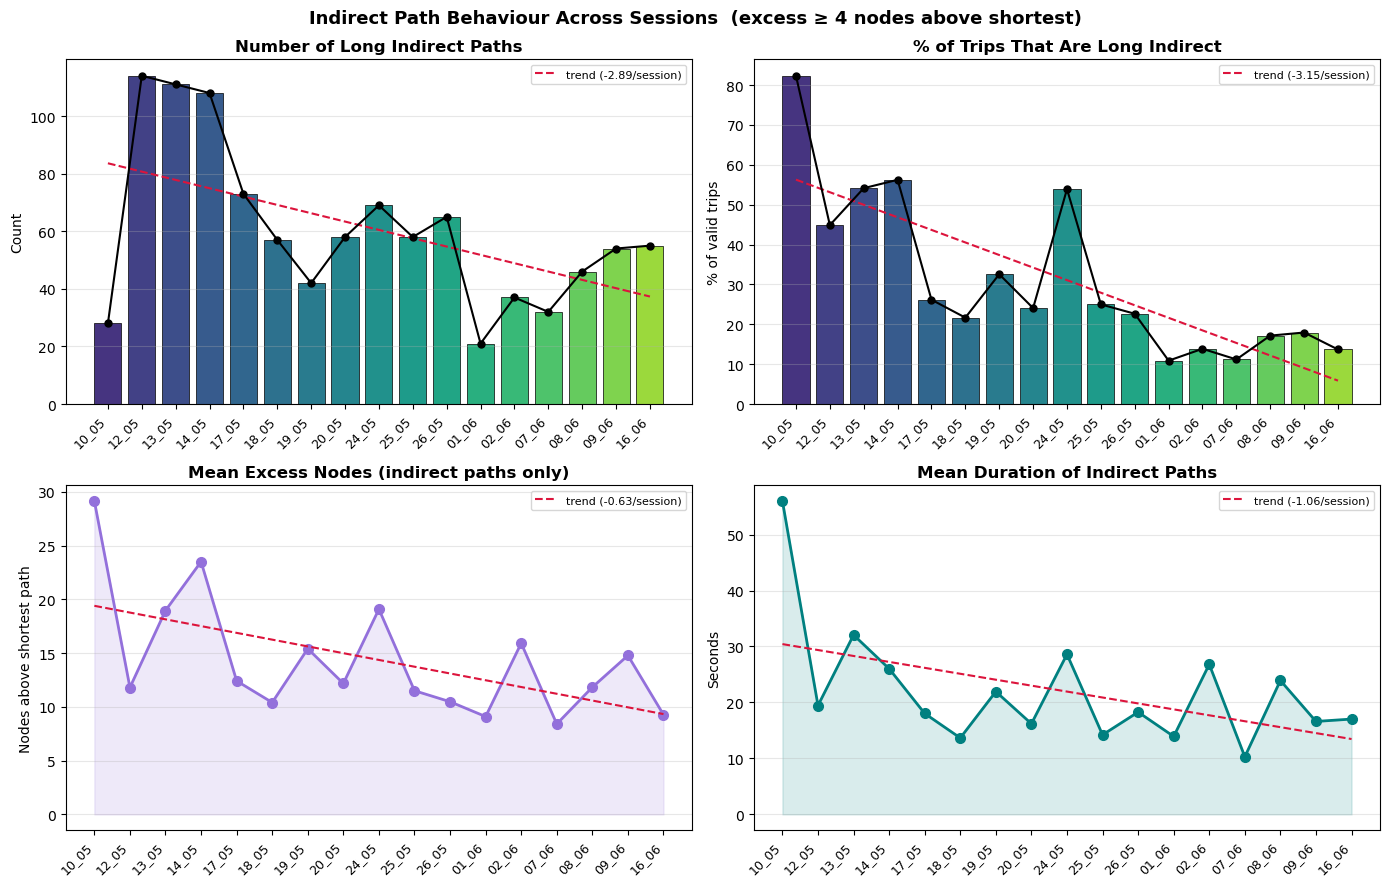

Saved: indirect_path_learning_curves.png


In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Indirect Path Behaviour Across Sessions  (excess ≥ 4 nodes above shortest)',
             fontweight='bold', fontsize=13)

_x  = np.arange(len(cross_session_df))
_xl = cross_session_df['day_label'].tolist()
_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(_x)))

def _style_ax(ax, title, ylabel):
    ax.set_xticks(_x)
    ax.set_xticklabels(_xl, rotation=45, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)

def _add_trend(ax, yvals):
    z = np.polyfit(_x, yvals, 1)
    ax.plot(_x, np.poly1d(z)(_x), '--', color='crimson', linewidth=1.5,
            label=f'trend ({z[0]:+.2f}/session)')
    ax.legend(fontsize=8)

# 1) Count of indirect paths
ax = axes[0, 0]
ax.bar(_x, cross_session_df['n_indirect'], color=_colors, edgecolor='black', linewidth=0.5)
ax.plot(_x, cross_session_df['n_indirect'], 'o-', color='black', linewidth=1.5, markersize=5, zorder=5)
_add_trend(ax, cross_session_df['n_indirect'])
_style_ax(ax, 'Number of Long Indirect Paths', 'Count')

# 2) % of valid trips
ax = axes[0, 1]
ax.bar(_x, cross_session_df['pct_indirect'], color=_colors, edgecolor='black', linewidth=0.5)
ax.plot(_x, cross_session_df['pct_indirect'], 'o-', color='black', linewidth=1.5, markersize=5, zorder=5)
_add_trend(ax, cross_session_df['pct_indirect'])
_style_ax(ax, '% of Trips That Are Long Indirect', '% of valid trips')

# 3) Mean excess nodes (among indirect paths)
ax = axes[1, 0]
ax.plot(_x, cross_session_df['mean_excess_nodes'], 'o-', color='mediumpurple', linewidth=2, markersize=7)
ax.fill_between(_x, cross_session_df['mean_excess_nodes'], alpha=0.15, color='mediumpurple')
_add_trend(ax, cross_session_df['mean_excess_nodes'])
_style_ax(ax, 'Mean Excess Nodes (indirect paths only)', 'Nodes above shortest path')

# 4) Mean duration of indirect paths
ax = axes[1, 1]
ax.plot(_x, cross_session_df['mean_duration_sec'], 'o-', color='teal', linewidth=2, markersize=7)
ax.fill_between(_x, cross_session_df['mean_duration_sec'], alpha=0.15, color='teal')
_add_trend(ax, cross_session_df['mean_duration_sec'])
_style_ax(ax, 'Mean Duration of Indirect Paths', 'Seconds')

plt.tight_layout()
CROSS_SESSION_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(CROSS_SESSION_DIR / 'indirect_path_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: indirect_path_learning_curves.png')

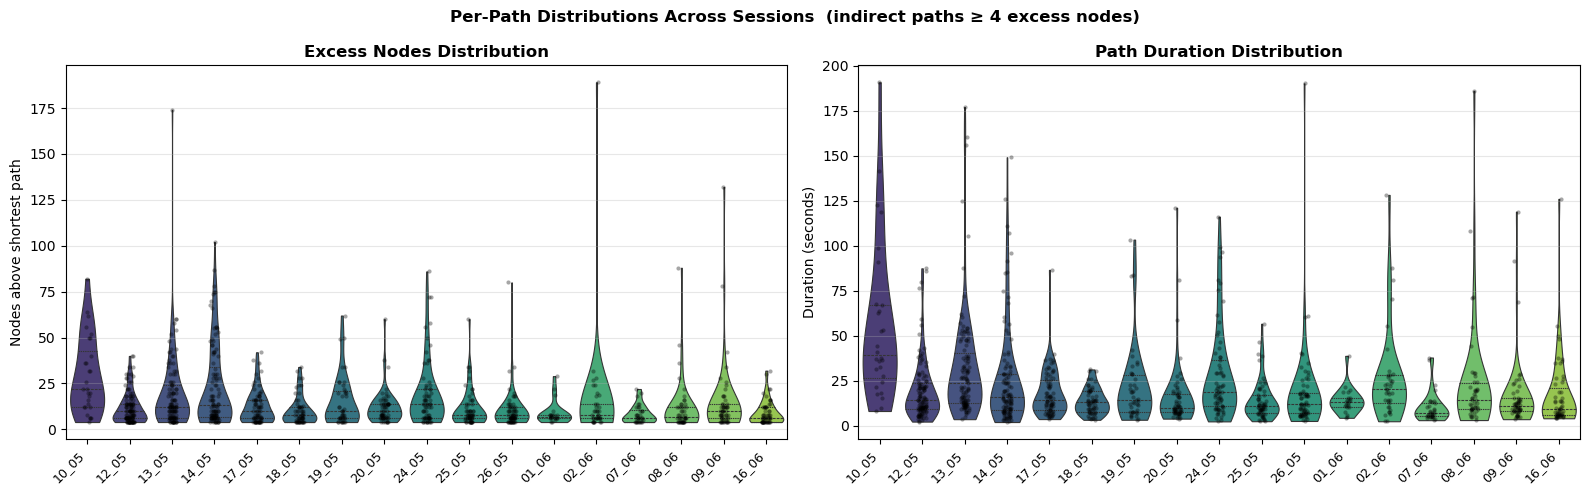

Saved: indirect_path_distributions.png


In [15]:
import seaborn as sns

_session_order = cross_session_df['session'].tolist()
_day_labels    = cross_session_df['day_label'].tolist()
_palette       = dict(zip(_session_order, plt.cm.viridis(
    __import__('numpy').linspace(0.15, 0.85, len(_session_order)))))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Per-Path Distributions Across Sessions  (indirect paths ≥ 4 excess nodes)',
             fontweight='bold', fontsize=12)

for ax, col, title, ylabel in [
    (axes[0], 'excess_nodes', 'Excess Nodes Distribution', 'Nodes above shortest path'),
    (axes[1], 'duration_sec', 'Path Duration Distribution', 'Duration (seconds)'),
]:
    sns.violinplot(data=all_indirect_df, x='session', y=col,
                   order=_session_order, hue='session', palette=_palette,
                   legend=False, ax=ax, cut=0, inner='quartile', linewidth=0.8)
    sns.stripplot(data=all_indirect_df, x='session', y=col,
                  order=_session_order, color='black', alpha=0.35, size=3, ax=ax, jitter=True)
    ax.set_xticks(range(len(_session_order)))
    ax.set_xticklabels(_day_labels, rotation=45, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
CROSS_SESSION_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(CROSS_SESSION_DIR / 'indirect_path_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: indirect_path_distributions.png')

# Spike Data _(optional)_

Everything from here to the population-PCA section needs a Neuropixels recording.
When `HAS_NEURAL` is `False` (no spike folder for this subject/session, or
`LOAD_NEURAL = False`) these cells skip themselves and the notebook carries on
with the behavioural, speed and cross-session analyses.

In [16]:
if HAS_NEURAL:
    good_units = cluster_info[cluster_info['group'] == 'good'].copy().reset_index(drop=True)
    mua_units  = cluster_info[cluster_info['group'] == 'mua'].copy().reset_index(drop=True)
    # noise units are dropped entirely

    print(f"Total clusters : {len(cluster_info)}")
    print(f"Good units     : {len(good_units)}")
    print(f"MUA units      : {len(mua_units)}")
    print(f"Noise dropped  : {(cluster_info['group'] == 'noise').sum()}")
else:
    print(NO_NEURAL_MSG)


⏭  No neural data — No spike folder for NPC4 09_06_2026; tried /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/NPC4/09_06_2026 and /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/09_06_2026


In [17]:
if HAS_NEURAL:
    bad_time_units = [15, 266, 343, 378, 435, 438, 575, 591, 646, 711, 946]
    # Drop from good units the specific clsuter_ids that are known to have bad time series data
    good_units = good_units[~good_units['cluster_id'].isin(bad_time_units)].reset_index(drop=True)
    display(good_units)
else:
    print(NO_NEURAL_MSG)


⏭  No neural data — No spike folder for NPC4 09_06_2026; tried /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/NPC4/09_06_2026 and /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/09_06_2026


In [18]:
if HAS_NEURAL:
    FS = 30_000  # Neuropixels sampling rate (Hz)

    # spike_times / spike_clusters are dicts from scipy.io.loadmat;
    # extract the underlying numpy object array (one element per trial)
    def _unwrap_mat(d):
        keys = [k for k in d if not k.startswith('__')]
        arr = d[keys[0]]
        return arr.flatten()  # handles (1,N) or (N,1) cell arrays

    spike_times_all    = _unwrap_mat(spike_times)
    spike_clusters_all = _unwrap_mat(spike_clusters)

    # Maze trials are 31–766 (1-indexed) → indices 30:767 (0-indexed, 737 trials)
    MAZE_START = 30
    MAZE_END   = 767

    maze_spike_times    = spike_times_all[MAZE_START:MAZE_END]
    maze_spike_clusters = spike_clusters_all[MAZE_START:MAZE_END]

    assert len(maze_spike_times) == 737, f"Expected 737 maze trials, got {len(maze_spike_times)}"
    print(f"Maze trials extracted: {len(maze_spike_times)} (trials 31–766)")
    print()

    # Validate: print spike count and trial length (in samples and seconds) for every trial
    # Spike times within each trial are assumed to be relative to trial start (in samples)
    trial_lengths_s = []
    print(f"{'Trial':>7}  {'Spikes':>7}  {'Length (samples)':>17}  {'Length (s)':>11}")
    print("-" * 48)
    for i, st in enumerate(maze_spike_times):
        st_flat = np.asarray(st).flatten()
        n_spikes = len(st_flat)
        length_samples = int(st_flat.max() - st_flat.min()) if n_spikes > 1 else 0
        length_s = length_samples / FS
        trial_lengths_s.append(length_s)
        print(f"{MAZE_START + i + 1:>7}  {n_spikes:>7}  {length_samples:>17}  {length_s:>11.4f}")

    print()
    trial_lengths_s = np.array(trial_lengths_s)
    print(f"Summary — length (s):  min={trial_lengths_s.min():.2f}  max={trial_lengths_s.max():.2f}  mean={trial_lengths_s.mean():.2f}")
else:
    print(NO_NEURAL_MSG)


⏭  No neural data — No spike folder for NPC4 09_06_2026; tried /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/NPC4/09_06_2026 and /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/09_06_2026


# Path Commitment events
One event per long indirect path. Time 0 is the moment the mouse exits the apex node (marked `direct_start_node`) and commits to the direct route. The PSTH window is *not* a fixed ±2s — trial-switching mid-path is irrelevant to the question being asked, so the window spans the whole indirect path: from the moment the mouse leaves the source port to the moment it arrives at the destination port, regardless of how many of the pipeline's fine-grained "trials" that spans.

In [19]:
import ast

# summary_df has MultiIndex columns (from the tracking pipeline); flatten the
# behavior-only columns we need.
sdf = summary_df.copy()
sdf.columns = ['_'.join([c for c in col if c]) if isinstance(col, tuple) else col for col in sdf.columns]

# Per-trial start/end on the GLOBAL video clock (frame_idx_global / FPS is already a
# continuous, session-wide clock, so no per-trial offsetting is needed on the video side).
trial_meta = sdf.groupby('trial_idx').agg(
    start_frame=('frame_idx_global', 'min'),
    trial_length=('trial_length', 'first'),
)
trial_meta['start_abs'] = trial_meta['start_frame'] / FPS
trial_meta['end_abs'] = trial_meta['start_abs'] + trial_meta['trial_length']

def trials_overlapping(t_lo, t_hi):
    """All pipeline 'trial' indices whose time range overlaps [t_lo, t_hi].

    We deliberately don't derive this from the trial_idx values seen on the path's own
    node rows: a trial with no recorded node visit (e.g. very short) would silently drop
    out and create a gap in the middle of the spike window. Going by absolute time overlap
    instead guarantees full coverage of the path's duration.
    """
    m = (trial_meta['end_abs'] >= t_lo) & (trial_meta['start_abs'] <= t_hi)
    return trial_meta.index[m].tolist()

def parse_pair_label(label):
    try:
        return ast.literal_eval(label)
    except (ValueError, SyntaxError, TypeError):
        return ('NA', 'NA')

change_of_mind_events = []
for _, row in direct_opportunities_df.iterrows():
    apex_visit_idx = row['direct_start_node_visit_idx']
    if pd.isna(apex_visit_idx):
        continue

    start_nv = row['start_node_visit_idx']
    end_nv = start_nv + row['path_seq_length_unique']
    path_rows = improved_node_summary_df[
        (improved_node_summary_df['node_visit_idx'] >= start_nv) &
        (improved_node_summary_df['node_visit_idx'] <= end_nv)
    ]
    apex_row = path_rows[path_rows['node_visit_idx'] == int(apex_visit_idx)].iloc[0]

    path_start_abs = path_rows.iloc[0]['start_frame'] / FPS   # mouse leaves the source port
    path_end_abs = path_rows.iloc[-1]['start_frame'] / FPS    # mouse arrives at the destination port
    t0_abs = apex_row['end_frame'] / FPS                       # mouse leaves the apex node

    trials_in_path = trials_overlapping(path_start_abs, path_end_abs)
    from_port, to_port = parse_pair_label(row['path_pair_label'])

    # One (node_name, time-relative-to-apex-exit) pair per node visit in the path, for
    # annotating the PSTH x-axis with the actual port-to-port trajectory.
    node_track = [
        (r['node_name'], r['start_frame'] / FPS - t0_abs)
        for _, r in path_rows.iterrows()
    ]

    change_of_mind_events.append({
        'path_index': int(row['path_index']),
        'from_port': from_port,
        'to_port': to_port,
        'apex_node': row['direct_start_node'],
        'trials_in_path': trials_in_path,
        't0_abs': t0_abs,
        'window_pre': t0_abs - path_start_abs,    # seconds of path data before the apex exit
        'window_post': path_end_abs - t0_abs,     # seconds of path data after the apex exit
        'node_track': node_track,
    })

change_of_mind_events_df = pd.DataFrame(change_of_mind_events)
print(f"Built {len(change_of_mind_events_df)} Path Commitment events (one per long indirect path)")
display(change_of_mind_events_df)

Built 54 Path Commitment events (one per long indirect path)


,path_index,from_port,to_port,apex_node,trials_in_path,t0_abs,window_pre,window_post,node_track
0,0,Target5,Target6,L526,"[0, 1]",26.525,12.475,3.275,"[(L521, -12.474999999999998), (L410, -11.97499..."
1,1,Target6,Target7,R511,"[1, 2]",43.725,13.450,2.825,"[(L525, -13.450000000000003), (L412, -12.425),..."
2,2,Target7,Target8,R515,"[2, 3]",50.800,3.025,3.025,"[(R59, -3.0249999999999986), (R44, -2.69999999..."
3,3,Target8,Target3,L511,[4],70.625,14.325,1.425,"[(R55, -14.325000000000003), (R42, -14.0499999..."
4,4,Target3,Target1,R410,"[4, 5]",97.575,25.525,3.025,"[(L510, -25.525000000000006), (L45, -25.375), ..."
5,5,Target1,Target7,R45,"[5, 6]",108.200,6.175,1.975,"[(R522, -6.174999999999997), (R411, -6.0750000..."
6,6,Target7,Target6,R22,"[6, 7]",115.150,4.975,5.975,"[(R59, -4.9750000000000085), (R44, -4.82500000..."
7,7,Target6,Target8,R57,"[7, 8]",136.275,14.375,3.500,"[(L525, -14.375), (L412, -13.150000000000006),..."
8,8,Target3,Target7,L522,"[9, 10]",184.400,32.700,9.875,"[(L510, -32.70000000000002), (L45, -32.5500000..."
9,9,Target7,Target5,R44,"[10, 11]",205.475,11.200,14.725,"[(R59, -11.199999999999989), (R44, -11.0499999..."


# PSTH plots: good units aligned to the Path Commitment moment
One PSTH per (indirect path × good unit), saved under `resources/outputs/{subject}/{session}/psth/path_{idx}_{from}_to_{to}/unit_{cluster_id}.png`. Time 0 = the moment the mouse exits the apex node for that path; the window spans the *entire* indirect path (source-port departure to destination-port arrival), stitching spikes across trial boundaries as needed. The firing rate is shown as a Gaussian-smoothed continuous line, with the raw binned rate underneath as a light reference.

In [20]:
if HAS_NEURAL:
    import matplotlib.pyplot as plt
    from scipy.ndimage import gaussian_filter1d

    BIN_SIZE = 0.05      # seconds, histogram bin for the raw rate
    SMOOTH_SIGMA = 0.15  # seconds, stdev of the Gaussian smoothing kernel
    sigma_bins = SMOOTH_SIGMA / BIN_SIZE

    def gather_relative_spikes(trials_in_path, cluster_id, t0_abs):
        """Spikes for one cluster across all trials touched by the path, expressed as
        seconds relative to t0_abs (the Path Commitment moment), by stitching each trial's
        spike-times (stored relative to that trial's own start, in samples) onto the
        global video clock via trial_meta['start_abs'].
        """
        rel_chunks = []
        for t in trials_in_path:
            spike_t = np.asarray(maze_spike_times[t]).flatten() / FS
            spike_c = np.asarray(maze_spike_clusters[t]).flatten()
            abs_t = trial_meta.loc[t, 'start_abs'] + spike_t
            rel_chunks.append(abs_t[spike_c == cluster_id] - t0_abs)
        return np.concatenate(rel_chunks) if rel_chunks else np.array([])

    def binned_and_smoothed_rate(rel_t, bin_edges):
        """Raw per-bin firing rate (Hz) and its Gaussian-smoothed counterpart."""
        counts, _ = np.histogram(rel_t, bins=bin_edges)
        rate = counts.astype(float) / BIN_SIZE
        smoothed = gaussian_filter1d(rate, sigma=sigma_bins, mode='constant')
        return rate, smoothed

    psth_out_dir = SESSION_DIR / 'psth'
    psth_out_dir.mkdir(parents=True, exist_ok=True)

    n_events = len(change_of_mind_events_df)
    n_units = len(good_units)
    print(f"Generating {n_events} x {n_units} = {n_events * n_units} PSTH plots into {psth_out_dir}")

    n_saved = 0
    for _, event in change_of_mind_events_df.iterrows():
        window_pre = event['window_pre']
        window_post = event['window_post']
        n_bins = max(1, round((window_pre + window_post) / BIN_SIZE))
        bin_edges = np.linspace(-window_pre, window_post, n_bins + 1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        event_dir = psth_out_dir / f"path_{event['path_index']:02d}_{event['from_port']}_to_{event['to_port']}"
        event_dir.mkdir(parents=True, exist_ok=True)

        for _, unit in good_units.iterrows():
            cluster_id = int(unit['cluster_id'])
            rel_t = gather_relative_spikes(event['trials_in_path'], cluster_id, event['t0_abs'])
            rate, smoothed_rate = binned_and_smoothed_rate(rel_t, bin_edges)

            fig, ax = plt.subplots(figsize=(8, 4))
            ax.bar(bin_centers, rate, width=BIN_SIZE, align='center', color='lightsteelblue', alpha=0.5, label='raw (binned)')
            ax.plot(bin_centers, smoothed_rate, color='steelblue', linewidth=1.8, label='smoothed')
            ax.axvline(0, color='red', linestyle='--', linewidth=1, label='Path Commitment (exit apex)')
            ax.set_xlabel('Time relative to Path Commitment (s)')
            ax.set_ylabel('Firing rate (Hz)')
            ax.set_title(f"Unit {cluster_id} | path {event['path_index']}: {event['from_port']}→{event['to_port']} | apex={event['apex_node']}", fontsize=9)
            ax.set_xlim(-window_pre, window_post)
            ax.legend(fontsize=7, loc='upper right')
            fig.tight_layout()

            fig.savefig(event_dir / f"unit_{cluster_id:04d}_good.png", dpi=120)
            plt.close(fig)
            n_saved += 1

    print(f"Saved {n_saved} PSTH plots under {psth_out_dir}")
else:
    print(NO_NEURAL_MSG)


⏭  No neural data — No spike folder for NPC4 09_06_2026; tried /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/NPC4/09_06_2026 and /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/09_06_2026


# PSTH plots annotated with the path trajectory
Same smoothed PSTH, but with a secondary x-axis below the time axis showing which maze node the mouse was at, at each point along the path — so the port-to-port transitions are visible alongside the firing rate. Saved under `resources/outputs/{subject}/{session}/psth_annotated/path_{idx}_{from}_to_{to}/unit_{cluster_id}.png`.

In [21]:
if HAS_NEURAL:
    psth_annotated_dir = SESSION_DIR / 'psth_annotated'
    psth_annotated_dir.mkdir(parents=True, exist_ok=True)

    print(f"Generating {n_events} x {n_units} = {n_events * n_units} annotated PSTH plots into {psth_annotated_dir}")

    n_saved = 0
    for _, event in change_of_mind_events_df.iterrows():
        window_pre = event['window_pre']
        window_post = event['window_post']
        n_bins = max(1, round((window_pre + window_post) / BIN_SIZE))
        bin_edges = np.linspace(-window_pre, window_post, n_bins + 1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        node_names = [name for name, _ in event['node_track']]
        node_times = [t for _, t in event['node_track']]

        event_dir = psth_annotated_dir / f"path_{event['path_index']:02d}_{event['from_port']}_to_{event['to_port']}"
        event_dir.mkdir(parents=True, exist_ok=True)

        # widen the figure a bit when the path visits many nodes, so the bottom labels stay legible
        fig_width = max(6, len(node_names) * 0.35)

        for _, unit in good_units.iterrows():
            cluster_id = int(unit['cluster_id'])
            rel_t = gather_relative_spikes(event['trials_in_path'], cluster_id, event['t0_abs'])
            rate, smoothed_rate = binned_and_smoothed_rate(rel_t, bin_edges)

            fig, ax = plt.subplots(figsize=(fig_width, 4))
            ax.bar(bin_centers, rate, width=BIN_SIZE, align='center', color='lightsteelblue', alpha=0.5, label='raw (binned)')
            ax.plot(bin_centers, smoothed_rate, color='steelblue', linewidth=1.8, label='smoothed')
            ax.axvline(0, color='red', linestyle='--', linewidth=1, label='Path Commitment (exit apex)')
            ax.set_ylabel('Firing rate (Hz)')
            ax.set_title(f"Unit {cluster_id} | path {event['path_index']}: {event['from_port']}→{event['to_port']} | apex={event['apex_node']}", fontsize=9)
            ax.set_xlim(-window_pre, window_post)
            ax.set_xlabel('Time relative to Path Commitment (s)')
            ax.legend(fontsize=7, loc='upper right')

            # secondary x-axis sharing the same time scale, ticked at each node visit in the path
            secax = ax.secondary_xaxis(-0.35)
            secax.set_xticks(node_times)
            secax.set_xticklabels(node_names, rotation=90, fontsize=6)
            secax.set_xlabel('Node visited', fontsize=8)

            fig.tight_layout()
            fig.savefig(event_dir / f"unit_{cluster_id:04d}_good.png", dpi=180)
            plt.close(fig)
            n_saved += 1

    print(f"Saved {n_saved} annotated PSTH plots under {psth_annotated_dir}")
else:
    print(NO_NEURAL_MSG)


⏭  No neural data — No spike folder for NPC4 09_06_2026; tried /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/NPC4/09_06_2026 and /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/09_06_2026


# Population-level analysis (PCA): good + MUA units around the Path Commitment moment
For each indirect path, build a time × units population firing-rate matrix (good + MUA units, z-scored per unit) over the path's full time window, and run PCA on it. Rather than just taking PC1/PC2 by variance, we score every PC (among the top-variance candidates) by how much its trajectory actually shifts right around t=0, and visualize the 2 most relevant ones as a 2D trajectory across the path.

In [22]:
if HAS_NEURAL:
    # Population = good + MUA units (noise still excluded)
    population_units = pd.concat([good_units, mua_units], ignore_index=True)
    print(f"Population analysis units: {len(population_units)} ({len(good_units)} good + {len(mua_units)} mua)")

    # How many of the top-variance PCs to even consider as "relevant" candidates. Ranking
    # purely by change-at-t0 score without this cap would let a late, noise-dominated PC
    # win just by chance fluctuating near t=0; restricting to a variance-meaningful pool
    # avoids that.
    N_CANDIDATE_PCS = 20
    T0_CHANGE_WINDOW = 0.5  # seconds on each side of t=0 used to score "change at the Path Commitment"

    def build_population_rate_matrix(event, units_df):
        """Time x units matrix of (smoothed) firing rates over the path's full window."""
        window_pre = event['window_pre']
        window_post = event['window_post']
        n_bins = max(1, round((window_pre + window_post) / BIN_SIZE))
        bin_edges = np.linspace(-window_pre, window_post, n_bins + 1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        cluster_ids = units_df['cluster_id'].astype(int).to_numpy()
        rate_matrix = np.zeros((n_bins, len(cluster_ids)))
        for j, cid in enumerate(cluster_ids):
            rel_t = gather_relative_spikes(event['trials_in_path'], cid, event['t0_abs'])
            _, smoothed = binned_and_smoothed_rate(rel_t, bin_edges)
            rate_matrix[:, j] = smoothed
        return bin_centers, rate_matrix, cluster_ids

    def run_pca(rate_matrix):
        """PCA via SVD on the z-scored (per unit) rate matrix. Returns PC scores
        (time x components) and the fraction of variance each component explains."""
        mu = rate_matrix.mean(axis=0)
        sigma = rate_matrix.std(axis=0)
        sigma_safe = np.where(sigma > 1e-9, sigma, 1.0)  # silent units: leave as all-zero after centering
        X = (rate_matrix - mu) / sigma_safe

        U, S, _Vt = np.linalg.svd(X, full_matrices=False)
        scores = U * S
        explained_var = (S ** 2) / np.sum(S ** 2)
        return scores, explained_var

    def pc_change_scores(scores, bin_centers, window_pre, window_post, t0_window=T0_CHANGE_WINDOW):
        """For each PC, |mean(post t0) - mean(pre t0)| normalized by that PC's own std --
        an effect-size for how much the trajectory shifts right at the Path Commitment moment."""
        w = min(t0_window, window_pre, window_post)
        pre_mask = (bin_centers >= -w) & (bin_centers < 0)
        post_mask = (bin_centers >= 0) & (bin_centers <= w)

        out = np.zeros(scores.shape[1])
        for k in range(scores.shape[1]):
            pc = scores[:, k]
            pre_mean = pc[pre_mask].mean() if pre_mask.any() else 0.0
            post_mean = pc[post_mask].mean() if post_mask.any() else 0.0
            pc_std = pc.std() if pc.std() > 1e-9 else 1.0
            out[k] = abs(post_mean - pre_mean) / pc_std
        return out
else:
    print(NO_NEURAL_MSG)


⏭  No neural data — No spike folder for NPC4 09_06_2026; tried /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/NPC4/09_06_2026 and /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/09_06_2026


# Population PCA trajectory: top 3 PCs by variance
Alternative to the "best 2" (change-relevance-ranked) view above: just take PC1–PC3, the 3 highest-variance components, and plot the population trajectory in 3D. Same matrices/PCA as before (good + MUA units, z-scored, one PCA per path) — only the PC selection criterion and the plot dimensionality differ.

In [23]:
if HAS_NEURAL:
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the '3d' projection)

    pca_top3_dir = SESSION_DIR / 'population_pca_top3pcs'
    pca_top3_dir.mkdir(parents=True, exist_ok=True)

    pca_top3_summary_rows = []

    for _, event in change_of_mind_events_df.iterrows():
        bin_centers, rate_matrix, cluster_ids = build_population_rate_matrix(event, population_units)
        scores, explained_var = run_pca(rate_matrix)
        change = pc_change_scores(scores, bin_centers, event['window_pre'], event['window_post'])

        pc1, pc2, pc3 = 0, 1, 2  # fixed: first 3 PCs by variance, not change-relevance
        traj_x, traj_y, traj_z = scores[:, pc1], scores[:, pc2], scores[:, pc3]
        t0_idx = np.argmin(np.abs(bin_centers))

        fig = plt.figure(figsize=(7, 7))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot(traj_x, traj_y, traj_z, color='gray', alpha=0.4, linewidth=1, zorder=1)
        sca = ax.scatter(traj_x, traj_y, traj_z, c=bin_centers, cmap='viridis', s=18, zorder=2)
        ax.scatter(*[a[0] for a in (traj_x, traj_y, traj_z)], color='green', marker='o', s=70, zorder=3, label='path start')
        ax.scatter(*[a[-1] for a in (traj_x, traj_y, traj_z)], color='black', marker='s', s=70, zorder=3, label='path end')
        ax.scatter(*[a[t0_idx] for a in (traj_x, traj_y, traj_z)], color='red', marker='*', s=280, zorder=4, label='Path Commitment')

        fig.colorbar(sca, ax=ax, label='Time relative to Path Commitment (s)', shrink=0.6, pad=0.1)
        ax.set_xlabel(f"PC1 ({explained_var[pc1] * 100:.1f}% var)")
        ax.set_ylabel(f"PC2 ({explained_var[pc2] * 100:.1f}% var)")
        ax.set_zlabel(f"PC3 ({explained_var[pc3] * 100:.1f}% var)")
        ax.set_title(f"Population trajectory (top 3 PCs) | path {event['path_index']}: {event['from_port']}→{event['to_port']} | apex={event['apex_node']}", fontsize=9)
        ax.legend(fontsize=8)
        fig.tight_layout()

        out_path = pca_top3_dir / f"path_{event['path_index']:02d}_{event['from_port']}_to_{event['to_port']}.png"
        fig.savefig(out_path, dpi=150)
        plt.close(fig)

        pca_top3_summary_rows.append({
            'path_index': event['path_index'],
            'from_port': event['from_port'],
            'to_port': event['to_port'],
            'n_units': len(cluster_ids),
            'n_bins': len(bin_centers),
            'pc1_explained_var': explained_var[pc1],
            'pc1_change_score': change[pc1],
            'pc2_explained_var': explained_var[pc2],
            'pc2_change_score': change[pc2],
            'pc3_explained_var': explained_var[pc3],
            'pc3_change_score': change[pc3],
        })

    pca_top3_summary_df = pd.DataFrame(pca_top3_summary_rows)
    pca_top3_summary_df.to_csv(pca_top3_dir / 'pca_top3_summary.csv', index=False)
    print(f"Saved {len(pca_top3_summary_df)} top-3-PC population trajectory plots + summary under {pca_top3_dir}")
    display(pca_top3_summary_df)
else:
    print(NO_NEURAL_MSG)


⏭  No neural data — No spike folder for NPC4 09_06_2026; tried /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/NPC4/09_06_2026 and /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/09_06_2026


# Trajectory spread: before vs. after the Path Commitment moment

For each path's PCA trajectory, quantify how broadly the trajectory explores PC space in the **pre** (t < 0) vs. **post** (t ≥ 0) epoch.

**Spread metric:**
- *Per-PC*: standard deviation of that PC's scores within the epoch.
- *Aggregated (top-k PCs jointly)*: **radius of gyration** — RMS distance from the epoch centroid in the k-dimensional PC sub-space. This generalises the per-PC std to multi-dimensional space and grows naturally as more PCs are added.

PCs are selected up to **90 % cumulative explained variance** (adjustable via `VAR_THRESHOLD`). For each PC we report `spread_pre`, `spread_post`, and the ratio — `spread_pre / spread_post > 1` means the trajectory was broader *before* Path Commitment. The aggregated ratio shows whether this holds jointly across the first k PCs.

In [24]:
if HAS_NEURAL:
    # ---------------------------------------------------------------------------
    # Trajectory spread: how broadly does the population trajectory explore
    # PC space BEFORE vs. AFTER the Path Commitment moment?
    #
    # Per-PC spread   : std of that PC's scores in the pre (t < 0) / post (t ≥ 0) epoch.
    # Aggregated spread: radius of gyration = RMS distance from the epoch centroid
    #   in the k-dimensional sub-space spanned by the top k PCs. Computed for
    #   k = 1 … N_pcs so you can see how the picture changes as more PCs are included.
    #
    # PCs retained: those covering at least VAR_THRESHOLD cumulative explained variance.
    # ---------------------------------------------------------------------------
    VAR_THRESHOLD = 0.80   # retain PCs until this fraction of variance is covered

    def radius_of_gyration(pts):
        """RMS distance from the epoch centroid; pts shape (n_timepoints, n_dims)."""
        if pts.ndim == 1:
            pts = pts[:, None]
        if pts.shape[0] < 2:
            return np.nan
        centroid = pts.mean(axis=0)
        return np.sqrt(((pts - centroid) ** 2).sum(axis=1).mean())

    # ── Compute spread for every path ────────────────────────────────────────────
    per_pc_rows = []
    agg_rows    = []

    for _, event in change_of_mind_events_df.iterrows():
        bin_centers, rate_matrix, _ = build_population_rate_matrix(event, population_units)
        scores, explained_var = run_pca(rate_matrix)

        cum_var = np.cumsum(explained_var)
        n_pcs   = int(np.searchsorted(cum_var, VAR_THRESHOLD) + 1)
        n_pcs   = min(n_pcs, scores.shape[1])

        pre_mask  = bin_centers < 0
        post_mask = bin_centers >= 0
        base = dict(path_index=event['path_index'],
                    from_port=event['from_port'],
                    to_port=event['to_port'])

        # Per-PC: std of each PC's scores in each epoch
        for k in range(n_pcs):
            pc = scores[:, k]
            sp_pre  = pc[pre_mask].std()  if pre_mask.sum()  > 1 else np.nan
            sp_post = pc[post_mask].std() if post_mask.sum() > 1 else np.nan
            per_pc_rows.append({**base,
                'pc': k + 1,
                'explained_var_pct':     explained_var[k] * 100,
                'cum_explained_var_pct': cum_var[k]        * 100,
                'n_pcs_retained':        n_pcs,
                'spread_pre':            sp_pre,
                'spread_post':           sp_post,
                'spread_ratio':          sp_pre / sp_post if sp_post > 1e-9 else np.nan,
            })

        # Aggregated: radius of gyration in the sub-space of the top-k PCs (k=1…n_pcs)
        for k in range(1, n_pcs + 1):
            pts      = scores[:, :k]
            agg_pre  = radius_of_gyration(pts[pre_mask])
            agg_post = radius_of_gyration(pts[post_mask])
            agg_rows.append({**base,
                'n_pcs':                 k,
                'cum_explained_var_pct': cum_var[k - 1] * 100,
                'spread_pre':            agg_pre,
                'spread_post':           agg_post,
                'spread_ratio':          agg_pre / agg_post if (agg_post and agg_post > 1e-9) else np.nan,
            })

    per_pc_df = pd.DataFrame(per_pc_rows)
    agg_df    = pd.DataFrame(agg_rows)

    # Save CSVs
    spread_dir = SESSION_DIR / 'trajectory_spread'
    spread_dir.mkdir(parents=True, exist_ok=True)
    per_pc_df.to_csv(spread_dir / 'spread_per_pc.csv',    index=False)
    agg_df.to_csv(   spread_dir / 'spread_aggregated.csv', index=False)

    print(f"Paths analysed   : {per_pc_df['path_index'].nunique()}")
    print(f"PCs retained (min/max across paths): "
          f"{int(per_pc_df.groupby('path_index')['n_pcs_retained'].first().min())} / "
          f"{int(per_pc_df.groupby('path_index')['n_pcs_retained'].first().max())}")

    # ── Figure 1: per-PC spread summary ──────────────────────────────────────────
    max_pc  = int(per_pc_df['pc'].max())
    pc_vals = np.arange(1, max_pc + 1)

    def pc_agg(col, fn):
        return [fn(per_pc_df.loc[per_pc_df['pc'] == p, col].dropna()) for p in pc_vals]

    mean_pre   = pc_agg('spread_pre',             np.mean)
    sem_pre    = pc_agg('spread_pre',             lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan)
    mean_post  = pc_agg('spread_post',            np.mean)
    sem_post   = pc_agg('spread_post',            lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan)
    mean_ratio = pc_agg('spread_ratio',           np.mean)
    sem_ratio  = pc_agg('spread_ratio',           lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan)
    mean_cum   = pc_agg('cum_explained_var_pct',  np.mean)

    fig1, axes1 = plt.subplots(1, 2, figsize=(13, 4.5))

    # Left: spread_pre vs spread_post per PC
    ax = axes1[0]
    ax.errorbar(pc_vals, mean_pre,  yerr=sem_pre,  fmt='o-', color='steelblue', label='Pre  (t < 0)',  capsize=3)
    ax.errorbar(pc_vals, mean_post, yerr=sem_post, fmt='s-', color='tomato',    label='Post (t ≥ 0)', capsize=3)
    ax.set_xlabel('PC')
    ax.set_ylabel('Spread  (std of PC scores within epoch)')
    ax.set_title('Per-PC trajectory spread: pre vs. post Path Commitment (mean ± SEM across paths)')
    ax.set_xticks(pc_vals)
    ax.legend()
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    ax_top.set_xticks(pc_vals)
    ax_top.set_xticklabels([f'{v:.0f}%' for v in mean_cum], fontsize=7, rotation=45)
    ax_top.set_xlabel('Cumul. explained variance (%)', fontsize=8)

    # Right: spread ratio (pre/post) per PC
    ax = axes1[1]
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='ratio = 1 (no difference)')
    ax.errorbar(pc_vals, mean_ratio, yerr=sem_ratio, fmt='D-', color='purple', capsize=3)
    ax.set_xlabel('PC')
    ax.set_ylabel('Spread ratio  (pre / post)')
    ax.set_title('Per-PC spread ratio across paths (mean ± SEM; >1 = broader before Path Commitment)')
    ax.set_xticks(pc_vals)
    ax.legend()

    fig1.tight_layout()
    fig1.savefig(spread_dir / 'spread_per_pc_summary.png', dpi=150)
    plt.show()

    # ── Figure 2: aggregated (multi-PC) spread ────────────────────────────────────
    max_k   = int(agg_df['n_pcs'].max())
    k_vals  = np.arange(1, max_k + 1)

    mean_agg_pre   = [agg_df.loc[agg_df['n_pcs'] == k, 'spread_pre'].mean()  for k in k_vals]
    mean_agg_post  = [agg_df.loc[agg_df['n_pcs'] == k, 'spread_post'].mean() for k in k_vals]
    mean_agg_ratio = [agg_df.loc[agg_df['n_pcs'] == k, 'spread_ratio'].mean() for k in k_vals]
    sem_agg_ratio  = [agg_df.loc[agg_df['n_pcs'] == k, 'spread_ratio'].sem()  for k in k_vals]
    mean_cum_agg   = [agg_df.loc[agg_df['n_pcs'] == k, 'cum_explained_var_pct'].mean() for k in k_vals]
    path_ids       = agg_df['path_index'].unique()

    fig2, axes2 = plt.subplots(1, 2, figsize=(13, 4.5))

    # Left: absolute radius-of-gyration, pre vs post, as function of n_pcs
    ax = axes2[0]
    for pid in path_ids:
        sub = agg_df[agg_df['path_index'] == pid].sort_values('n_pcs')
        ax.plot(sub['n_pcs'], sub['spread_pre'],  color='steelblue', alpha=0.25, linewidth=1)
        ax.plot(sub['n_pcs'], sub['spread_post'], color='tomato',    alpha=0.25, linewidth=1)
    ax.plot(k_vals, mean_agg_pre,  color='steelblue', linewidth=2.5, label='Pre  mean')
    ax.plot(k_vals, mean_agg_post, color='tomato',    linewidth=2.5, label='Post mean')
    ax.set_xlabel('Number of PCs included')
    ax.set_ylabel('Radius of gyration  (a.u.)')
    ax.set_title('Aggregated spread vs. number of PCs (mean ± SEM across paths)')
    ax.set_xticks(k_vals)
    ax.legend()

    # Right: spread ratio pre/post, per path + mean ± SEM
    ax = axes2[1]
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
    for pid in path_ids:
        sub = agg_df[agg_df['path_index'] == pid].sort_values('n_pcs')
        ax.plot(sub['n_pcs'], sub['spread_ratio'], color='purple', alpha=0.25, linewidth=1)
    ax.errorbar(k_vals, mean_agg_ratio, yerr=sem_agg_ratio,
                fmt='D-', color='purple', linewidth=2.5, capsize=3, label='Mean ± SEM')
    ax.set_xlabel('Number of PCs included')
    ax.set_ylabel('Spread ratio  (pre / post)')
    ax.set_title(f'Aggregated spread ratio vs. PCs included(≥{VAR_THRESHOLD*100:.0f}% var threshold; >1 = broader before Path Commitment)')
    ax.set_xticks(k_vals)
    ax.legend()
    ax_top2 = ax.twiny()
    ax_top2.set_xlim(ax.get_xlim())
    ax_top2.set_xticks(k_vals)
    ax_top2.set_xticklabels([f'{v:.0f}%' for v in mean_cum_agg], fontsize=7, rotation=45)
    ax_top2.set_xlabel('Cumul. explained variance (%)', fontsize=8)

    fig2.tight_layout()
    fig2.savefig(spread_dir / 'spread_aggregated_summary.png', dpi=150)
    plt.show()

    # ── Summary tables ────────────────────────────────────────────────────────────
    print("\nPer-PC summary (mean across paths):")
    display(per_pc_df.groupby('pc')[['explained_var_pct','cum_explained_var_pct','spread_pre','spread_post','spread_ratio']]
            .mean().round(3))

    print("\nAggregated spread summary (mean across paths):")
    display(agg_df.groupby('n_pcs')[['cum_explained_var_pct','spread_pre','spread_post','spread_ratio']]
            .mean().round(3))
else:
    print(NO_NEURAL_MSG)


⏭  No neural data — No spike folder for NPC4 09_06_2026; tried /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/NPC4/09_06_2026 and /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/09_06_2026


# Time spent pre vs. post, and time-normalized spread

Two complementary checks on whether the broader pre-epoch trajectory is a duration artifact:

1. **Duration comparison** — how many seconds does each path spend before vs. after the Path Commitment moment? If the mouse always spends more time wandering *before* the apex exit, a larger spread is expected purely from sampling more timepoints.

2. **Time-normalized spread** — divide each epoch's spread by √(epoch duration). Under a random-walk null, variance grows linearly with time, so std ∝ √T; dividing by √T removes that dependence. If the normalized pre-epoch spread is *still* larger, the broader trajectory cannot be explained by the time difference alone.

   A scatter of the raw spread ratio vs. the time ratio (window_pre / window_post) lets you see directly how much of the spread difference is predicted by duration.

In [25]:
if HAS_NEURAL:
    # ---------------------------------------------------------------------------
    # 1. Duration: how long is the pre vs. post epoch for each path?
    # 2. Time-normalized spread: spread / sqrt(duration) to remove the
    #    expected sqrt(T) growth of std under a random-walk null.
    # ---------------------------------------------------------------------------
    from scipy.stats import wilcoxon
    from scipy.stats import pearsonr

    # ── 1. Duration analysis ─────────────────────────────────────────────────────
    dur_pre  = change_of_mind_events_df['window_pre'].values
    dur_post = change_of_mind_events_df['window_post'].values

    print("=== Duration: pre vs. post Path Commitment epoch ===")
    print(f"Mean window_pre  : {np.nanmean(dur_pre):.2f} ± {pd.Series(dur_pre).sem():.2f} s  SEM")
    print(f"Mean window_post : {np.nanmean(dur_post):.2f} ± {pd.Series(dur_post).sem():.2f} s  SEM")
    if len(dur_pre) > 1:
        stat_dur, p_dur = wilcoxon(dur_pre, dur_post)
        print(f"Wilcoxon test (two-sided): W = {stat_dur:.1f}, p = {p_dur:.4f}")
    else:
        p_dur = float('nan')

    fig_t, axes_t = plt.subplots(1, 2, figsize=(12, 4.5))

    # Paired lines per path
    ax = axes_t[0]
    for pre, post in zip(dur_pre, dur_post):
        ax.plot([0, 1], [pre, post], color='gray', alpha=0.4, linewidth=1)
    ax.errorbar([0], [np.nanmean(dur_pre)],  yerr=[pd.Series(dur_pre).sem()],
                fmt='o', color='steelblue', markersize=10, capsize=5, linewidth=2, label='Pre mean ± SEM')
    ax.errorbar([1], [np.nanmean(dur_post)], yerr=[pd.Series(dur_post).sem()],
                fmt='o', color='tomato',    markersize=10, capsize=5, linewidth=2, label='Post mean ± SEM')
    ax.plot([0, 1], [np.nanmean(dur_pre), np.nanmean(dur_post)], color='purple', linewidth=2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pre (t < 0)', 'Post (t ≥ 0)'])
    ax.set_ylabel('Duration (s)')
    ax.set_title(f'Time spent pre vs. post Path Commitment\n(grey = individual paths; Wilcoxon p = {p_dur:.3f})')
    ax.legend()

    # Scatter: duration pre vs. post
    ax = axes_t[1]
    lo, hi = 0, max(dur_pre.max(), dur_post.max()) * 1.1
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.5, label='pre = post')
    ax.scatter(dur_pre, dur_post,
               c=change_of_mind_events_df['path_index'], cmap='tab20', s=60, zorder=3)
    for _, row in change_of_mind_events_df.iterrows():
        ax.annotate(str(int(row['path_index'])),
                    (row['window_pre'], row['window_post']),
                    fontsize=7, ha='left', va='bottom')
    ax.set_xlabel('window_pre (s)')
    ax.set_ylabel('window_post (s)')
    ax.set_title('Duration scatter: pre vs. post per path\n(above diagonal = more time post)')
    ax.legend()

    fig_t.tight_layout()
    fig_t.savefig(spread_dir / 'duration_pre_vs_post.png', dpi=150)
    plt.show()

    # ── 2. Time-normalized spread ─────────────────────────────────────────────────
    dur_map = change_of_mind_events_df.set_index('path_index')[['window_pre', 'window_post']]

    # Per-PC normalized spread
    per_pc_norm = per_pc_df.join(dur_map, on='path_index')
    per_pc_norm['spread_pre_norm']   = (per_pc_norm['spread_pre']
                                        / np.sqrt(per_pc_norm['window_pre'].clip(lower=1e-6)))
    per_pc_norm['spread_post_norm']  = (per_pc_norm['spread_post']
                                        / np.sqrt(per_pc_norm['window_post'].clip(lower=1e-6)))
    per_pc_norm['spread_ratio_norm'] = (per_pc_norm['spread_pre_norm']
                                        / per_pc_norm['spread_post_norm'].replace(0, np.nan))

    # Aggregated normalized spread
    agg_norm = agg_df.join(dur_map, on='path_index')
    agg_norm['spread_pre_norm']   = (agg_norm['spread_pre']
                                     / np.sqrt(agg_norm['window_pre'].clip(lower=1e-6)))
    agg_norm['spread_post_norm']  = (agg_norm['spread_post']
                                     / np.sqrt(agg_norm['window_post'].clip(lower=1e-6)))
    agg_norm['spread_ratio_norm'] = (agg_norm['spread_pre_norm']
                                     / agg_norm['spread_post_norm'].replace(0, np.nan))

    # Wilcoxon on normalized aggregated spread at each path's max retained k
    max_k_mask = agg_norm['n_pcs'] == agg_norm.groupby('path_index')['n_pcs'].transform('max')
    agg_max    = agg_norm[max_k_mask].drop_duplicates(subset=['path_index'])

    if len(agg_max) > 1:
        stat_raw,  p_raw  = wilcoxon(agg_max['spread_pre'].dropna(),
                                     agg_max['spread_post'].dropna())
        stat_norm, p_norm = wilcoxon(agg_max['spread_pre_norm'].dropna(),
                                     agg_max['spread_post_norm'].dropna())
        print(f"\n=== Spread (aggregated, all retained PCs) ===")
        print(f"Raw spread        Wilcoxon: W = {stat_raw:.1f},  p = {p_raw:.4f}")
        print(f"Normalized spread Wilcoxon: W = {stat_norm:.1f}, p = {p_norm:.4f}")

    # Time ratio for the scatter panel
    time_ratio_s = change_of_mind_events_df.set_index('path_index').apply(
        lambda r: r['window_pre'] / r['window_post'] if r['window_post'] > 1e-9 else np.nan, axis=1)
    agg_max2 = agg_max.copy().set_index('path_index')
    agg_max2['time_ratio'] = time_ratio_s

    # ── Figures ──────────────────────────────────────────────────────────────────
    pc_vals_n = sorted(per_pc_norm['pc'].unique())

    def _agg(col, fn):
        return [fn(per_pc_norm.loc[per_pc_norm['pc'] == p, col].dropna()) for p in pc_vals_n]

    def _sem(x):
        return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

    fig3, axes3 = plt.subplots(1, 3, figsize=(18, 4.5))

    # Left: time-normalized spread pre vs. post per PC
    ax = axes3[0]
    ax.errorbar(pc_vals_n, _agg('spread_pre_norm', np.mean),
                yerr=_agg('spread_pre_norm',  _sem),
                fmt='o-', color='steelblue', label='Pre / √T', capsize=3)
    ax.errorbar(pc_vals_n, _agg('spread_post_norm', np.mean),
                yerr=_agg('spread_post_norm', _sem),
                fmt='s-', color='tomato',    label='Post / √T', capsize=3)
    ax.set_xlabel('PC')
    ax.set_ylabel('Spread / √duration  (a.u. s⁻⁰·⁵)')
    ax.set_title('Time-normalized spread per PC\n(spread ÷ √epoch duration, mean ± SEM across paths)')
    ax.set_xticks(pc_vals_n)
    ax.legend()

    # Middle: normalized spread ratio per PC
    ax = axes3[1]
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='ratio = 1')
    ax.errorbar(pc_vals_n, _agg('spread_ratio_norm', np.mean),
                yerr=_agg('spread_ratio_norm', _sem),
                fmt='D-', color='purple', capsize=3,
                label=f'Norm. ratio (p={p_norm:.3f})')
    ax.set_xlabel('PC')
    ax.set_ylabel('(Pre / √T_pre) / (Post / √T_post)')
    ax.set_title('Time-normalized spread ratio per PC\n(>1 = broader pre even after correcting for duration)')
    ax.set_xticks(pc_vals_n)
    ax.legend()

    # Right: raw spread ratio vs. time ratio — does time explain the spread?
    ax = axes3[2]
    valid = agg_max2[['time_ratio', 'spread_ratio']].dropna()
    ax.scatter(valid['time_ratio'], valid['spread_ratio'],
               c=valid.index, cmap='tab20', s=60, zorder=3)
    for pid in valid.index:
        ax.annotate(str(pid), (valid.loc[pid, 'time_ratio'], valid.loc[pid, 'spread_ratio']),
                    fontsize=7, ha='left', va='bottom')
    if len(valid) > 2:
        m, b = np.polyfit(valid['time_ratio'], valid['spread_ratio'], 1)
        x_fit = np.linspace(valid['time_ratio'].min(), valid['time_ratio'].max(), 100)
        ax.plot(x_fit, m * x_fit + b, 'r--', linewidth=1.5)
        r_val, p_corr = pearsonr(valid['time_ratio'], valid['spread_ratio'])
        corr_label = f'r = {r_val:.2f}, p = {p_corr:.3f}'
    else:
        corr_label = ''
    ax.axvline(1.0, color='gray', linestyle=':', linewidth=1, label='equal time pre/post')
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=1, label='equal spread pre/post')
    ax.set_xlabel('Time ratio  (window_pre / window_post)')
    ax.set_ylabel('Raw spread ratio  (pre / post)')
    ax.set_title(f'Is spread explained by time?\n{corr_label}')
    ax.legend(fontsize=8)

    fig3.tight_layout()
    fig3.savefig(spread_dir / 'time_normalized_spread.png', dpi=150)
    plt.show()

    # Save normalized spread tables
    per_pc_norm.to_csv(spread_dir / 'spread_per_pc_time_normalized.csv',    index=False)
    agg_norm.to_csv(   spread_dir / 'spread_aggregated_time_normalized.csv', index=False)
    print("\nSaved normalized spread CSVs to", spread_dir)
else:
    print(NO_NEURAL_MSG)


⏭  No neural data — No spike folder for NPC4 09_06_2026; tried /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/NPC4/09_06_2026 and /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/09_06_2026


## Per-PC statistics: which PCs drive the normalized spread difference?

The aggregated spread (radius of gyration across all retained PCs) averages out the early-PC signal.
Here we run a separate **Wilcoxon signed-rank test** for each PC on the time-normalized spread
(spread / √epoch duration), plot the p-value vs. PC number, and show paired scatter plots for the
first few PCs so you can see the individual-path picture.

In [26]:
if HAS_NEURAL:
    # ---------------------------------------------------------------------------
    # Per-PC Wilcoxon on time-normalized spread
    # per_pc_norm is computed in the previous cell (spread / sqrt(epoch_duration))
    # ---------------------------------------------------------------------------
    from scipy.stats import wilcoxon as _wilcoxon

    pc_stats = []
    for pc in sorted(per_pc_norm['pc'].unique()):
        sub  = per_pc_norm[per_pc_norm['pc'] == pc].dropna(subset=['spread_pre_norm', 'spread_post_norm'])
        n    = len(sub)
        if n < 3:
            continue
        pre  = sub['spread_pre_norm'].values
        post = sub['spread_post_norm'].values
        try:
            W, p = _wilcoxon(pre, post, alternative='greater')   # one-sided: pre > post
        except ValueError:
            W, p = np.nan, np.nan
        # rank-biserial correlation as effect size
        r_rb = 1 - (2 * W) / (n * (n + 1)) if n > 0 else np.nan
        mean_diff = np.mean(pre - post)
        sem_diff  = pd.Series(pre - post).sem()
        pc_stats.append(dict(pc=pc, n=n, W=W, p_one_sided=p, r_rb=r_rb,
                             mean_diff=mean_diff, sem_diff=sem_diff))

    pc_stats_df = pd.DataFrame(pc_stats)
    # Bonferroni correction
    pc_stats_df['p_bonferroni'] = (pc_stats_df['p_one_sided'] * len(pc_stats_df)).clip(upper=1.0)

    print("Per-PC Wilcoxon (one-sided: pre/√T > post/√T):")
    display(pc_stats_df[['pc', 'n', 'W', 'p_one_sided', 'p_bonferroni', 'r_rb', 'mean_diff', 'sem_diff']].round(4))

    # ── Figure 1: p-values + effect sizes per PC ─────────────────────────────────
    pc_vals_s = pc_stats_df['pc'].values

    fig4, axes4 = plt.subplots(1, 2, figsize=(13, 4.5))

    # Left: -log10(p) bar chart with significance lines
    ax = axes4[0]
    log_p = -np.log10(pc_stats_df['p_one_sided'].clip(lower=1e-10))
    colors = ['tomato' if p < 0.05 else 'steelblue' for p in pc_stats_df['p_one_sided']]
    ax.bar(pc_vals_s, log_p, color=colors, edgecolor='k', linewidth=0.5)
    ax.axhline(-np.log10(0.05), color='gray',   linestyle='--', linewidth=1.2, label='p = 0.05')
    ax.axhline(-np.log10(0.05 / len(pc_stats_df)),
               color='black', linestyle=':',  linewidth=1.2,
               label=f'Bonferroni (p = {0.05/len(pc_stats_df):.3f})')
    ax.set_xlabel('PC')
    ax.set_ylabel('−log₁₀(p)')
    ax.set_title('Per-PC Wilcoxon: time-normalized spread pre > post (red = p < 0.05 uncorrected)')
    ax.set_xticks(pc_vals_s)
    ax.legend()

    # Right: mean difference (pre/√T − post/√T) ± SEM per PC
    ax = axes4[1]
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.bar(pc_vals_s, pc_stats_df['mean_diff'],
           yerr=pc_stats_df['sem_diff'], color=colors,
           edgecolor='k', linewidth=0.5, capsize=4, error_kw=dict(elinewidth=1.2))
    ax.set_xlabel('PC')
    ax.set_ylabel('Mean (pre/√T − post/√T)  (a.u. s⁻⁰·⁵)')
    ax.set_title('Mean normalized spread difference per PC (pre − post; red = p < 0.05 uncorrected)')
    ax.set_xticks(pc_vals_s)

    fig4.tight_layout()
    fig4.savefig(spread_dir / 'per_pc_wilcoxon_normalized.png', dpi=150)
    plt.show()

    # ── Figure 2: paired scatter per PC (up to first 6) ──────────────────────────
    n_show = min(6, len(pc_vals_s))
    ncols  = 3
    nrows  = int(np.ceil(n_show / ncols))
    fig5, axes5 = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)

    for ax_i, pc in enumerate(pc_vals_s[:n_show]):
        row_i, col_i = divmod(ax_i, ncols)
        ax = axes5[row_i][col_i]

        sub = per_pc_norm[per_pc_norm['pc'] == pc].dropna(subset=['spread_pre_norm', 'spread_post_norm'])
        pre  = sub['spread_pre_norm'].values
        post = sub['spread_post_norm'].values

        # Paired lines
        for p_val, po_val in zip(pre, post):
            ax.plot([0, 1], [p_val, po_val], color='gray', alpha=0.4, linewidth=1)
        ax.errorbar([0], [pre.mean()],  yerr=[pd.Series(pre).sem()],
                    fmt='o', color='steelblue', markersize=9, capsize=4, linewidth=2, label='Pre/√T')
        ax.errorbar([1], [post.mean()], yerr=[pd.Series(post).sem()],
                    fmt='s', color='tomato',    markersize=9, capsize=4, linewidth=2, label='Post/√T')
        ax.plot([0, 1], [pre.mean(), post.mean()], color='purple', linewidth=2)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Pre/√T', 'Post/√T'])
        row = pc_stats_df[pc_stats_df['pc'] == pc].iloc[0]
        sig_str = ('*' if row['p_one_sided'] < 0.05 else 'ns') + f"  p={row['p_one_sided']:.3f}"
        ax.set_title(f'PC {int(pc)}  [{sig_str}]')
        ax.set_ylabel('Norm. spread  (a.u. s⁻⁰·⁵)')
        ax.legend(fontsize=8)

    # Hide any unused subplots
    for ax_i in range(n_show, nrows * ncols):
        row_i, col_i = divmod(ax_i, ncols)
        axes5[row_i][col_i].set_visible(False)

    fig5.suptitle('Paired normalized spread per path: pre vs. post Path Commitment, by PC',
                  fontweight='bold')
    fig5.tight_layout()
    fig5.savefig(spread_dir / 'per_pc_paired_scatter.png', dpi=150)
    plt.show()
else:
    print(NO_NEURAL_MSG)


⏭  No neural data — No spike folder for NPC4 09_06_2026; tried /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/NPC4/09_06_2026 and /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/09_06_2026


# Global PCA: all indirect paths in a shared PC space

**Why:** Per-path PCA gives each event its own coordinate axes — PC1 of one path is not the same neural direction as PC1 of another. This makes the per-PC cross-path Wilcoxon tests (above) hard to interpret: we are averaging a statistic across 17 *different* dimensions.

**Fix:** Fit a single PCA on all 17 paths concatenated, then project each path back onto the shared axes. PC1 now represents the same neural dimension for every event, so per-PC statistics become meaningful across paths.

**Procedure:**
1. Collect raw rate matrices for all events (same `build_population_rate_matrix` as before).
2. Compute a **global z-score** per unit (mean/std across all paths' time bins combined).
3. Concatenate all z-scored matrices → one large `(total_bins × n_units)` matrix; run SVD once.
4. Project each path's z-scored matrix onto the global PC axes → path trajectories in a shared space.
5. Compute pre/post spread in the global space and compare to per-path results.

In [27]:
if HAS_NEURAL:
    # ---------------------------------------------------------------------------
    # Global PCA: one set of PC axes fit across all indirect paths
    # ---------------------------------------------------------------------------

    # ── 1. Collect raw rate matrices for every event ─────────────────────────────
    all_rate_matrices = []
    all_bin_centers   = []

    for _, event in change_of_mind_events_df.iterrows():
        bin_centers, rate_matrix, _ = build_population_rate_matrix(event, population_units)
        all_rate_matrices.append(rate_matrix)
        all_bin_centers.append(bin_centers)

    # ── 2. Global z-score per unit across all concatenated time bins ─────────────
    X_concat = np.vstack(all_rate_matrices)          # (total_bins × n_units)
    global_mean = X_concat.mean(axis=0)
    global_std  = X_concat.std(axis=0)
    global_std_safe = np.where(global_std > 1e-9, global_std, 1.0)
    X_global = (X_concat - global_mean) / global_std_safe

    # ── 3. Single SVD on the global matrix ───────────────────────────────────────
    _, S_g, Vt_g = np.linalg.svd(X_global, full_matrices=False)
    global_explained_var = (S_g ** 2) / np.sum(S_g ** 2)
    global_cum_var       = np.cumsum(global_explained_var)
    global_n_pcs = int(np.searchsorted(global_cum_var, VAR_THRESHOLD) + 1)
    global_n_pcs = min(global_n_pcs, Vt_g.shape[0])

    global_Vt = Vt_g[:global_n_pcs]   # (global_n_pcs × n_units)

    print(f"Global PCA: {global_n_pcs} PCs retained for {VAR_THRESHOLD*100:.0f}% variance threshold")
    print(f"Global cumulative variance at retained PCs: {global_cum_var[global_n_pcs-1]*100:.1f}%")
    print(f"Concatenated matrix shape: {X_global.shape} (time bins × units)")

    # ── 4. Project each path onto global PC space ─────────────────────────────────
    global_scores_list = []
    for rate_matrix in all_rate_matrices:
        X_path = (rate_matrix - global_mean) / global_std_safe
        global_scores_list.append(X_path @ global_Vt.T)   # (n_bins × global_n_pcs)

    # ── 5. Compute spread metrics in global PC space ──────────────────────────────
    dur_map = change_of_mind_events_df.set_index('path_index')[['window_pre', 'window_post']]

    global_per_pc_rows = []
    global_agg_rows    = []

    for (_, event), bin_centers, g_scores in zip(
        change_of_mind_events_df.iterrows(), all_bin_centers, global_scores_list
    ):
        pre_mask  = bin_centers < 0
        post_mask = bin_centers >= 0
        base = dict(path_index=event['path_index'],
                    from_port=event['from_port'],
                    to_port=event['to_port'],
                    window_pre=event['window_pre'],
                    window_post=event['window_post'])

        # Per-PC spread
        for k in range(global_n_pcs):
            pc = g_scores[:, k]
            sp_pre  = pc[pre_mask].std()  if pre_mask.sum()  > 1 else np.nan
            sp_post = pc[post_mask].std() if post_mask.sum() > 1 else np.nan
            global_per_pc_rows.append({**base,
                'pc':                    k + 1,
                'explained_var_pct':     global_explained_var[k] * 100,
                'cum_explained_var_pct': global_cum_var[k]        * 100,
                'spread_pre':            sp_pre,
                'spread_post':           sp_post,
                'spread_ratio':          sp_pre / sp_post if (sp_post and sp_post > 1e-9) else np.nan,
            })

        # Aggregated (radius of gyration in top-k subspace)
        for k in range(1, global_n_pcs + 1):
            pts      = g_scores[:, :k]
            agg_pre  = radius_of_gyration(pts[pre_mask])
            agg_post = radius_of_gyration(pts[post_mask])
            global_agg_rows.append({**base,
                'n_pcs':                 k,
                'cum_explained_var_pct': global_cum_var[k - 1] * 100,
                'spread_pre':            agg_pre,
                'spread_post':           agg_post,
                'spread_ratio':          agg_pre / agg_post if (agg_post and agg_post > 1e-9) else np.nan,
            })

    global_per_pc_df = pd.DataFrame(global_per_pc_rows)
    global_agg_df    = pd.DataFrame(global_agg_rows)

    # Add time-normalized spread columns
    global_per_pc_df['spread_pre_norm']  = (global_per_pc_df['spread_pre']
                                            / np.sqrt(global_per_pc_df['window_pre'].clip(lower=1e-6)))
    global_per_pc_df['spread_post_norm'] = (global_per_pc_df['spread_post']
                                            / np.sqrt(global_per_pc_df['window_post'].clip(lower=1e-6)))
    global_per_pc_df['spread_ratio_norm'] = (global_per_pc_df['spread_pre_norm']
                                             / global_per_pc_df['spread_post_norm'].replace(0, np.nan))

    global_agg_df['spread_pre_norm']  = (global_agg_df['spread_pre']
                                         / np.sqrt(global_agg_df['window_pre'].clip(lower=1e-6)))
    global_agg_df['spread_post_norm'] = (global_agg_df['spread_post']
                                         / np.sqrt(global_agg_df['window_post'].clip(lower=1e-6)))

    # Wilcoxon on aggregated spread at max retained k
    max_k_mask_g = global_agg_df['n_pcs'] == global_agg_df.groupby('path_index')['n_pcs'].transform('max')
    global_agg_max = global_agg_df[max_k_mask_g].drop_duplicates(subset=['path_index'])

    if len(global_agg_max) > 1:
        from scipy.stats import wilcoxon as _wilcoxon
        st_raw,  p_raw  = _wilcoxon(global_agg_max['spread_pre'].dropna(),
                                    global_agg_max['spread_post'].dropna())
        st_norm, p_norm = _wilcoxon(global_agg_max['spread_pre_norm'].dropna(),
                                    global_agg_max['spread_post_norm'].dropna())
        print(f"\nAggregated spread (global PCA, all retained PCs):")
        print(f"  Raw        Wilcoxon: W = {st_raw:.1f},  p = {p_raw:.4f}")
        print(f"  Normalized Wilcoxon: W = {st_norm:.1f}, p = {p_norm:.4f}")

    # Save
    global_spread_dir = spread_dir   # reuse same directory
    global_per_pc_df.to_csv(global_spread_dir / 'global_spread_per_pc.csv',    index=False)
    global_agg_df.to_csv(   global_spread_dir / 'global_spread_aggregated.csv', index=False)
    print(f"\nSaved global PCA spread CSVs to {global_spread_dir}")
else:
    print(NO_NEURAL_MSG)


⏭  No neural data — No spike folder for NPC4 09_06_2026; tried /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/NPC4/09_06_2026 and /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/09_06_2026


In [28]:
if HAS_NEURAL:
    # ---------------------------------------------------------------------------
    # Figures: global PCA results
    # ---------------------------------------------------------------------------
    from scipy.stats import wilcoxon as _wilcoxon, pearsonr
    from matplotlib.lines import Line2D
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    pc_vals_g = sorted(global_per_pc_df['pc'].unique())

    def _sem(x):
        return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

    # ── Figure 1: Trajectory overlays in global PC space (2D pairs + 3D) ─────────
    legend_elements = [
        Line2D([0], [0], color='steelblue', linewidth=2, label='Pre (t < 0)'),
        Line2D([0], [0], color='tomato',    linewidth=2, label='Post (t ≥ 0)'),
        Line2D([0], [0], marker='o', color='black', markersize=6, linewidth=0, label='Path Commitment (t=0)'),
    ]

    def _plot_2d_overlay(ax, xi, yi):
        """Plot all path trajectories in the plane of global PC (xi+1) vs (yi+1)."""
        for (_, event), bin_centers, g_scores in zip(
            change_of_mind_events_df.iterrows(), all_bin_centers, global_scores_list
        ):
            pre_mask  = bin_centers < 0
            post_mask = bin_centers >= 0
            ax.plot(g_scores[pre_mask,  xi], g_scores[pre_mask,  yi],
                    color='steelblue', alpha=0.4, linewidth=1.2)
            ax.plot(g_scores[post_mask, xi], g_scores[post_mask, yi],
                    color='tomato',    alpha=0.4, linewidth=1.2)
            t0_idx = np.argmin(np.abs(bin_centers))
            ax.scatter(g_scores[t0_idx, xi], g_scores[t0_idx, yi],
                       color='black', s=30, zorder=4)
        ax.set_xlabel(f'Global PC{xi+1}  ({global_explained_var[xi]*100:.1f}% var)')
        ax.set_ylabel(f'Global PC{yi+1}  ({global_explained_var[yi]*100:.1f}% var)')
        ax.legend(handles=legend_elements, fontsize=7)

    fig_ov = plt.figure(figsize=(16, 14))

    # PC1 vs PC2
    ax12 = fig_ov.add_subplot(2, 2, 1)
    _plot_2d_overlay(ax12, 0, 1)
    ax12.set_title('PC1 vs PC2')

    # PC2 vs PC3
    ax23 = fig_ov.add_subplot(2, 2, 2)
    _plot_2d_overlay(ax23, 1, 2)
    ax23.set_title('PC2 vs PC3')

    # PC1 vs PC3
    ax13 = fig_ov.add_subplot(2, 2, 3)
    _plot_2d_overlay(ax13, 0, 2)
    ax13.set_title('PC1 vs PC3')

    # 3D: PC1, PC2, PC3
    ax3d = fig_ov.add_subplot(2, 2, 4, projection='3d')
    for (_, event), bin_centers, g_scores in zip(
        change_of_mind_events_df.iterrows(), all_bin_centers, global_scores_list
    ):
        pre_mask  = bin_centers < 0
        post_mask = bin_centers >= 0
        ax3d.plot(g_scores[pre_mask,  0], g_scores[pre_mask,  1], g_scores[pre_mask,  2],
                  color='steelblue', alpha=0.4, linewidth=1.2)
        ax3d.plot(g_scores[post_mask, 0], g_scores[post_mask, 1], g_scores[post_mask, 2],
                  color='tomato',    alpha=0.4, linewidth=1.2)
        t0_idx = np.argmin(np.abs(bin_centers))
        ax3d.scatter(g_scores[t0_idx, 0], g_scores[t0_idx, 1], g_scores[t0_idx, 2],
                     color='black', s=30, zorder=4)
    ax3d.set_xlabel(f'PC1 ({global_explained_var[0]*100:.1f}%)', fontsize=8)
    ax3d.set_ylabel(f'PC2 ({global_explained_var[1]*100:.1f}%)', fontsize=8)
    ax3d.set_zlabel(f'PC3 ({global_explained_var[2]*100:.1f}%)', fontsize=8)
    ax3d.set_title('PC1 vs PC2 vs PC3 (3D)')
    ax3d.legend(handles=legend_elements, fontsize=7)

    fig_ov.suptitle('All indirect paths in global PC space\n(shared axes; blue=pre, red=post, dot=Path Commitment)',
                    fontweight='bold', fontsize=13)
    fig_ov.tight_layout()
    fig_ov.savefig(global_spread_dir / 'global_trajectory_overlay.png', dpi=150)
    plt.show()

    # ── Figure 2: Per-PC Wilcoxon on global normalized spread ────────────────────
    g_pc_stats = []
    for pc in pc_vals_g:
        sub = global_per_pc_df[global_per_pc_df['pc'] == pc].dropna(
            subset=['spread_pre_norm', 'spread_post_norm'])
        n = len(sub)
        if n < 3:
            continue
        try:
            W, p = _wilcoxon(sub['spread_pre_norm'].values,
                             sub['spread_post_norm'].values,
                             alternative='greater')
        except ValueError:
            W, p = np.nan, np.nan
        r_rb = 1 - (2 * W) / (n * (n + 1)) if n > 0 else np.nan
        diff = sub['spread_pre_norm'].values - sub['spread_post_norm'].values
        g_pc_stats.append(dict(pc=pc, n=n, W=W, p_one_sided=p, r_rb=r_rb,
                               mean_diff=np.mean(diff),
                               sem_diff=pd.Series(diff).sem()))

    g_pc_stats_df = pd.DataFrame(g_pc_stats)
    g_pc_stats_df['p_bonferroni'] = (g_pc_stats_df['p_one_sided'] * len(g_pc_stats_df)).clip(upper=1.0)

    print("Global PCA — Per-PC Wilcoxon (one-sided: pre/√T > post/√T):")
    display(g_pc_stats_df[['pc', 'n', 'W', 'p_one_sided', 'p_bonferroni', 'r_rb', 'mean_diff']].round(4))

    pc_vals_gs = g_pc_stats_df['pc'].values
    colors_g   = ['tomato' if p < 0.05 else 'steelblue' for p in g_pc_stats_df['p_one_sided']]

    fig_gw, axes_gw = plt.subplots(1, 2, figsize=(13, 4.5))

    ax = axes_gw[0]
    ax.bar(pc_vals_gs, -np.log10(g_pc_stats_df['p_one_sided'].clip(lower=1e-10)),
           color=colors_g, edgecolor='k', linewidth=0.5)
    ax.axhline(-np.log10(0.05), color='gray',   linestyle='--', linewidth=1.2, label='p = 0.05')
    ax.axhline(-np.log10(0.05 / len(g_pc_stats_df)),
               color='black', linestyle=':',  linewidth=1.2,
               label=f'Bonferroni (p = {0.05/len(g_pc_stats_df):.3f})')
    ax.set_xlabel('Global PC')
    ax.set_ylabel('−log₁₀(p)')
    ax.set_title('Global PCA — per-PC Wilcoxon: normalized spread pre > post\n(red = p < 0.05; shared PC axes across all paths)')
    ax.set_xticks(pc_vals_gs)
    ax.legend()

    ax = axes_gw[1]
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.bar(pc_vals_gs, g_pc_stats_df['mean_diff'],
           yerr=g_pc_stats_df['sem_diff'], color=colors_g,
           edgecolor='k', linewidth=0.5, capsize=4, error_kw=dict(elinewidth=1.2))
    ax.set_xlabel('Global PC')
    ax.set_ylabel('Mean (pre/√T − post/√T)  (a.u. s⁻⁰·⁵)')
    ax.set_title('Global PCA — mean normalized spread difference per PC\n(pre − post; positive = broader before Path Commitment)')
    ax.set_xticks(pc_vals_gs)

    fig_gw.tight_layout()
    fig_gw.savefig(global_spread_dir / 'global_per_pc_wilcoxon.png', dpi=150)
    plt.show()

    # ── Figure 3: Per-path, per-PC spread ratio — per-path vs. global comparison ─
    n_compare = min(6, len(pc_vals_g))
    ncols = 3
    nrows = int(np.ceil(n_compare / ncols))
    fig_cmp, axes_cmp = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)

    for ax_i, pc in enumerate(pc_vals_g[:n_compare]):
        row_i, col_i = divmod(ax_i, ncols)
        ax = axes_cmp[row_i][col_i]

        pp_ratios = per_pc_df[per_pc_df['pc'] == pc].set_index('path_index')['spread_ratio']
        gl_ratios = global_per_pc_df[global_per_pc_df['pc'] == pc].set_index('path_index')['spread_ratio']
        common_paths = pp_ratios.index.intersection(gl_ratios.index)

        ax.scatter(pp_ratios[common_paths], gl_ratios[common_paths],
                   c=common_paths, cmap='tab20', s=55, zorder=3)
        for pid in common_paths:
            ax.annotate(str(pid), (pp_ratios[pid], gl_ratios[pid]), fontsize=7, ha='left', va='bottom')

        lo = min(pp_ratios[common_paths].min(), gl_ratios[common_paths].min()) * 0.9
        hi = max(pp_ratios[common_paths].max(), gl_ratios[common_paths].max()) * 1.1
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.5)
        ax.axhline(1, color='gray', linestyle=':', linewidth=0.8)
        ax.axvline(1, color='gray', linestyle=':', linewidth=0.8)
        ax.set_xlabel('Per-path spread ratio')
        ax.set_ylabel('Global spread ratio')

        row_g = g_pc_stats_df[g_pc_stats_df['pc'] == pc]
        p_str = f"p={row_g['p_one_sided'].values[0]:.3f}" if len(row_g) else ''
        ax.set_title(f'PC {int(pc)}  [{p_str}]')

    for ax_i in range(n_compare, nrows * ncols):
        row_i, col_i = divmod(ax_i, ncols)
        axes_cmp[row_i][col_i].set_visible(False)

    fig_cmp.suptitle('Per-path vs. global PCA spread ratio (pre/post), by PC\n'
                     '(above diagonal = global PCA shows larger ratio)',
                     fontweight='bold')
    fig_cmp.tight_layout()
    fig_cmp.savefig(global_spread_dir / 'global_vs_perpath_spread_ratio.png', dpi=150)
    plt.show()
else:
    print(NO_NEURAL_MSG)


⏭  No neural data — No spike folder for NPC4 09_06_2026; tried /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/NPC4/09_06_2026 and /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/09_06_2026


## Dominant units: global PC3 vs. mean per-path PC1

Two questions:
- **Global PCA PC3**: which units have the largest absolute loading on PC3 of the single shared PCA?
  The loading vector `global_Vt[2]` (shape `n_units`) tells us directly.
- **Per-path PCA PC1**: which units most consistently drive PC1 across the 17 individual path SVDs?
  We re-run SVD per path, take `|Vt[0]|` (PC1 loading) for each path, and average across paths.
  Sign is arbitrary per SVD so we use absolute value before averaging.
- **Intersection**: units that rank in the top-N for both — these are the most robustly dominant neurons.

In [29]:
if HAS_NEURAL:
    # ---------------------------------------------------------------------------
    # Dominant units in global PC3 and mean per-path PC1
    # ---------------------------------------------------------------------------

    TOP_N = 20   # top-N threshold for the intersection analysis

    cluster_ids_pop = population_units['cluster_id'].astype(int).to_numpy()
    n_units = len(cluster_ids_pop)

    # ── 1. Global PCA: PC3 loading vector ────────────────────────────────────────
    # global_Vt row k  = PC(k+1) loading; |loading| = contribution of each unit
    pc3_loading_global = global_Vt[2]
    abs_pc3_global     = np.abs(pc3_loading_global)
    rank_pc3_global    = np.argsort(abs_pc3_global)[::-1]

    global_pc3_df = pd.DataFrame({
        'cluster_id':  cluster_ids_pop[rank_pc3_global],
        'loading':     pc3_loading_global[rank_pc3_global],
        'abs_loading': abs_pc3_global[rank_pc3_global],
        'rank':        np.arange(1, n_units + 1),
    }).merge(population_units[['cluster_id', 'group']].drop_duplicates(), on='cluster_id', how='left')

    print(f"=== Global PCA — Top {TOP_N} units for PC3 ===")
    display(global_pc3_df.head(TOP_N)[['rank', 'cluster_id', 'group', 'loading', 'abs_loading']])

    # ── 2. Per-path PCA: mean |PC1 loading| across all paths ─────────────────────
    # run_pca() discards Vt, so we replicate the z-score + SVD here
    perpath_pc1_loadings = np.zeros((len(all_rate_matrices), n_units))
    for path_i, rate_matrix in enumerate(all_rate_matrices):
        mu    = rate_matrix.mean(axis=0)
        sigma = rate_matrix.std(axis=0)
        X = (rate_matrix - mu) / np.where(sigma > 1e-9, sigma, 1.0)
        _, _, Vt_pp = np.linalg.svd(X, full_matrices=False)
        perpath_pc1_loadings[path_i] = np.abs(Vt_pp[0])   # sign-agnostic

    mean_abs_pc1 = perpath_pc1_loadings.mean(axis=0)
    std_abs_pc1  = perpath_pc1_loadings.std(axis=0)
    rank_pc1_pp  = np.argsort(mean_abs_pc1)[::-1]

    perpath_pc1_df = pd.DataFrame({
        'cluster_id':       cluster_ids_pop[rank_pc1_pp],
        'mean_abs_loading': mean_abs_pc1[rank_pc1_pp],
        'std_abs_loading':  std_abs_pc1[rank_pc1_pp],
        'rank':             np.arange(1, n_units + 1),
    }).merge(population_units[['cluster_id', 'group']].drop_duplicates(), on='cluster_id', how='left')

    print(f"\n=== Per-path PCA — Top {TOP_N} units for PC1 ===")
    print(f"(mean |loading| across {len(all_rate_matrices)} paths; sign-agnostic)")
    display(perpath_pc1_df.head(TOP_N)[['rank', 'cluster_id', 'group', 'mean_abs_loading', 'std_abs_loading']])

    # ── 3. Intersection ───────────────────────────────────────────────────────────
    top_global_pc3  = set(global_pc3_df.head(TOP_N)['cluster_id'])
    top_perpath_pc1 = set(perpath_pc1_df.head(TOP_N)['cluster_id'])
    shared          = top_global_pc3 & top_perpath_pc1

    print(f"\n=== Units in top {TOP_N} of BOTH global PC3 AND mean per-path PC1 ===")
    print(f"Shared ({len(shared)}): {sorted(shared)}")
    if shared:
        shared_df = (
            global_pc3_df[global_pc3_df['cluster_id'].isin(shared)]
            [['cluster_id', 'group', 'abs_loading', 'rank']]
            .rename(columns={'abs_loading': 'global_pc3_abs_loading', 'rank': 'global_pc3_rank'})
            .merge(
                perpath_pc1_df[perpath_pc1_df['cluster_id'].isin(shared)]
                [['cluster_id', 'mean_abs_loading', 'rank']]
                .rename(columns={'mean_abs_loading': 'perpath_pc1_mean_loading', 'rank': 'perpath_pc1_rank'}),
                on='cluster_id'
            )
        )
        display(shared_df.sort_values('global_pc3_rank'))

    # ── Figures ───────────────────────────────────────────────────────────────────
    shared_ids = shared   # set of cluster_ids

    fig_u, axes_u = plt.subplots(1, 3, figsize=(19, 5.5))

    # Left: top-N loading bar for global PC3
    ax = axes_u[0]
    top_g = global_pc3_df.head(TOP_N)
    bar_colors = ['gold' if cid in shared_ids else ('steelblue' if g == 'good' else 'tomato')
                  for cid, g in zip(top_g['cluster_id'], top_g['group'])]
    ax.barh(range(TOP_N), top_g['abs_loading'][::-1].values,
            color=bar_colors[::-1], edgecolor='k', linewidth=0.4)
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels([str(int(c)) for c in top_g['cluster_id'][::-1].values], fontsize=8)
    ax.set_xlabel('|PC3 loading|')
    ax.set_title(f'Global PCA — Top {TOP_N} units\nPC3 loading  (gold = in both)')
    ax.invert_yaxis()

    # Middle: top-N mean |loading| bar for per-path PC1
    ax = axes_u[1]
    top_pp = perpath_pc1_df.head(TOP_N)
    bar_colors2 = ['gold' if cid in shared_ids else ('steelblue' if g == 'good' else 'tomato')
                   for cid, g in zip(top_pp['cluster_id'], top_pp['group'])]
    ax.barh(range(TOP_N), top_pp['mean_abs_loading'][::-1].values,
            xerr=top_pp['std_abs_loading'][::-1].values,
            color=bar_colors2[::-1], edgecolor='k', linewidth=0.4,
            error_kw=dict(elinewidth=0.8, capsize=2))
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels([str(int(c)) for c in top_pp['cluster_id'][::-1].values], fontsize=8)
    ax.set_xlabel('Mean |PC1 loading| ± std across paths')
    ax.set_title(f'Per-path PCA — Top {TOP_N} units\nMean PC1 loading  (gold = in both)')
    ax.invert_yaxis()

    # Right: scatter — global PC3 |loading| vs. mean per-path PC1 |loading| per unit
    ax = axes_u[2]
    unit_compare = pd.DataFrame({
        'cluster_id':  cluster_ids_pop,
        'global_pc3':  abs_pc3_global,
        'perpath_pc1': mean_abs_pc1,
    })
    in_both   = unit_compare['cluster_id'].isin(shared_ids)
    in_g_only = unit_compare['cluster_id'].isin(top_global_pc3 - top_perpath_pc1)
    in_p_only = unit_compare['cluster_id'].isin(top_perpath_pc1 - top_global_pc3)
    neither   = ~(in_both | in_g_only | in_p_only)

    ax.scatter(unit_compare.loc[neither,   'global_pc3'], unit_compare.loc[neither,   'perpath_pc1'],
               color='lightgray', s=18, alpha=0.6, label='Neither top-N')
    ax.scatter(unit_compare.loc[in_g_only, 'global_pc3'], unit_compare.loc[in_g_only, 'perpath_pc1'],
               color='steelblue', s=40, label=f'Global PC3 only')
    ax.scatter(unit_compare.loc[in_p_only, 'global_pc3'], unit_compare.loc[in_p_only, 'perpath_pc1'],
               color='tomato',    s=40, label=f'Per-path PC1 only')
    ax.scatter(unit_compare.loc[in_both,   'global_pc3'], unit_compare.loc[in_both,   'perpath_pc1'],
               color='gold',      s=70, edgecolors='k', linewidths=0.8, zorder=5, label=f'Both (n={len(shared)})')
    for _, row in unit_compare[in_both].iterrows():
        ax.annotate(str(int(row['cluster_id'])), (row['global_pc3'], row['perpath_pc1']),
                    fontsize=7, ha='left', va='bottom')
    ax.set_xlabel('|Global PC3 loading|')
    ax.set_ylabel('Mean |per-path PC1 loading|')
    ax.set_title(f'Unit loading: global PC3 vs. per-path PC1\n(gold = top {TOP_N} in both)')
    ax.legend(fontsize=8)

    fig_u.tight_layout()
    fig_u.savefig(global_spread_dir / 'dominant_units_pc3_vs_pc1.png', dpi=150)
    plt.show()
else:
    print(NO_NEURAL_MSG)


⏭  No neural data — No spike folder for NPC4 09_06_2026; tried /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/NPC4/09_06_2026 and /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/09_06_2026


## Dominant units in the statistically significant PCs + per-path PSTHs

**Rationale:** Rather than picking PCs arbitrarily (e.g. always PC1 or PC3), we use the Wilcoxon
results from the earlier cells to decide *which* PCs to interrogate:

- **Per-path significant PCs** (`pc_stats_df`, `p_one_sided < P_SIG`): re-run SVD per path,
  collect `|Vt[k]|` for each significant PC index *k*, then average across paths *and* significant
  PCs → one dominance score per unit.
- **Global significant PCs** (`g_pc_stats_df`, `p_one_sided < P_SIG`): average `|global_Vt[k]|`
  across significant PC rows → one dominance score per unit.

Units that rank in the top-N for **both** are the most consistent candidates.
For each of those shared units we generate:
- One PSTH per indirect path (smoothed firing rate aligned to the Path Commitment moment, t = 0).
- One average PSTH across all paths (interpolated to a common time axis).

In [30]:
if HAS_NEURAL:
    # ---------------------------------------------------------------------------
    # Step 1: identify significant PCs and derive unit dominance scores
    # ---------------------------------------------------------------------------

    P_SIG  = 0.05   # uncorrected significance threshold
    TOP_N  = 20     # top-N to call "dominant" for intersection

    cluster_ids_pop = population_units['cluster_id'].astype(int).to_numpy()
    n_units_pop     = len(cluster_ids_pop)

    # ── Per-path: significant PC indices (0-based) ───────────────────────────────
    sig_pcs_pp = pc_stats_df.loc[pc_stats_df['p_one_sided'] < P_SIG, 'pc'].values  # 1-based labels
    if len(sig_pcs_pp) == 0:
        print("No significant per-path PCs — falling back to PC1")
        sig_pcs_pp = np.array([1])
    print(f"Significant per-path PCs (p < {P_SIG}): {sig_pcs_pp.tolist()}")

    # Re-run SVD per path; collect |loading| for each significant PC
    pp_sig_loadings = np.zeros((len(all_rate_matrices), len(sig_pcs_pp), n_units_pop))
    for path_i, rate_matrix in enumerate(all_rate_matrices):
        mu    = rate_matrix.mean(axis=0)
        sigma = rate_matrix.std(axis=0)
        X     = (rate_matrix - mu) / np.where(sigma > 1e-9, sigma, 1.0)
        _, _, Vt_pp = np.linalg.svd(X, full_matrices=False)
        for j, pc_label in enumerate(sig_pcs_pp):
            k = int(pc_label) - 1          # 0-based
            if k < Vt_pp.shape[0]:
                pp_sig_loadings[path_i, j] = np.abs(Vt_pp[k])

    pp_dominance = pp_sig_loadings.mean(axis=(0, 1))   # mean across paths × sig PCs
    rank_pp      = np.argsort(pp_dominance)[::-1]

    pp_dom_df = pd.DataFrame({
        'cluster_id':  cluster_ids_pop[rank_pp],
        'pp_dominance': pp_dominance[rank_pp],
        'rank':         np.arange(1, n_units_pop + 1),
    }).merge(population_units[['cluster_id', 'group']].drop_duplicates(), on='cluster_id', how='left')

    print(f"\nTop {TOP_N} per-path dominant units (sig PCs {sig_pcs_pp.tolist()}):")
    display(pp_dom_df.head(TOP_N)[['rank', 'cluster_id', 'group', 'pp_dominance']])

    # ── Global: significant PC indices ───────────────────────────────────────────
    sig_pcs_gl = g_pc_stats_df.loc[g_pc_stats_df['p_one_sided'] < P_SIG, 'pc'].values  # 1-based
    if len(sig_pcs_gl) == 0:
        print("No significant global PCs — falling back to PC1")
        sig_pcs_gl = np.array([1])
    print(f"\nSignificant global PCs (p < {P_SIG}): {sig_pcs_gl.tolist()}")

    gl_rows      = [int(pc) - 1 for pc in sig_pcs_gl if int(pc) - 1 < global_Vt.shape[0]]
    gl_dominance = np.abs(global_Vt[gl_rows]).mean(axis=0)   # mean |loading| across sig PCs
    rank_gl      = np.argsort(gl_dominance)[::-1]

    gl_dom_df = pd.DataFrame({
        'cluster_id':  cluster_ids_pop[rank_gl],
        'gl_dominance': gl_dominance[rank_gl],
        'rank':         np.arange(1, n_units_pop + 1),
    }).merge(population_units[['cluster_id', 'group']].drop_duplicates(), on='cluster_id', how='left')

    print(f"\nTop {TOP_N} global dominant units (sig PCs {sig_pcs_gl.tolist()}):")
    display(gl_dom_df.head(TOP_N)[['rank', 'cluster_id', 'group', 'gl_dominance']])

    # ── Intersection ──────────────────────────────────────────────────────────────
    top_pp_ids   = set(pp_dom_df.head(TOP_N)['cluster_id'])
    top_gl_ids   = set(gl_dom_df.head(TOP_N)['cluster_id'])
    shared_ids   = top_pp_ids & top_gl_ids

    print(f"\n=== Shared dominant units (top {TOP_N} in both): {len(shared_ids)} ===")
    print(sorted(shared_ids))

    if shared_ids:
        shared_df = (
            pp_dom_df[pp_dom_df['cluster_id'].isin(shared_ids)]
            [['cluster_id', 'group', 'pp_dominance', 'rank']]
            .rename(columns={'pp_dominance': 'per_path_dominance', 'rank': 'per_path_rank'})
            .merge(
                gl_dom_df[gl_dom_df['cluster_id'].isin(shared_ids)]
                [['cluster_id', 'gl_dominance', 'rank']]
                .rename(columns={'gl_dominance': 'global_dominance', 'rank': 'global_rank'}),
                on='cluster_id'
            )
            .sort_values('per_path_rank')
        )
        display(shared_df)

    # ── Summary bar-chart: dominance scores for top-N, with shared units highlighted ─
    fig_d, axes_d = plt.subplots(1, 2, figsize=(14, 5.5))
    for ax, dom_df, col, title in [
        (axes_d[0], pp_dom_df, 'pp_dominance',  f"Per-path PCs {sig_pcs_pp.tolist()}"),
        (axes_d[1], gl_dom_df, 'gl_dominance',  f"Global PCs {sig_pcs_gl.tolist()}"),
    ]:
        top = dom_df.head(TOP_N)
        colors = ['gold' if cid in shared_ids else ('steelblue' if g == 'good' else 'tomato')
                  for cid, g in zip(top['cluster_id'], top['group'])]
        ax.barh(range(TOP_N), top[col][::-1].values, color=colors[::-1], edgecolor='k', linewidth=0.4)
        ax.set_yticks(range(TOP_N))
        ax.set_yticklabels([str(int(c)) for c in top['cluster_id'][::-1].values], fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel('Mean |loading| across sig. PCs')
        ax.set_title(f'{title}\n(gold = in both, blue = good, red = mua)')

    fig_d.suptitle(f'Dominant units in significant PCs  (p < {P_SIG})', fontweight='bold')
    fig_d.tight_layout()
    fig_d.savefig(global_spread_dir / 'dominant_units_sig_pcs.png', dpi=150)
    plt.show()
else:
    print(NO_NEURAL_MSG)


⏭  No neural data — No spike folder for NPC4 09_06_2026; tried /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/NPC4/09_06_2026 and /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/09_06_2026


In [31]:
if HAS_NEURAL:
    # ---------------------------------------------------------------------------
    # Step 2: PSTHs for shared dominant units — one per path + average
    # ---------------------------------------------------------------------------
    if not shared_ids:
        print("No shared dominant units — skipping PSTH generation.")
    else:
        dom_psth_dir = SESSION_DIR / 'dominant_unit_psths'
        dom_psth_dir.mkdir(parents=True, exist_ok=True)

        T_COMMON_MIN = -max(change_of_mind_events_df['window_pre'])
        T_COMMON_MAX =  max(change_of_mind_events_df['window_post'])
        t_common = np.linspace(T_COMMON_MIN, T_COMMON_MAX, 500)

        for cid in sorted(shared_ids):
            unit_dir = dom_psth_dir / f"unit_{int(cid):04d}"
            unit_dir.mkdir(parents=True, exist_ok=True)

            interp_traces = []   # for the average

            for _, event in change_of_mind_events_df.iterrows():
                wp  = event['window_pre']
                wpo = event['window_post']
                n_bins   = max(1, round((wp + wpo) / BIN_SIZE))
                bin_edges   = np.linspace(-wp, wpo, n_bins + 1)
                bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

                rel_t = gather_relative_spikes(event['trials_in_path'], int(cid), event['t0_abs'])
                rate, smoothed = binned_and_smoothed_rate(rel_t, bin_edges)

                # ── Per-path figure ──────────────────────────────────────────────
                fig, ax = plt.subplots(figsize=(9, 3.8))
                ax.bar(bin_centers, rate, width=BIN_SIZE, align='center',
                       color='lightsteelblue', alpha=0.5, label='Raw (binned)')
                ax.plot(bin_centers, smoothed, color='steelblue', linewidth=2, label='Smoothed')
                ax.axvline(0, color='red', linestyle='--', linewidth=1.5,
                           label='Path Commitment (t = 0)')
                ax.axvspan(-wp,  0,  color='steelblue', alpha=0.05)
                ax.axvspan(  0, wpo, color='tomato',    alpha=0.05)
                ax.set_xlim(-wp, wpo)
                ax.set_xlabel('Time relative to Path Commitment (s)')
                ax.set_ylabel('Firing rate (Hz)')
                group_label = population_units.loc[
                    population_units['cluster_id'] == cid, 'group'].values
                group_label = group_label[0] if len(group_label) else '?'
                ax.set_title(
                    f"Unit {int(cid)} [{group_label}]  |  "
                    f"Path {int(event['path_index'])}: {event['from_port']} → {event['to_port']}  |  "
                    f"Apex: {event['apex_node']}",
                    fontsize=9
                )
                ax.legend(fontsize=8, loc='upper right')
                fig.tight_layout()
                fname = (f"path_{int(event['path_index']):02d}_"
                         f"{event['from_port']}_to_{event['to_port']}.png")
                fig.savefig(unit_dir / fname, dpi=130)
                plt.close(fig)

                # Interpolate onto common axis for the average (NaN outside window)
                interp_traces.append(
                    np.interp(t_common, bin_centers, smoothed,
                              left=np.nan, right=np.nan)
                )

            # ── Average PSTH ─────────────────────────────────────────────────────
            arr     = np.array(interp_traces)               # (n_paths, n_t)
            n_valid = np.sum(~np.isnan(arr), axis=0).clip(min=1)
            mean_r  = np.nanmean(arr, axis=0)
            sem_r   = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(n_valid)

            fig_avg, ax_avg = plt.subplots(figsize=(10, 4))
            for trace in arr:
                ax_avg.plot(t_common, trace, color='steelblue', alpha=0.2, linewidth=1)
            ax_avg.plot(t_common, mean_r, color='steelblue', linewidth=2.5, label='Mean')
            ax_avg.fill_between(t_common, mean_r - sem_r, mean_r + sem_r,
                                color='steelblue', alpha=0.3, label='±SEM')
            ax_avg.axvline(0, color='red', linestyle='--', linewidth=1.5,
                           label='Path Commitment (t = 0)')
            ax_avg.axvspan(T_COMMON_MIN, 0, color='steelblue', alpha=0.05)
            ax_avg.axvspan(0, T_COMMON_MAX, color='tomato',    alpha=0.05)
            ax_avg.set_xlabel('Time relative to Path Commitment (s)')
            ax_avg.set_ylabel('Firing rate (Hz)')
            ax_avg.set_title(
                f"Unit {int(cid)} [{group_label}]  —  Average PSTH across "
                f"{len(interp_traces)} paths  (thin = individual, thick = mean ± SEM)",
                fontsize=9
            )
            ax_avg.legend(fontsize=8)
            fig_avg.tight_layout()
            fig_avg.savefig(unit_dir / 'average_across_paths.png', dpi=130)
            plt.close(fig_avg)

        print(f"Saved PSTHs for {len(shared_ids)} shared dominant units → {dom_psth_dir}")
        print("Folder structure:  dominant_unit_psths/unit_XXXX/path_NN_A_to_B.png")
        print("                   dominant_unit_psths/unit_XXXX/average_across_paths.png")
else:
    print(NO_NEURAL_MSG)


⏭  No neural data — No spike folder for NPC4 09_06_2026; tried /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/NPC4/09_06_2026 and /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/09_06_2026


# Mouse speed: pre vs. post Path Commitment

For each path, compute the mean movement speed (headstage tracking, px/s) in the **pre** (t < 0) and **post** (t ≥ 0) epochs relative to the Path Commitment moment, using the same `compute_path_speed` utility as `speed_unit_correlation.ipynb`.

Paths analysed: 54
Mean speed pre  (px/s): 126.9 ± 7.7 SEM
Mean speed post (px/s): 146.9 ± 8.9 SEM


,path_index,from_port,to_port,window_pre_s,window_post_s,mean_speed_pre,mean_speed_post,speed_ratio,speed_diff
0,0,Target5,Target6,12.475,3.275,107.607744,133.064985,0.808686,-25.457241
1,1,Target6,Target7,13.450,2.825,172.261553,110.230838,1.562735,62.030715
2,2,Target7,Target8,3.025,3.025,107.207436,123.030047,0.871392,-15.822612
3,3,Target8,Target3,14.325,1.425,158.893553,39.087410,4.065083,119.806143
4,4,Target3,Target1,25.525,3.025,163.949491,156.766782,1.045818,7.182708
5,5,Target1,Target7,6.175,1.975,206.097775,149.630504,1.377378,56.467270
6,6,Target7,Target6,4.975,5.975,200.150546,276.631443,0.723528,-76.480897
7,7,Target6,Target8,14.375,3.500,176.057292,111.503649,1.578937,64.553643
8,8,Target3,Target7,32.700,9.875,122.836957,204.769406,0.599879,-81.932449
9,9,Target7,Target5,11.200,14.725,190.450165,129.547359,1.470120,60.902806


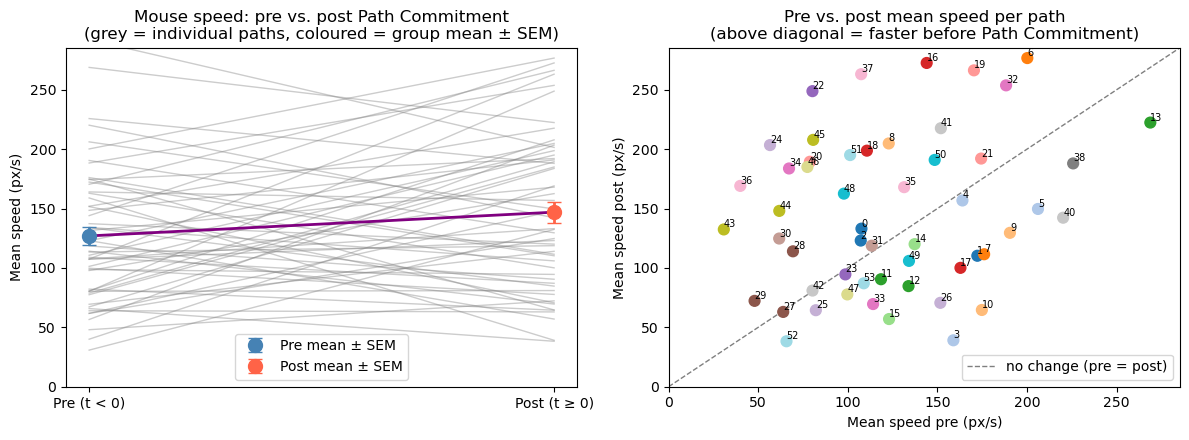

/var/home/almogmeir/miniconda3/envs/navigraph/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


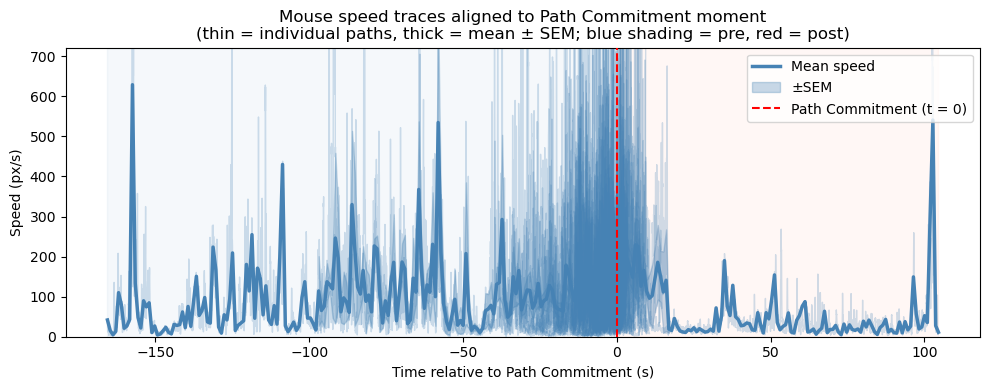

In [32]:
# ---------------------------------------------------------------------------
# Mouse speed: average movement speed before vs. after the Path Commitment moment
#
# Uses compute_path_speed from navigraph.analysis.speed_analysis — the same
# metric as speed_unit_correlation.ipynb: Euclidean headstage displacement
# between consecutive frames × FPS (px/s), uniform-smoothed over 5 frames.
#
# For each path we split the speed trace at t=0 (apex exit / Path Commitment)
# and report mean speed in the pre (t < 0) and post (t ≥ 0) epochs.
# ---------------------------------------------------------------------------
import importlib.util as _ilu
_sa_path = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/navigraph/analysis/speed_analysis.py')
_spec = _ilu.spec_from_file_location('speed_analysis', _sa_path)
_mod  = _ilu.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
compute_path_speed = _mod.compute_path_speed

SPEED_SMOOTH_FRAMES = 5   # same default as speed_analysis.py

# ── Compute per-path speed ────────────────────────────────────────────────────
speed_rows   = []
speed_traces = []   # (t_relative_to_t0, speed) per path

for _, event in change_of_mind_events_df.iterrows():
    t0_abs      = event['t0_abs']
    window_pre  = event['window_pre']
    window_post = event['window_post']

    start_frame = round((t0_abs - window_pre)  * FPS)
    end_frame   = round((t0_abs + window_post) * FPS)

    times_s, speed, _ = compute_path_speed(
        summary_df, start_frame, end_frame,
        fps=FPS,
        x_col=('headstage', 'x'),
        y_col=('headstage', 'y'),
        frame_col='frame_idx_global',
        smooth_window_frames=SPEED_SMOOTH_FRAMES,
    )
    if len(times_s) == 0:
        continue

    t_rel     = times_s - window_pre   # shift so Path Commitment = t=0
    pre_mask  = t_rel < 0
    post_mask = t_rel >= 0
    mean_pre  = np.nanmean(speed[pre_mask])  if pre_mask.any()  else np.nan
    mean_post = np.nanmean(speed[post_mask]) if post_mask.any() else np.nan

    speed_rows.append({
        'path_index':      event['path_index'],
        'from_port':       event['from_port'],
        'to_port':         event['to_port'],
        'window_pre_s':    window_pre,
        'window_post_s':   window_post,
        'mean_speed_pre':  mean_pre,
        'mean_speed_post': mean_post,
        'speed_ratio':     mean_pre / mean_post if mean_post > 1e-9 else np.nan,
        'speed_diff':      mean_pre - mean_post,
    })
    speed_traces.append((t_rel, speed))

speed_df = pd.DataFrame(speed_rows)

speed_dir = SESSION_DIR / 'speed_analysis'
speed_dir.mkdir(parents=True, exist_ok=True)
speed_df.to_csv(speed_dir / 'speed_pre_post.csv', index=False)

print(f"Paths analysed: {len(speed_df)}")
print(f"Mean speed pre  (px/s): {speed_df['mean_speed_pre'].mean():.1f} \u00b1 {speed_df['mean_speed_pre'].sem():.1f} SEM")
print(f"Mean speed post (px/s): {speed_df['mean_speed_post'].mean():.1f} \u00b1 {speed_df['mean_speed_post'].sem():.1f} SEM")
display(speed_df)

# ── Figure 1: per-path paired plot + pre-vs-post scatter ─────────────────────
fig1, axes1 = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: paired lines per path + group mean ± SEM
ax = axes1[0]
for _, row in speed_df.iterrows():
    ax.plot([0, 1], [row['mean_speed_pre'], row['mean_speed_post']],
            color='gray', alpha=0.4, linewidth=1)
ax.errorbar([0], [speed_df['mean_speed_pre'].mean()],
            yerr=[speed_df['mean_speed_pre'].sem()],
            fmt='o', color='steelblue', markersize=10, capsize=5, linewidth=2, label='Pre mean \u00b1 SEM')
ax.errorbar([1], [speed_df['mean_speed_post'].mean()],
            yerr=[speed_df['mean_speed_post'].sem()],
            fmt='o', color='tomato', markersize=10, capsize=5, linewidth=2, label='Post mean \u00b1 SEM')
ax.plot([0, 1], [speed_df['mean_speed_pre'].mean(), speed_df['mean_speed_post'].mean()],
        color='purple', linewidth=2)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Pre (t < 0)', 'Post (t \u2265 0)'])
ax.set_ylabel('Mean speed (px/s)')
ax.set_ylim(0, max(np.quantile(speed_df['mean_speed_pre'], 0.95), np.quantile(speed_df['mean_speed_post'], 0.95)) * 1.08)
ax.set_title('Mouse speed: pre vs. post Path Commitment\n(grey = individual paths, coloured = group mean \u00b1 SEM)')
ax.legend()

# Right: scatter pre vs post per path (above diagonal = faster before Path Commitment)
ax = axes1[1]
v_lo, v_hi = 0, max(np.quantile(speed_df['mean_speed_pre'], 0.95), np.quantile(speed_df['mean_speed_post'], 0.95)) * 1.08
ax.plot([v_lo, v_hi], [v_lo, v_hi], 'k--', linewidth=1, alpha=0.5, label='no change (pre = post)')
sc = ax.scatter(speed_df['mean_speed_pre'], speed_df['mean_speed_post'],
                c=speed_df['path_index'], cmap='tab20', s=60, zorder=3)
for _, row in speed_df.iterrows():
    ax.annotate(str(int(row['path_index'])),
                (row['mean_speed_pre'], row['mean_speed_post']),
                fontsize=7, ha='left', va='bottom')
ax.set_xlim(v_lo, v_hi)
ax.set_ylim(v_lo, v_hi)
ax.set_xlabel('Mean speed pre (px/s)')
ax.set_ylabel('Mean speed post (px/s)')
ax.set_title('Pre vs. post mean speed per path\n(above diagonal = faster before Path Commitment)')
ax.legend()

fig1.tight_layout()
fig1.savefig(speed_dir / 'speed_pre_vs_post.png', dpi=150)
plt.show()

# ── Figure 2: speed traces aligned to Path Commitment moment ──────────────────
all_t_min = min(t.min() for t, _ in speed_traces)
all_t_max = max(t.max() for t, _ in speed_traces)
t_common  = np.linspace(all_t_min, all_t_max, 300)

interp_arr = np.array([
    np.interp(t_common, t_rel, spd, left=np.nan, right=np.nan)
    for t_rel, spd in speed_traces
])
n_valid     = np.sum(~np.isnan(interp_arr), axis=0).clip(min=1)
mean_speed  = np.nanmean(interp_arr, axis=0)
sem_speed   = np.nanstd(interp_arr, axis=0, ddof=1) / np.sqrt(n_valid)

fig2, ax2 = plt.subplots(figsize=(10, 4))
for t_rel, spd in speed_traces:
    ax2.plot(t_rel, spd, color='steelblue', alpha=0.25, linewidth=1)
ax2.plot(t_common, mean_speed, color='steelblue', linewidth=2.5, label='Mean speed')
ax2.fill_between(t_common, mean_speed - sem_speed, mean_speed + sem_speed,
                 color='steelblue', alpha=0.3, label='\u00b1SEM')
ax2.axvline(0, color='red', linewidth=1.5, linestyle='--', label='Path Commitment (t = 0)', zorder=4)
ax2.axvspan(all_t_min, 0, color='steelblue', alpha=0.05)
ax2.axvspan(0, all_t_max, color='tomato',    alpha=0.05)
ax2.set_xlabel('Time relative to Path Commitment (s)')
ax2.set_ylabel('Speed (px/s)')
ax2.set_ylim(0, max(np.quantile(interp_arr[~np.isnan(interp_arr)], 0.99), 1) * 1.08)
ax2.set_title('Mouse speed traces aligned to Path Commitment moment\n'
              '(thin = individual paths, thick = mean \u00b1 SEM; blue shading = pre, red = post)')
ax2.legend()
fig2.tight_layout()
fig2.savefig(speed_dir / 'speed_traces_aligned.png', dpi=150)
plt.show()

Saved figure to /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/NPC4/09_06_2026/speed_analysis/speed_binned_pre_post.png


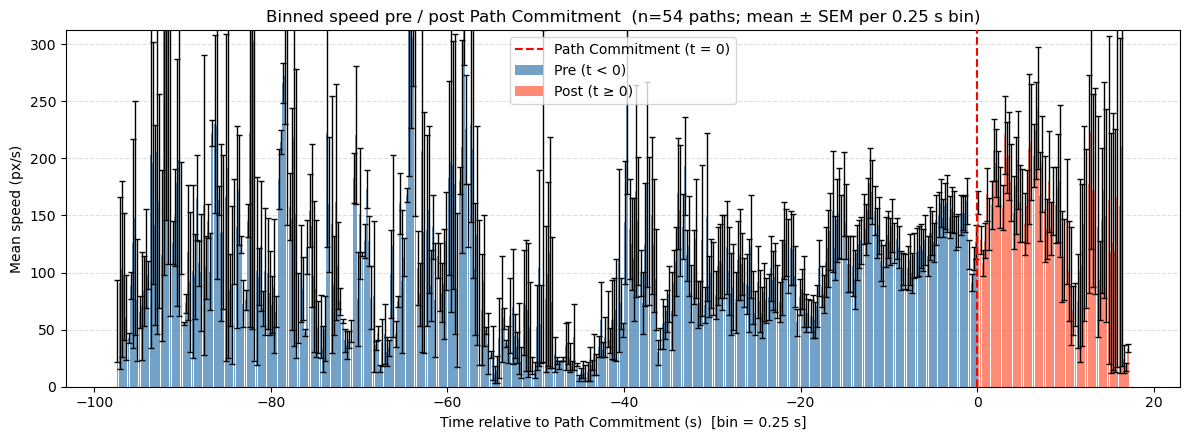

In [33]:
# ── Time-binned speed: how speed evolves across time relative to Path Commitment ──
#
# Splits each path's speed trace (from speed_traces above) into fixed-width bins
# and plots mean ± SEM per bin.  Coloured blue for pre, tomato for post.

BIN_WIDTH = 0.25   # seconds per bin — adjust as needed

# ── Build bin edges spanning the full time range ──────────────────────────────
_all_t_min = min(t.min() for t, _ in speed_traces)
_all_t_max = max(t.max() for t, _ in speed_traces)

_bin_edges   = np.arange(np.floor(_all_t_min / BIN_WIDTH) * BIN_WIDTH,
                          np.ceil(_all_t_max  / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH,
                          BIN_WIDTH)
_bin_centers = (_bin_edges[:-1] + _bin_edges[1:]) / 2

# ── Per-path × per-bin mean speed matrix ─────────────────────────────────────
_bin_matrix = np.full((len(speed_traces), len(_bin_centers)), np.nan)

for _pi, (_t_rel, _spd) in enumerate(speed_traces):
    for _bi, (_lo, _hi) in enumerate(zip(_bin_edges[:-1], _bin_edges[1:])):
        _mask = (_t_rel >= _lo) & (_t_rel < _hi)
        if _mask.sum() >= 2:
            _bin_matrix[_pi, _bi] = np.nanmean(_spd[_mask])

_n_valid_b    = np.sum(~np.isnan(_bin_matrix), axis=0)
_mean_binned  = np.nanmean(_bin_matrix, axis=0)
_sem_binned   = np.nanstd(_bin_matrix, axis=0, ddof=1) / np.sqrt(np.maximum(_n_valid_b, 1))

# suppress bins with fewer than 2 paths (edges)
_enough = _n_valid_b >= 2
_mean_binned[~_enough] = np.nan
_sem_binned[~_enough]  = np.nan

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4.5))

_pre_bins  = _bin_centers < 0
_post_bins = _bin_centers >= 0

ax.bar(_bin_centers[_pre_bins],  _mean_binned[_pre_bins],
       width=BIN_WIDTH * 0.85, color='steelblue', alpha=0.75, label='Pre (t < 0)',  zorder=2)
ax.bar(_bin_centers[_post_bins], _mean_binned[_post_bins],
       width=BIN_WIDTH * 0.85, color='tomato',    alpha=0.75, label='Post (t ≥ 0)', zorder=2)

ax.errorbar(_bin_centers[_enough], _mean_binned[_enough],
            yerr=_sem_binned[_enough],
            fmt='none', color='black', capsize=2, linewidth=1, zorder=3)

ax.axvline(0, color='red', linewidth=1.5, linestyle='--',
           label='Path Commitment (t = 0)', zorder=4)
ax.set_xlabel(f'Time relative to Path Commitment (s)  [bin = {BIN_WIDTH} s]')
ax.set_ylabel('Mean speed (px/s)')
ax.set_title(f'Binned speed pre / post Path Commitment  '
             f'(n={len(speed_traces)} paths; mean ± SEM per {BIN_WIDTH} s bin)')
ax.legend(fontsize=10)
ax.set_ylim(bottom=0, top=np.quantile(_mean_binned[_enough], 0.98) * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.tight_layout()
speed_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(speed_dir / 'speed_binned_pre_post.png', dpi=150, bbox_inches='tight')
print(f"Saved figure to {speed_dir / 'speed_binned_pre_post.png'}")
plt.show()


# Cross-session: speed and duration pre/post Path Commitment

For every recording session that has `node_summary_df.csv` + `summary_df.pkl`, recompute all long indirect paths (≥ 4 excess nodes), identify their apex/Path Commitment node (same algorithm as the single-session cell above), and report:

- **Duration** — seconds spent in the pre (t < 0) and post (t ≥ 0) epochs for each path.
- **Speed** — mean px/s in each epoch, using `compute_path_speed` with the same parameters as the single-session analysis.

**Summary levels:**
1. Overall (all paths across all sessions pooled) — mean ± STD + Wilcoxon test.
2. Per session — mean ± STD table.
3. Progress across days — line plot of per-session means ± STD.

  01_06_2026:  15 paths  speed pre=87±35  post=121±37 px/s  dur pre=10.2±4.9  post=6.2±3.5s
  02_06_2026:  37 paths  speed pre=64±28  post=119±50 px/s  dur pre=27.1±29.4  post=8.3±6.7s
  07_06_2026:  32 paths  speed pre=103±61  post=181±52 px/s  dur pre=10.0±9.4  post=5.4±3.1s
  08_06_2026:  46 paths  speed pre=81±44  post=119±71 px/s  dur pre=26.3±34.6  post=7.8±9.8s
  09_06_2026:  54 paths  speed pre=127±57  post=147±65 px/s  dur pre=19.2±25.2  post=6.2±14.2s
  10_05_2026:  28 paths  speed pre=85±31  post=132±135 px/s  dur pre=72.3±51.0  post=6.5±8.0s
  12_05_2026: 112 paths  speed pre=100±42  post=161±216 px/s  dur pre=20.1±20.6  post=8.4±9.7s
  13_05_2026: 110 paths  speed pre=86±64  post=158±263 px/s  dur pre=34.2±33.7  post=6.9±9.0s
  14_05_2026: 104 paths  speed pre=98±60  post=178±247 px/s  dur pre=31.6±38.0  post=4.6±5.7s
  16_06_2026:  55 paths  speed pre=90±40  post=130±66 px/s  dur pre=16.6±22.1  post=7.4±8.5s
  17_05_2026:  73 paths  speed pre=82±30  post=189±315 px/s  dur

,session,n,dur_pre μ,dur_pre σ,dur_post μ,dur_post σ,spd_pre μ,spd_pre σ,spd_post μ,spd_post σ,len_pre μ,len_pre σ,len_post μ,len_post σ
0,10_05,28,72.26,50.97,6.53,7.97,84.73,30.81,131.85,135.36,36.07,21.42,5.50,3.18
1,12_05,112,20.12,20.59,8.44,9.71,99.80,42.39,160.71,216.04,15.63,8.93,7.79,3.39
2,13_05,110,34.16,33.70,6.89,9.04,86.24,63.58,157.78,262.68,23.88,20.83,6.64,3.74
3,14_05,104,31.58,38.00,4.57,5.74,97.81,60.37,177.55,247.30,28.49,23.51,6.98,3.74
4,17_05,73,18.60,18.60,6.59,7.69,82.06,30.41,189.48,314.52,16.52,9.71,7.30,3.52
5,18_05,57,13.20,9.12,4.29,3.42,100.47,56.52,173.91,242.93,14.51,8.51,7.12,3.39
6,19_05,41,20.96,21.57,5.70,8.03,105.10,66.11,181.37,205.55,18.95,13.73,7.66,3.08
7,20_05,58,16.66,18.51,4.37,4.26,116.22,46.33,218.94,328.66,16.38,9.83,7.34,3.76
8,24_05,68,32.59,31.62,8.79,8.85,98.50,46.51,183.75,205.93,22.71,18.03,8.43,3.44
9,25_05,58,12.23,9.97,6.24,5.52,76.82,32.59,160.12,59.31,13.43,10.20,9.50,2.36


Saved figure to /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/NPC4/cross_session/speed_duration_pre_post.png


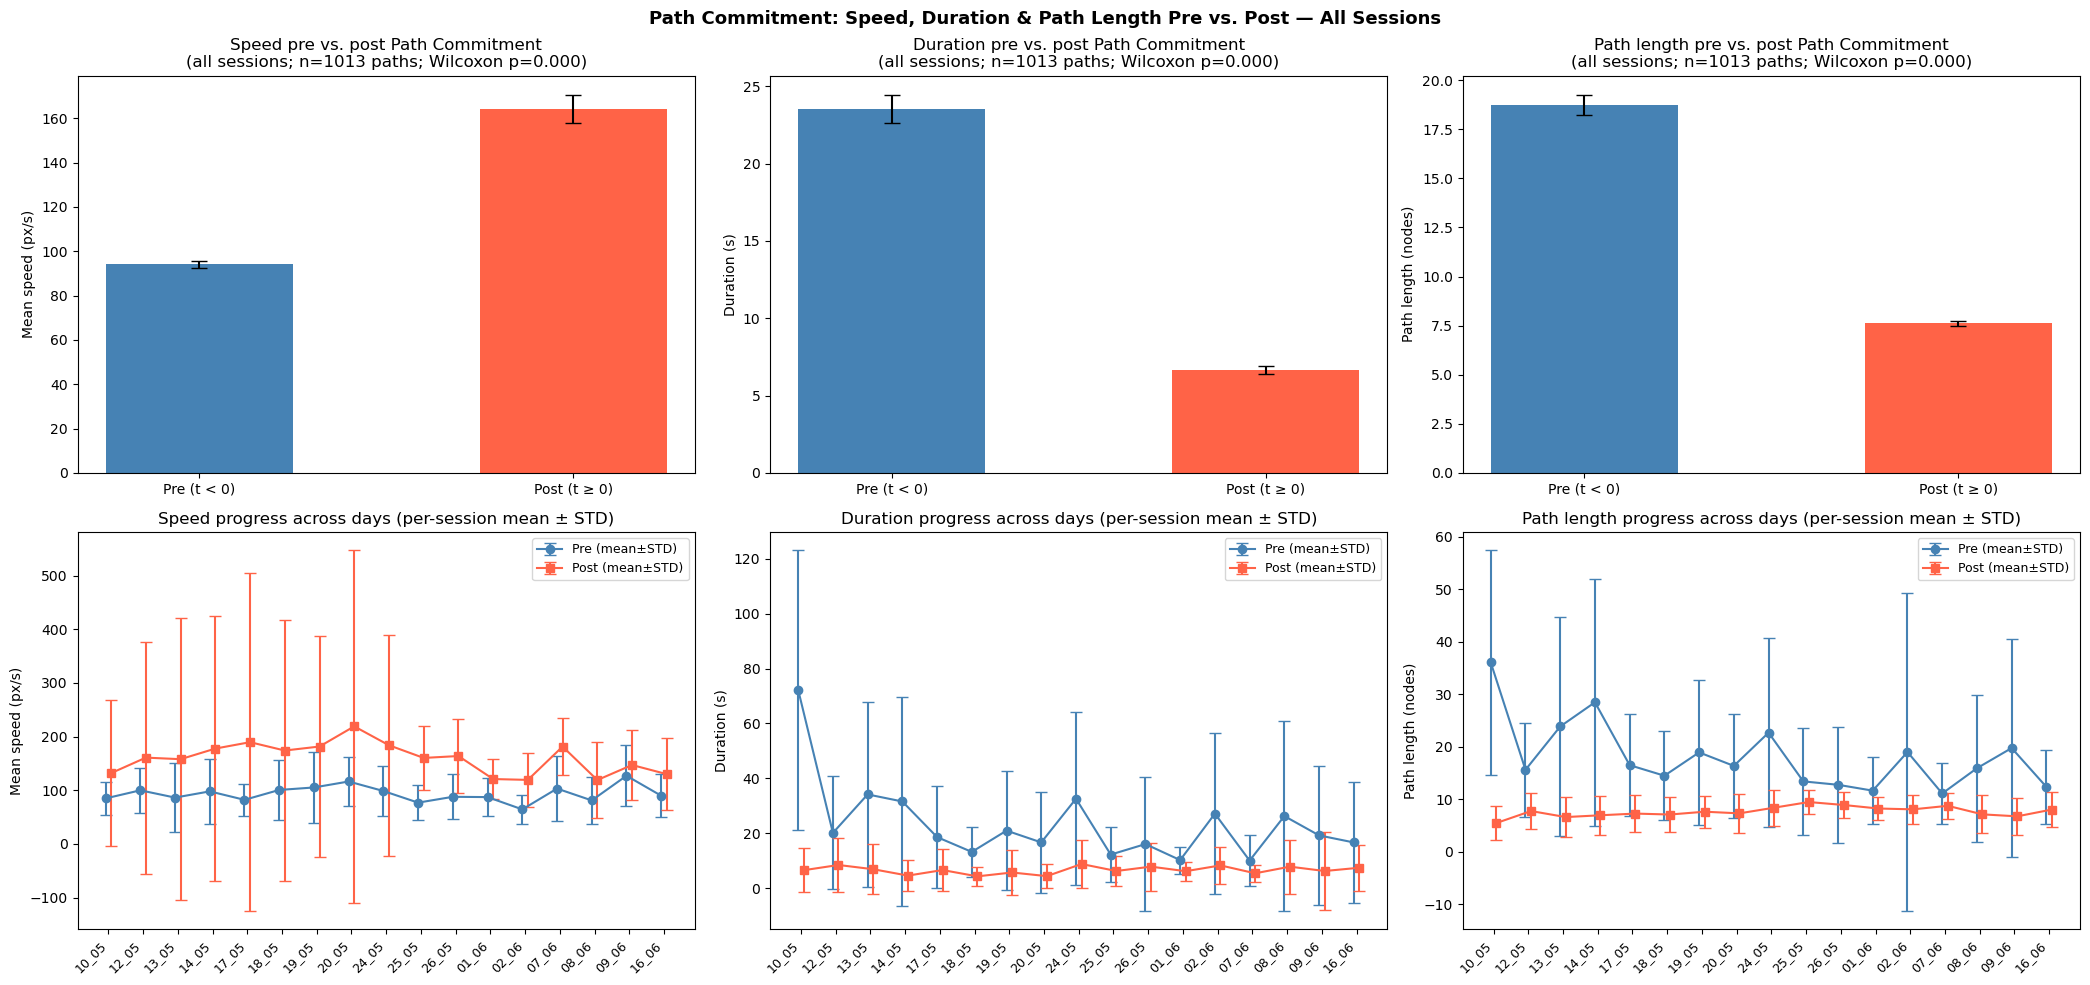

In [34]:
# ---------------------------------------------------------------------------
# Cross-session: speed (px/s) and duration (s) pre/post Path Commitment
#
# Iterates over all session output folders, recomputes long indirect paths
# (≥4 excess nodes) and their apex nodes using the shared maze graph G,
# then derives mean speed and duration for the pre (t < 0) and post (t ≥ 0)
# epochs relative to the apex exit (Path Commitment moment).
#
# Requires cells 4 (G), 15 (BASE_DIR_ALL), and 47 (compute_path_speed) to
# have already been run.
# ---------------------------------------------------------------------------
from datetime import date as _date
from scipy.stats import wilcoxon as _wilcoxon_cs

FPS_CS           = 40
EXCESS_THRESHOLD_CS = 4
SMOOTH_FRAMES_CS = 5

def _parse_date_cs(folder_name):
    p = folder_name.split('_')
    return _date(int(p[2]), int(p[1]), int(p[0]))

cs_per_path_rows     = []
cs_per_session_rows  = []
cs_speed_traces      = []   # (t_rel_s, speed_arr, session_name)

for d in sorted(BASE_DIR_ALL.iterdir()):
    if not d.is_dir() or not SESSION_RE.match(d.name):
        continue
    node_csv = d / 'node_summary_df.csv'
    summ_pkl = d / 'summary_df.pkl'
    if not node_csv.exists() or not summ_pkl.exists():
        print(f'  Skipping {d.name} — missing node_summary_df.csv or summary_df.pkl')
        continue

    node_df = pd.read_csv(node_csv).sort_values('node_visit_idx').reset_index(drop=True)
    with open(summ_pkl, 'rb') as _f:
        _sdf = pickle.load(_f)

    # ── Identify long indirect path starts (same logic as cells 10 & 15) ──
    path_segs, prev_label = [], None
    for _, _row in node_df.iterrows():
        _label = _row['path_pair_label']
        if pd.isna(_label):
            prev_label = None
            continue
        if _label != prev_label:
            path_segs.append(_row)
        prev_label = _label

    session_rows = []
    for seg_row in path_segs:
        if seg_row['port_to_port_path_type'] != 'indirect':
            continue
        seq_len  = int(seg_row['path_seq_length_unique'])
        excess_n = seq_len - seg_row['path_shortest_length']
        if excess_n < EXCESS_THRESHOLD_CS:
            continue

        start_nv = int(seg_row['node_visit_idx'])
        seq_rows = node_df[
            (node_df['node_visit_idx'] >= start_nv) &
            (node_df['node_visit_idx'] <= start_nv + seq_len)
        ].reset_index(drop=True)
        if len(seq_rows) < 3:
            continue

        seq_nodes = seq_rows['node_name'].tolist()
        dest_node = seq_nodes[-1]

        # Find apex: earliest node from which the remaining trajectory is the
        # direct/shortest path to the destination (same algorithm as cell 10).
        apex_idx = None
        for i_node, node in enumerate(seq_nodes):
            try:
                sp = nx.shortest_path(G, node, dest_node)
            except (nx.NetworkXNoPath, nx.NodeNotFound):
                continue
            if seq_nodes[i_node:] == sp:
                apex_idx = i_node
                break
        if apex_idx is None:
            continue

        n_nodes_pre    = apex_idx + 1
        n_nodes_post   = len(seq_nodes) - apex_idx
        apex_r         = seq_rows.iloc[apex_idx]
        t0_abs         = apex_r['end_frame']             / FPS_CS   # mouse exits apex
        path_start_abs = seq_rows.iloc[0]['start_frame'] / FPS_CS
        path_end_abs   = seq_rows.iloc[-1]['start_frame'] / FPS_CS  # matches cell 23
        window_pre     = t0_abs - path_start_abs
        window_post    = path_end_abs - t0_abs
        if window_pre <= 0 or window_post <= 0:
            continue

        # ── Speed (same parameters as the single-session speed cell) ──────
        sf = int(seq_rows.iloc[0]['start_frame'])
        ef = int(seq_rows.iloc[-1]['start_frame'])
        try:
            times_s, speed, _ = compute_path_speed(
                _sdf, sf, ef,
                fps=FPS_CS,
                x_col=('headstage', 'x'),
                y_col=('headstage', 'y'),
                frame_col='frame_idx_global',
                smooth_window_frames=SMOOTH_FRAMES_CS,
            )
        except Exception as _e:
            print(f'  {d.name}: speed error — {_e}')
            continue
        if len(times_s) == 0:
            continue

        t_rel_cs = times_s - window_pre   # shift so Path Commitment = t=0
        cs_speed_traces.append((t_rel_cs, speed, d.name))

        pre_mask  = times_s < window_pre    # window_pre = time of apex exit
        post_mask = times_s >= window_pre
        mean_speed_pre  = float(np.nanmean(speed[pre_mask]))  if pre_mask.any()  else np.nan
        mean_speed_post = float(np.nanmean(speed[post_mask])) if post_mask.any() else np.nan

        entry = {
            'session':         d.name,
            'date':            _parse_date_cs(d.name),
            'path_pair_label': str(seg_row['path_pair_label']),
            'excess_nodes':    int(excess_n),
            'window_pre_s':    window_pre,
            'window_post_s':   window_post,
            'mean_speed_pre':  mean_speed_pre,
            'mean_speed_post': mean_speed_post,
            'speed_diff':      mean_speed_pre - mean_speed_post,
            'speed_ratio':     mean_speed_pre / mean_speed_post
                               if mean_speed_post > 1e-9 else np.nan,
            'n_nodes_pre':     n_nodes_pre,
            'n_nodes_post':    n_nodes_post,
        }
        session_rows.append(entry)
        cs_per_path_rows.append(entry)

    n = len(session_rows)
    _df_s = pd.DataFrame(session_rows) if n > 0 else pd.DataFrame(
        columns=['window_pre_s','window_post_s','mean_speed_pre','mean_speed_post','n_nodes_pre','n_nodes_post'])
    cs_per_session_rows.append({
        'session':         d.name,
        'date':            _parse_date_cs(d.name),
        'n_paths':         n,
        'mean_dur_pre':    _df_s['window_pre_s'].mean()        if n else np.nan,
        'std_dur_pre':     _df_s['window_pre_s'].std(ddof=1)   if n > 1 else np.nan,
        'mean_dur_post':   _df_s['window_post_s'].mean()       if n else np.nan,
        'std_dur_post':    _df_s['window_post_s'].std(ddof=1)  if n > 1 else np.nan,
        'mean_speed_pre':  _df_s['mean_speed_pre'].mean()      if n else np.nan,
        'std_speed_pre':   _df_s['mean_speed_pre'].std(ddof=1) if n > 1 else np.nan,
        'mean_speed_post': _df_s['mean_speed_post'].mean()     if n else np.nan,
        'std_speed_post':  _df_s['mean_speed_post'].std(ddof=1) if n > 1 else np.nan,
        'mean_len_pre':    _df_s['n_nodes_pre'].mean()          if n else np.nan,
        'std_len_pre':     _df_s['n_nodes_pre'].std(ddof=1)     if n > 1 else np.nan,
        'mean_len_post':   _df_s['n_nodes_post'].mean()         if n else np.nan,
        'std_len_post':    _df_s['n_nodes_post'].std(ddof=1)    if n > 1 else np.nan,
    })
    if n:
        print(f'  {d.name}: {n:3d} paths'
              f'  speed pre={_df_s["mean_speed_pre"].mean():.0f}±{_df_s["mean_speed_pre"].std(ddof=1):.0f}'
              f'  post={_df_s["mean_speed_post"].mean():.0f}±{_df_s["mean_speed_post"].std(ddof=1):.0f} px/s'
              f'  dur pre={_df_s["window_pre_s"].mean():.1f}±{_df_s["window_pre_s"].std(ddof=1):.1f}'
              f'  post={_df_s["window_post_s"].mean():.1f}±{_df_s["window_post_s"].std(ddof=1):.1f}s')
    else:
        print(f'  {d.name}: 0 qualifying paths')

cs_per_path_df    = (pd.DataFrame(cs_per_path_rows)
                       .sort_values(['date', 'session']).reset_index(drop=True))
cs_per_session_df = (pd.DataFrame(cs_per_session_rows)
                       .sort_values('date').reset_index(drop=True))
cs_per_session_df['day_label'] = (cs_per_session_df['session']
                                   .str.replace(r'_\d{4}$', '', regex=True))

# ── Overall stats (all paths pooled) ─────────────────────────────────────────
print('\n=== Overall stats (all sessions combined) ===')
for col, label in [
    ('window_pre_s',    'Duration pre  (s)'),
    ('window_post_s',   'Duration post (s)'),
    ('mean_speed_pre',  'Speed pre  (px/s)'),
    ('mean_speed_post', 'Speed post (px/s)'),
    ('n_nodes_pre',     'Path len pre (nodes)'),
    ('n_nodes_post',    'Path len post (nodes)'),
]:
    vals = cs_per_path_df[col].dropna()
    print(f'  {label}: mean={vals.mean():.2f}  std={vals.std(ddof=1):.2f}  n={len(vals)}')

# Wilcoxon paired tests
_paired = cs_per_path_df[['window_pre_s','window_post_s',
                           'mean_speed_pre','mean_speed_post',
                           'n_nodes_pre','n_nodes_post']].dropna()
if len(_paired) > 1:
    _ws, _ps = _wilcoxon_cs(_paired['mean_speed_pre'], _paired['mean_speed_post'])
    _wd, _pd = _wilcoxon_cs(_paired['window_pre_s'],   _paired['window_post_s'])
    _wl, _pl = _wilcoxon_cs(_paired['n_nodes_pre'],    _paired['n_nodes_post'])
    print(f'  Speed Wilcoxon (two-sided):      W={_ws:.1f}, p={_ps:.4f}')
    print(f'  Duration Wilcoxon (two-sided):   W={_wd:.1f}, p={_pd:.4f}')
    print(f'  Path len Wilcoxon (two-sided):   W={_wl:.1f}, p={_pl:.4f}')

# ── Per-session summary table ─────────────────────────────────────────────────
print('\n=== Per-session summary ===')
display(cs_per_session_df[[
    'day_label','n_paths',
    'mean_dur_pre','std_dur_pre','mean_dur_post','std_dur_post',
    'mean_speed_pre','std_speed_pre','mean_speed_post','std_speed_post',
    'mean_len_pre','std_len_pre','mean_len_post','std_len_post',
]].rename(columns={
    'day_label':'session', 'n_paths':'n',
    'mean_dur_pre':'dur_pre μ','std_dur_pre':'dur_pre σ',
    'mean_dur_post':'dur_post μ','std_dur_post':'dur_post σ',
    'mean_speed_pre':'spd_pre μ','std_speed_pre':'spd_pre σ',
    'mean_speed_post':'spd_post μ','std_speed_post':'spd_post σ',
    'mean_len_pre':'len_pre μ','std_len_pre':'len_pre σ',
    'mean_len_post':'len_post μ','std_len_post':'len_post σ',
}).round(2))

# ── Figures ──────────────────────────────────────────────────────────────────
_session_order  = cs_per_session_df['session'].tolist()
_session_colors = dict(zip(
    _session_order,
    plt.cm.tab10(np.linspace(0, 0.9, max(len(_session_order), 1)))))

fig, axes = plt.subplots(2, 3, figsize=(21, 10))
fig.suptitle('Path Commitment: Speed, Duration & Path Length Pre vs. Post — All Sessions',
             fontweight='bold', fontsize=13)

# ── Panel A: bar graph — mean speed pre vs. post (all sessions pooled) ──────
ax = axes[0, 0]
_pre_spd  = cs_per_path_df['mean_speed_pre'].dropna()
_post_spd = cs_per_path_df['mean_speed_post'].dropna()
ax.bar([0, 1], [_pre_spd.mean(), _post_spd.mean()],
       color=['steelblue', 'tomato'], width=0.5, zorder=2)
ax.errorbar([0, 1], [_pre_spd.mean(), _post_spd.mean()],
            yerr=[_pre_spd.sem(), _post_spd.sem()],
            fmt='none', color='black', capsize=6, linewidth=1.5, zorder=3)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Pre (t < 0)', 'Post (t \u2265 0)'])
ax.set_ylabel('Mean speed (px/s)')
ax.set_ylim(bottom=0)
if len(_paired) > 1:
    ax.set_title(f'Speed pre vs. post Path Commitment\n(all sessions; n={len(_pre_spd)} paths; Wilcoxon p={_ps:.3f})')
else:
    ax.set_title('Speed pre vs. post Path Commitment\n(all sessions)')

# ── Panel B: bar graph — mean duration pre vs. post (all sessions pooled) ────
ax = axes[0, 1]
_pre_dur  = cs_per_path_df['window_pre_s'].dropna()
_post_dur = cs_per_path_df['window_post_s'].dropna()
ax.bar([0, 1], [_pre_dur.mean(), _post_dur.mean()],
       color=['steelblue', 'tomato'], width=0.5, zorder=2)
ax.errorbar([0, 1], [_pre_dur.mean(), _post_dur.mean()],
            yerr=[_pre_dur.sem(), _post_dur.sem()],
            fmt='none', color='black', capsize=6, linewidth=1.5, zorder=3)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Pre (t < 0)', 'Post (t \u2265 0)'])
ax.set_ylabel('Duration (s)')
ax.set_ylim(bottom=0)
if len(_paired) > 1:
    ax.set_title(f'Duration pre vs. post Path Commitment\n(all sessions; n={len(_pre_dur)} paths; Wilcoxon p={_pd:.3f})')
else:
    ax.set_title('Duration pre vs. post Path Commitment\n(all sessions)')

# ── Panel C: speed per session across days (mean ± STD) ──────────────────────
ax = axes[1, 0]
_valid = cs_per_session_df[cs_per_session_df['n_paths'] > 0].reset_index(drop=True)
_x  = np.arange(len(_valid))
_xl = _valid['day_label'].tolist()
ax.errorbar(_x - 0.08, _valid['mean_speed_pre'],  yerr=_valid['std_speed_pre'],
            fmt='o-', color='steelblue', capsize=4, linewidth=1.5, markersize=6,
            label='Pre (mean±STD)')
ax.errorbar(_x + 0.08, _valid['mean_speed_post'], yerr=_valid['std_speed_post'],
            fmt='s-', color='tomato',    capsize=4, linewidth=1.5, markersize=6,
            label='Post (mean±STD)')
ax.set_xticks(_x)
ax.set_xticklabels(_xl, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean speed (px/s)')
ax.set_title('Speed progress across days (per-session mean ± STD)')
ax.legend(fontsize=9)

# ── Panel D: duration per session across days (mean ± STD) ───────────────────
ax = axes[1, 1]
ax.errorbar(_x - 0.08, _valid['mean_dur_pre'],  yerr=_valid['std_dur_pre'],
            fmt='o-', color='steelblue', capsize=4, linewidth=1.5, markersize=6,
            label='Pre (mean±STD)')
ax.errorbar(_x + 0.08, _valid['mean_dur_post'], yerr=_valid['std_dur_post'],
            fmt='s-', color='tomato',    capsize=4, linewidth=1.5, markersize=6,
            label='Post (mean±STD)')
ax.set_xticks(_x)
ax.set_xticklabels(_xl, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Duration (s)')
ax.set_title('Duration progress across days (per-session mean ± STD)')
ax.legend(fontsize=9)


# ── Panel E: path-length pre vs. post (all sessions pooled) ───────────
ax = axes[0, 2]
_pre_len  = cs_per_path_df['n_nodes_pre'].dropna()
_post_len = cs_per_path_df['n_nodes_post'].dropna()
ax.bar([0, 1], [_pre_len.mean(), _post_len.mean()],
       color=['steelblue', 'tomato'], width=0.5, zorder=2)
ax.errorbar([0, 1], [_pre_len.mean(), _post_len.mean()],
            yerr=[_pre_len.sem(), _post_len.sem()],
            fmt='none', color='black', capsize=6, linewidth=1.5, zorder=3)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Pre (t < 0)', 'Post (t ≥ 0)'])
ax.set_ylabel('Path length (nodes)')
ax.set_ylim(bottom=0)
if len(_paired) > 1:
    ax.set_title(f'Path length pre vs. post Path Commitment\n'
                f'(all sessions; n={len(_pre_len)} paths; Wilcoxon p={_pl:.3f})')
else:
    ax.set_title('Path length pre vs. post Path Commitment\n(all sessions)')

# ── Panel F: path-length per session across days (mean ± STD) ───────
ax = axes[1, 2]
ax.errorbar(_x - 0.08, _valid['mean_len_pre'],  yerr=_valid['std_len_pre'],
            fmt='o-', color='steelblue', capsize=4, linewidth=1.5, markersize=6,
            label='Pre (mean±STD)')
ax.errorbar(_x + 0.08, _valid['mean_len_post'], yerr=_valid['std_len_post'],
            fmt='s-', color='tomato',    capsize=4, linewidth=1.5, markersize=6,
            label='Post (mean±STD)')
ax.set_xticks(_x)
ax.set_xticklabels(_xl, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Path length (nodes)')
ax.set_title('Path length progress across days (per-session mean ± STD)')
ax.legend(fontsize=9)

fig.tight_layout()
CROSS_SESSION_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(CROSS_SESSION_DIR / 'speed_duration_pre_post.png', dpi=150, bbox_inches='tight')
print(f"Saved figure to {CROSS_SESSION_DIR / 'speed_duration_pre_post.png'}")
plt.show()


/var/home/almogmeir/miniconda3/envs/navigraph/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_10864/3419917577.py:49: RuntimeWarning: Mean of empty slice
  _m_s = np.nanmean(_sub, axis=0)


Saved figure to /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/NPC4/cross_session/binned_speed_around_commitment.png


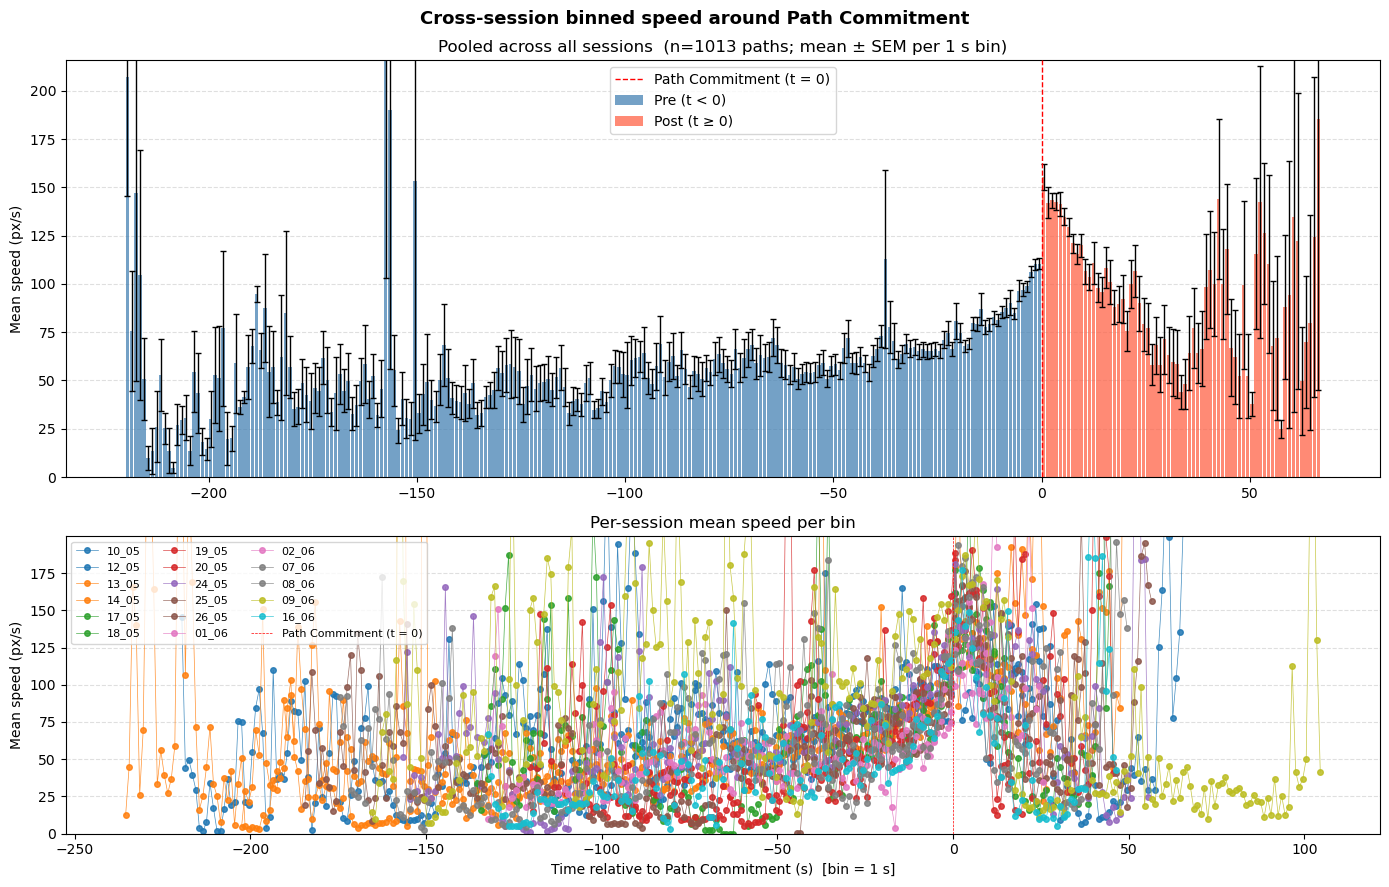

In [35]:
# ── Cross-session binned speed: temporal evolution around Path Commitment ────
#
# Uses cs_speed_traces collected by the cross-session loop above.
# Each trace is time-shifted so Path Commitment = t=0, then binned.
# The top panel shows the pooled mean ± SEM bar chart (all sessions).
# The bottom panel shows per-session mean lines so session differences are visible.

BIN_WIDTH_CS = 1   # seconds per bin — adjust as needed

# ── Build bin edges ───────────────────────────────────────────────────────────
_all_t_min_cs = min(t.min() for t, _, _ in cs_speed_traces)
_all_t_max_cs = max(t.max() for t, _, _ in cs_speed_traces)

_bin_edges_cs   = np.arange(np.floor(_all_t_min_cs / BIN_WIDTH_CS) * BIN_WIDTH_CS,
                              np.ceil(_all_t_max_cs  / BIN_WIDTH_CS) * BIN_WIDTH_CS + BIN_WIDTH_CS,
                              BIN_WIDTH_CS)
_bin_centers_cs = (_bin_edges_cs[:-1] + _bin_edges_cs[1:]) / 2
n_bins_cs       = len(_bin_centers_cs)

# ── Per-path × per-bin mean speed matrix ─────────────────────────────────────
_bmat_cs  = np.full((len(cs_speed_traces), n_bins_cs), np.nan)
_sessions_per_trace = [s for _, _, s in cs_speed_traces]

for _pi, (_t_rel, _spd, _sess) in enumerate(cs_speed_traces):
    for _bi, (_lo, _hi) in enumerate(zip(_bin_edges_cs[:-1], _bin_edges_cs[1:])):
        _mask = (_t_rel >= _lo) & (_t_rel < _hi)
        if _mask.sum() >= 2:
            _bmat_cs[_pi, _bi] = np.nanmean(_spd[_mask])

_n_valid_cs   = np.sum(~np.isnan(_bmat_cs), axis=0)
_mean_cs      = np.nanmean(_bmat_cs, axis=0)
_sem_cs       = np.nanstd(_bmat_cs, axis=0, ddof=1) / np.sqrt(np.maximum(_n_valid_cs, 1))
_enough_cs    = _n_valid_cs >= 2
_mean_cs[~_enough_cs] = np.nan
_sem_cs[~_enough_cs]  = np.nan

# ── Per-session bin means (for the lower panel) ───────────────────────────────
_uniq_sessions_cs = cs_per_session_df[cs_per_session_df['n_paths'] > 0]['session'].tolist()
_uniq_labels_cs   = cs_per_session_df[cs_per_session_df['n_paths'] > 0]['day_label'].tolist()
_sess_colors_cs   = plt.cm.tab10(np.linspace(0, 0.9, max(len(_uniq_sessions_cs), 1)))

_sess_bin_means = {}   # session -> per-bin mean across its paths
for _sess in _uniq_sessions_cs:
    _idx = [i for i, s in enumerate(_sessions_per_trace) if s == _sess]
    if not _idx:
        continue
    _sub = _bmat_cs[_idx, :]
    _n_s = np.sum(~np.isnan(_sub), axis=0)
    _m_s = np.nanmean(_sub, axis=0)
    _m_s[_n_s < 1] = np.nan
    _sess_bin_means[_sess] = _m_s

# ── Figure: 2 rows ────────────────────────────────────────────────────────────
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 9),
                                       gridspec_kw={'height_ratios': [1.4, 1]})
fig.suptitle('Cross-session binned speed around Path Commitment',
             fontweight='bold', fontsize=13)

# Top: pooled bar chart
_pre_b  = _bin_centers_cs < 0
_post_b = _bin_centers_cs >= 0
ax_top.bar(_bin_centers_cs[_pre_b],  _mean_cs[_pre_b],
           width=BIN_WIDTH_CS * 0.85, color='steelblue', alpha=0.75,
           label='Pre (t < 0)', zorder=2)
ax_top.bar(_bin_centers_cs[_post_b], _mean_cs[_post_b],
           width=BIN_WIDTH_CS * 0.85, color='tomato',    alpha=0.75,
           label='Post (t ≥ 0)', zorder=2)
ax_top.errorbar(_bin_centers_cs[_enough_cs], _mean_cs[_enough_cs],
                yerr=_sem_cs[_enough_cs],
                fmt='none', color='black', capsize=2, linewidth=1, zorder=3)
ax_top.axvline(0, color='red', linewidth=1, linestyle='--',
               label='Path Commitment (t = 0)', zorder=4)
ax_top.set_ylabel('Mean speed (px/s)')
ax_top.set_title(f'Pooled across all sessions  '
                 f'(n={len(cs_speed_traces)} paths; mean ± SEM per {BIN_WIDTH_CS} s bin)')
ax_top.legend(fontsize=10)
ax_top.set_ylim(bottom=0, top=np.quantile(_mean_cs[_enough_cs], 0.995) * 1.08)
ax_top.grid(axis='y', linestyle='--', alpha=0.4)

# Bottom: per-session mean lines
for _ci, (_sess, _lbl) in enumerate(zip(_uniq_sessions_cs, _uniq_labels_cs)):
    if _sess not in _sess_bin_means:
        continue
    _m = _sess_bin_means[_sess]
    _valid_b = ~np.isnan(_m)
    ax_bot.plot(_bin_centers_cs[_valid_b], _m[_valid_b],
                color=_sess_colors_cs[_ci], linewidth=0.5,
                marker='o', markersize=4, label=_lbl, alpha=0.85)
ax_bot.axvline(0, color='red', linewidth=0.5, linestyle='--',
               label='Path Commitment (t = 0)', zorder=4)
ax_bot.set_xlabel(f'Time relative to Path Commitment (s)  [bin = {BIN_WIDTH_CS} s]')
ax_bot.set_ylabel('Mean speed (px/s)')
ax_bot.set_title('Per-session mean speed per bin')
ax_bot.legend(fontsize=8, ncol=3)
ax_bot.set_ylim(bottom=0, top=np.quantile(_mean_cs[_enough_cs], 0.995))
ax_bot.grid(axis='y', linestyle='--', alpha=0.4)

fig.tight_layout()
CROSS_SESSION_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(CROSS_SESSION_DIR / 'binned_speed_around_commitment.png', dpi=150, bbox_inches='tight')
print(f"Saved figure to {CROSS_SESSION_DIR / 'binned_speed_around_commitment.png'}")
plt.show()


Saved figure to /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/NPC4/cross_session/path_length_distributions.png


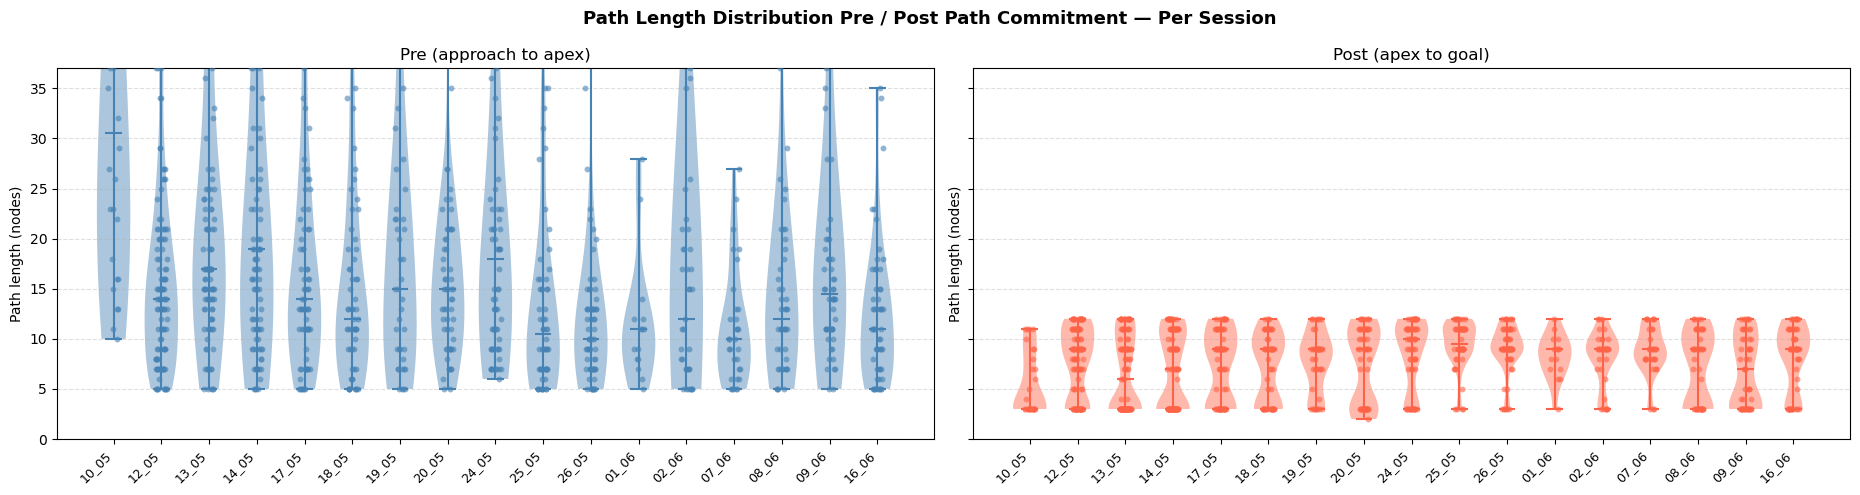

In [36]:
# ── Distribution of path lengths pre / post Path Commitment — per session ────
#
# cs_per_path_df has one row per long indirect path with n_nodes_pre / n_nodes_post.
# Show violin + strip plots grouped by session so the full spread is visible.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

_sessions = cs_per_session_df[cs_per_session_df['n_paths'] > 0]['session'].tolist()
_day_labels = cs_per_session_df[cs_per_session_df['n_paths'] > 0]['day_label'].tolist()
n_sess = len(_sessions)

fig, axes = plt.subplots(1, 2, figsize=(max(10, n_sess * 1.1), 5), sharey=True)
fig.suptitle('Path Length Distribution Pre / Post Path Commitment — Per Session',
             fontweight='bold', fontsize=13)

for ax, col, color, label in [
    (axes[0], 'n_nodes_pre',  'steelblue', 'Pre (approach to apex)'),
    (axes[1], 'n_nodes_post', 'tomato',    'Post (apex to goal)'),
]:
    for i, sess in enumerate(_sessions):
        vals = cs_per_path_df.loc[cs_per_path_df['session'] == sess, col].dropna().values
        if len(vals) == 0:
            continue
        # violin
        parts = ax.violinplot(vals, positions=[i], widths=0.7,
                              showmedians=True, showextrema=True)
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_alpha(0.45)
        for part_key in ('cmedians', 'cmins', 'cmaxes', 'cbars'):
            if part_key in parts:
                parts[part_key].set_color(color)
                parts[part_key].set_linewidth(1.5)
        # jittered strip
        jitter = np.random.default_rng(42).uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(i + jitter, vals, color=color, alpha=0.6, s=18, zorder=3, linewidths=0)

    ax.set_xticks(range(n_sess))
    ax.set_xticklabels(_day_labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Path length (nodes)')
    ax.set_title(label)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_ylim(bottom=0, top=np.quantile(cs_per_path_df[['n_nodes_pre','n_nodes_post']].values.flatten(), 0.95))

fig.tight_layout()
CROSS_SESSION_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(CROSS_SESSION_DIR / 'path_length_distributions.png', dpi=150, bbox_inches='tight')
print(f"Saved figure to {CROSS_SESSION_DIR / 'path_length_distributions.png'}")
plt.show()


# Videos: Indirect Paths with Path Commitment Annotation

For each of the 17 long indirect paths, create a side-by-side video (raw video + maze graph) with the Path Commitment moment annotated:
- **Graph**: the apex node is always highlighted with a crosshair — orange/amber before the event, switching to red at the Path Commitment frame.
- **Video**: a bold "PATH COMMITMENT" banner appears at the apex-exit frame and remains on screen for the rest of the clip.
- **Flash**: a red border fades out over ~2 seconds immediately after the event.

Videos are saved under `resources/outputs/{subject}/{session}/indirect_path_videos/`.

In [37]:
from pathlib import Path
import pandas as pd

# Video file (same naming convention as align_frames_trials.ipynb)
maze_video_path = str(RESOURCES_DIR / 'maze_videos' / f'{SUBJECT}_{YYYY}_{MM}_{DD}.mp4')
print(f"Video path : {maze_video_path}")
print(f"Video exists: {Path(maze_video_path).exists()}")

# Port label screen positions (pixel coords in the original 1280×960 video),
# keyed by the PHYSICAL maze node rather than by Target number: the Target
# labels move between nodes across subjects and layout periods (NPC4 swaps
# ports 3/4, NPC1 swapped 7/8 on 07/09/2025) but the ports themselves do not.
# Coordinates measured on an NPC1 post-07/09/2025 frame.
PORT_LABEL_XY = {
    'R522': (945,  45),
    'R526': (700,  45),
    'L56':  (350,  45),
    'L510': (120,  45),
    'L521': (120, 890),
    'L525': (360, 890),
    'R59':  (945, 890),
    'R55':  (695, 890),
}

port_label_positions = pd.DataFrame(
    [{'port_label': port_map[node], 'x': x, 'y': y}
     for node, (x, y) in PORT_LABEL_XY.items()]
).sort_values('port_label').reset_index(drop=True)
display(port_label_positions)

# Reward leaf nodes and their parents (used for reward icon placement on the
# video) come from the port-layout cell above, so the per-subject and
# per-date-range wiring is defined in exactly one place.
print(f"Reward ports ({SUBJECT}): "
      + ", ".join(f"{p}->{reward_leaf_parents[p][0]}" for p in sorted(reward_leaf_parents)))


Video path : /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/maze_videos/NPC4_2026_06_09.mp4
Video exists: True


,port_label,x,y
0,Target1,945,45
1,Target2,700,45
2,Target3,120,45
3,Target4,350,45
4,Target5,120,890
5,Target6,360,890
6,Target7,945,890
7,Target8,695,890


Reward ports (NPC4): 1->R522, 2->R526, 3->L510, 4->L56, 5->L521, 6->L525, 7->R59, 8->R55


In [38]:
def create_indirect_path_video(start_frame, end_frame, output_path, summary_df, G, node_positions, port_map,
                               video_path, change_of_mind_frame=None, apex_node_id=None,
                               reward_leaf_parents=None, fps=40, video_height=720,
                               graph_width=400, bodypart_colors=None,
                               port_label_positions=None, port_colors=None):
    """
    Side-by-side video (raw video + maze graph) for one indirect path, with the
    Path Commitment moment annotated:
      - Apex node shown on the graph with a crosshair (orange before event, red after).
      - 'PATH COMMITMENT' banner appears on the video panel from change_of_mind_frame onward.
      - Red border flash fades out over ~2 s immediately after the event.
    Based on create_side_by_side_video from align_frames_trials.ipynb.
    """
    import cv2
    import numpy as np
    import pandas as pd
    from pathlib import Path

    video_path = Path(video_path)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    reward_size_to_px = {}

    if reward_leaf_parents is None:
        reward_leaf_parents = {}

    def _resolve_column(df, candidates):
        cols = df.columns
        candidate_l = [c.lower() for c in candidates]
        if isinstance(cols, pd.MultiIndex):
            for col in cols:
                parts = [str(v).strip().lower() for v in col]
                for candidate in candidate_l:
                    if candidate in parts:
                        return col
            return None
        lower_map = {str(col).strip().lower(): col for col in cols}
        for candidate in candidate_l:
            if candidate in lower_map:
                return lower_map[candidate]
        return None

    def _resolve_tracking_column(df, bodypart, field):
        cols = df.columns
        if isinstance(cols, pd.MultiIndex):
            for col in cols:
                if len(col) >= 2 and str(col[0]) == bodypart and str(col[1]).lower() == field.lower():
                    return col
            return None
        for col in [f'{bodypart}_{field}', f'{bodypart}.{field}', f'{bodypart}{field}']:
            if col in cols:
                return col
        return None

    def _normalize_node(value):
        if value is None or pd.isna(value):
            return None
        text = str(value).strip().strip('"').strip("'")
        if text.lower() in {'none', 'nan', ''}:
            return None
        return text if text in node_positions else None

    def _parse_edge_value(value):
        if value is None or pd.isna(value):
            return None
        if isinstance(value, (list, tuple)) and len(value) == 2:
            src = _normalize_node(value[0])
            dst = _normalize_node(value[1])
            if src is not None and dst is not None:
                return (src, dst)
            return None
        text = str(value)
        if text.lower().strip() in {'none', 'nan', ''}:
            return None
        hits = [node for node in node_positions.keys() if node in text]
        if len(hits) >= 2:
            return (hits[0], hits[1])
        for sep in ['->', '-', '|', ',', ' to ']:
            if sep in text:
                parts = [p.strip().strip("()[]\"'") for p in text.split(sep)]
                parts = [p for p in parts if p in node_positions]
                if len(parts) >= 2:
                    return (parts[0], parts[1])
        return None

    def _normalize_port_label_positions(value):
        positions = {}
        if value is None:
            return positions
        if isinstance(value, pd.DataFrame):
            if {'port_label', 'x', 'y'}.issubset(value.columns):
                for _, row in value.iterrows():
                    label = str(row['port_label']).strip()
                    if label:
                        positions[label] = (float(row['x']), float(row['y']))
            return positions
        if isinstance(value, dict):
            for label, pos in value.items():
                label = str(label).strip()
                if isinstance(pos, (list, tuple)) and len(pos) >= 2:
                    positions[label] = (float(pos[0]), float(pos[1]))
            return positions
        return positions

    def hex_to_bgr(h):
        h = h.lstrip('#')
        lv = len(h)
        rgb = tuple(int(h[i:i + lv // 3], 16) for i in range(0, lv, lv // 3))
        return (int(rgb[2]), int(rgb[1]), int(rgb[0]))

    icon_path = Path('/var/home/almogmeir/Documents/M.Sc/Project/Input/water-drop-icon.png')
    icon_drop = cv2.imread(str(icon_path), cv2.IMREAD_UNCHANGED) if icon_path.exists() else None

    icon_x_path = Path('/var/home/almogmeir/Documents/M.Sc/Project/Input/red_x_icon.png')
    if icon_x_path.exists():
        icon_x = cv2.imread(str(icon_x_path), cv2.IMREAD_UNCHANGED)
    else:
        size_px = 26
        icon_x = np.zeros((size_px, size_px, 4), dtype=np.uint8)
        t = max(4, size_px // 20)
        c = (0, 0, 255, 255)
        cv2.line(icon_x, (int(size_px*0.15), int(size_px*0.15)), (int(size_px*0.85), int(size_px*0.85)), c, t, cv2.LINE_AA)
        cv2.line(icon_x, (int(size_px*0.85), int(size_px*0.15)), (int(size_px*0.15), int(size_px*0.85)), c, t, cv2.LINE_AA)

    def _overlay_icon(img, center, icon_img):
        if icon_img is None:
            return
        h, w = icon_img.shape[:2]
        cx, cy = int(center[0]), int(center[1])
        x1, y1 = max(0, cx - w // 2), max(0, cy - h // 2)
        x2, y2 = min(img.shape[1], cx + w // 2), min(img.shape[0], cy + h // 2)
        rw, rh = x2 - x1, y2 - y1
        if rw <= 0 or rh <= 0:
            return
        ix1 = 0 if cx - w // 2 >= 0 else -(cx - w // 2)
        iy1 = 0 if cy - h // 2 >= 0 else -(cy - h // 2)
        roi = img[y1:y2, x1:x2].astype(float)
        if icon_img.shape[2] == 4:
            bgr = icon_img[:, :, :3].astype(float)
            alpha = icon_img[:, :, 3].astype(float) / 255.0
        else:
            bgr = icon_img.astype(float)
            alpha = np.ones((h, w), dtype=float)
        ic = bgr[iy1:iy1+rh, ix1:ix1+rw]
        ac = alpha[iy1:iy1+rh, ix1:ix1+rw]
        for ch in range(3):
            roi[:, :, ch] = ic[:, :, ch] * ac + roi[:, :, ch] * (1 - ac)
        img[y1:y2, x1:x2] = roi.astype(np.uint8)

    reward_size_col = _resolve_column(summary_df, ['reward_size'])
    if reward_size_col is not None:
        vals = summary_df[reward_size_col]
        non_zero_vals = sorted(pd.unique(vals.dropna().astype(float)))
        non_zero_vals = [v for v in non_zero_vals if v != 0]
        size_pixels = [12, 16, 20, 26]
        for i, v in enumerate(non_zero_vals[:4]):
            reward_size_to_px[float(v)] = size_pixels[i]
        if len(non_zero_vals) > 4:
            for v in non_zero_vals[4:]:
                reward_size_to_px[float(v)] = size_pixels[-1]

    icon_drop_resized = {}
    sizes_to_resize = set(reward_size_to_px.values()) | {26}
    for px_size in sizes_to_resize:
        if icon_drop is not None:
            icon_drop_resized[int(px_size)] = cv2.resize(icon_drop, (int(px_size), int(px_size)), interpolation=cv2.INTER_LINEAR)

    icon_x_resized = cv2.resize(icon_x, (24, 24), interpolation=cv2.INTER_LINEAR) if icon_x is not None else None

    if bodypart_colors is None:
        bodypart_colors = {
            'headstage': hex_to_bgr('#ff595e'), 'ear_L': hex_to_bgr('#ffca3a'),
            'ear_R': hex_to_bgr('#8ac926'), 'midbody': hex_to_bgr('#1982c4'),
            'tailbase': hex_to_bgr('#6a4c93'),
        }

    if port_colors is None:
        port_colors = {
            'Target1': (178, 140, 87), 'Target2': (122, 165, 110), 'Target3': (143, 108, 183),
            'Target4': (104, 170, 196), 'Target5': (171, 122, 164), 'Target6': (96, 147, 186),
            'Target7': (153, 151, 102), 'Target8': (128, 112, 184),
        }

    port_label_positions = _normalize_port_label_positions(port_label_positions)

    bodypart_columns = {}
    for bp in ['headstage', 'ear_L', 'ear_R', 'midbody', 'tailbase']:
        x_col = _resolve_tracking_column(summary_df, bp, 'x')
        y_col = _resolve_tracking_column(summary_df, bp, 'y')
        if x_col is not None and y_col is not None:
            bodypart_columns[bp] = {'x': x_col, 'y': y_col}

    node_col = _resolve_column(summary_df, ['headstage_graph_node'])
    edge_col = _resolve_column(summary_df, ['headstage_graph_edge'])
    frame_map_col = _resolve_column(summary_df, ['frame_idx_global', 'frame_idx'])
    reward_port_col = _resolve_column(summary_df, ['reward_port', 'target_port'])

    print(f"Found {len(bodypart_columns)} bodyparts, reward_size_col={reward_size_col}")

    cap = cv2.VideoCapture(str(video_path))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    original_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    video_width = int(video_height * original_width / original_height)
    total_width = video_width + graph_width
    total_height = video_height

    if frame_map_col is not None:
        _frame_np = pd.to_numeric(summary_df[frame_map_col], errors='coerce').to_numpy()
        _match_ilocs = np.where((_frame_np >= float(start_frame)) & (_frame_np <= float(end_frame)))[0]
        if len(_match_ilocs) == 0:
            valid = _frame_np[~np.isnan(_frame_np)]
            print(f"Warning: no rows with frame_idx_global in [{start_frame}, {end_frame}]. "
                  f"summary_df range: [{int(valid.min())}, {int(valid.max())}]")
            cap.release()
            return
        _start_iloc, _end_iloc = int(_match_ilocs[0]), int(_match_ilocs[-1])
    else:
        print("Warning: frame_idx_global column not found — falling back to row-index interpretation.")
        _start_iloc = max(0, int(start_frame))
        _end_iloc = min(int(end_frame), len(summary_df) - 1)
    n_frames = _end_iloc - _start_iloc + 1

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(output_path), fourcc, fps, (total_width, total_height))

    if node_positions:
        all_x = [pos[0] for pos in node_positions.values()]
        all_y = [pos[1] for pos in node_positions.values()]
        min_x, max_x = min(all_x), max(all_x)
        min_y, max_y = min(all_y), max(all_y)
        data_width = max_x - min_x if max_x > min_x else 1
        data_height = max_y - min_y if max_y > min_y else 1
        padding = 30
        scale = min((graph_width - 2*padding) / data_width, (total_height - 2*padding) / data_height, 1.0)
        scaled_width = data_width * scale
        scaled_height = data_height * scale
        offset_x = video_width + padding + ((graph_width - 2*padding) - scaled_width) / 2
        offset_y = padding + ((total_height - 2*padding) - scaled_height) / 2
    else:
        scale = 1.0
        offset_x = video_width + 30
        offset_y = 30
        min_x = min_y = 0

    graph_xy = {
        nid: (int((pos[0] - min_x) * scale + offset_x), int((pos[1] - min_y) * scale + offset_y))
        for nid, pos in node_positions.items()
    }

    print(f"Creating {n_frames} frames...")

    reward_icon_timers = {}
    current_color = hex_to_bgr("#975100")

    for row_iloc in range(_start_iloc, _end_iloc + 1):
        row = summary_df.iloc[row_iloc]
        if frame_map_col is not None and pd.notna(row[frame_map_col]):
            video_frame_idx = int(row[frame_map_col])
        else:
            video_frame_idx = row_iloc
        video_frame_idx = max(0, min(video_frame_idx, frame_count - 1))

        cap.set(cv2.CAP_PROP_POS_FRAMES, video_frame_idx)
        ret, frame = cap.read()
        if not ret:
            break

        frame_resized = cv2.resize(frame, (video_width, video_height))
        output_frame = np.full((total_height, total_width, 3), (255, 255, 255), dtype=np.uint8)
        output_frame[:, :video_width] = frame_resized

        # Bodyparts
        for bp, cols in bodypart_columns.items():
            x_val, y_val = row[cols['x']], row[cols['y']]
            if pd.notna(x_val) and pd.notna(y_val):
                xd = int(float(x_val) * video_width / original_width)
                yd = int(float(y_val) * video_height / original_height)
                if 0 <= xd < video_width and 0 <= yd < video_height:
                    cv2.circle(output_frame, (xd, yd), 3, bodypart_colors.get(bp, (200, 200, 200)), -1)

        # Port labels on video
        for port_label, (px, py) in port_label_positions.items():
            label_color = port_colors.get(port_label, (90, 90, 90))
            lx = int(px * video_width / original_width)
            ly = int(py * video_height / original_height)
            text = str(port_label)
            font = cv2.FONT_HERSHEY_TRIPLEX
            (tw, th), baseline = cv2.getTextSize(text, font, 0.5, 1)
            x1, y1 = max(0, lx - 4), max(0, ly - th - 8)
            x2, y2 = min(video_width - 1, lx + tw + 6), min(video_height - 1, ly + baseline + 4)
            cv2.rectangle(output_frame, (x1, y1), (x2, y2), label_color, -1)
            cv2.putText(output_frame, text, (lx, ly), font, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
            timer_info = reward_icon_timers.get(port_label)
            if timer_info and timer_info.get('timer', 0) > 0:
                ix_pos = x2 + 20 if x2 + 20 <= video_width else x1 - 14
                iy_pos = (y1 + y2) // 2
                if timer_info.get('type') == 'drop':
                    px_size = int(timer_info.get('size', 26))
                    icon_to_use = icon_drop_resized.get(px_size, icon_drop_resized.get(26))
                else:
                    icon_to_use = icon_x_resized
                if icon_to_use is not None:
                    _overlay_icon(output_frame, (ix_pos, iy_pos), icon_to_use)

        current_node = _normalize_node(row[node_col]) if node_col is not None else None
        reward_size_value = row[reward_size_col] if reward_size_col is not None else np.nan

        if pd.notna(reward_size_value):
            target_port_label = None
            if current_node is not None:
                import re
                for p_node, p_label in port_map.items():
                    valid_nodes = {str(p_node).strip()}
                    m = re.search(r'\d+', str(p_label))
                    if m:
                        parent_data = reward_leaf_parents.get(int(m.group()))
                        if isinstance(parent_data, tuple) and len(parent_data) > 0:
                            valid_nodes.add(str(parent_data[0]).strip())
                            if len(parent_data) > 1 and isinstance(parent_data[1], list):
                                for gp in parent_data[1]:
                                    valid_nodes.add(str(gp).strip())
                    if str(current_node).strip() in valid_nodes:
                        target_port_label = p_label
                        break
            if target_port_label is None and reward_port_col is not None:
                raw_port = str(row[reward_port_col]).strip()
                if pd.notna(row[reward_port_col]) and raw_port.lower() not in {'nan', 'none', ''}:
                    if raw_port in port_map.values():
                        target_port_label = raw_port
                    elif raw_port in port_map.keys():
                        target_port_label = port_map[raw_port]
                    else:
                        import re
                        m = re.search(r'\d+', raw_port)
                        if m:
                            for lbl in port_map.values():
                                if m.group() in str(lbl):
                                    target_port_label = lbl
                                    break
            if target_port_label:
                val = float(reward_size_value)
                if val > 0:
                    reward_icon_timers[target_port_label] = {'timer': 40, 'type': 'drop', 'size': reward_size_to_px.get(val, 26)}
                else:
                    reward_icon_timers[target_port_label] = {'timer': 40, 'type': 'x', 'size': 24}

        # Graph edges
        for na, nb in G.edges():
            if na in graph_xy and nb in graph_xy:
                cv2.line(output_frame, graph_xy[na], graph_xy[nb], (55, 55, 55), 1)

        # Port nodes on graph
        for node_id, port_label in port_map.items():
            if node_id in graph_xy:
                xg, yg = graph_xy[node_id]
                nc = port_colors.get(port_label, (90, 90, 90))
                cv2.circle(output_frame, (xg, yg), 7, nc, 2)
                if port_label in {'Target1', 'Target2', 'Target3', 'Target4'}:
                    cv2.rectangle(output_frame, (xg - 20, yg - 30), (xg + 50, yg - 10), nc, -1)
                    cv2.putText(output_frame, str(port_label), (xg - 15, yg - 15), cv2.FONT_HERSHEY_TRIPLEX, 0.5, (255, 255, 255), 1)
                else:
                    cv2.rectangle(output_frame, (xg - 20, yg + 15), (xg + 50, yg + 35), nc, -1)
                    cv2.putText(output_frame, str(port_label), (xg - 15, yg + 30), cv2.FONT_HERSHEY_TRIPLEX, 0.5, (255, 255, 255), 1)

        # Reward icons on graph
        for node_id, port_label in port_map.items():
            info = reward_icon_timers.get(port_label)
            if info and info.get('timer', 0) > 0 and node_id in graph_xy:
                xg, yg = graph_xy[node_id]
                ixp = xg
                iyp = yg - 55 if port_label in {'Target1', 'Target2', 'Target3', 'Target4'} else yg + 65
                if info.get('type') == 'drop':
                    px_size = int(info.get('size', 26))
                    icon_to_use = icon_drop_resized.get(px_size, icon_drop_resized.get(26))
                else:
                    icon_to_use = icon_x_resized
                if icon_to_use is None:
                    continue
                ih, iw = icon_to_use.shape[:2]
                ixp = int(max(iw // 2, min(total_width - iw // 2, ixp)))
                iyp = int(max(ih // 2, min(total_height - ih // 2, iyp)))
                _overlay_icon(output_frame, (ixp, iyp), icon_to_use)

        # Current edge
        current_edge = _parse_edge_value(row[edge_col]) if edge_col is not None else None
        if current_edge is not None:
            ea, eb = current_edge
            if ea in graph_xy and eb in graph_xy:
                cv2.line(output_frame, graph_xy[ea], graph_xy[eb], current_color, 5)

        # Current node
        if current_node is not None and current_node in graph_xy:
            xg, yg = graph_xy[current_node]
            pl = port_map.get(current_node)
            bc = port_colors.get(pl, current_color) if pl else current_color
            cv2.circle(output_frame, (xg, yg), 9, current_color, -1)
            cv2.circle(output_frame, (xg, yg), 11, bc, 2)

        # === Path Commitment annotations ===
        if change_of_mind_frame is not None:
            # Crosshair on apex node: orange before the event, red after
            if apex_node_id is not None and apex_node_id in graph_xy:
                ax_x, ax_y = graph_xy[apex_node_id]
                com_color = (0, 0, 255) if video_frame_idx >= change_of_mind_frame else (0, 140, 255)
                cv2.circle(output_frame, (ax_x, ax_y), 14, com_color, 2)
                cv2.line(output_frame, (ax_x - 17, ax_y), (ax_x + 17, ax_y), com_color, 2)
                cv2.line(output_frame, (ax_x, ax_y - 17), (ax_x, ax_y + 17), com_color, 2)

            # Persistent text banner on video from the event frame onward
            if video_frame_idx >= change_of_mind_frame:
                com_label = "PATH COMMITMENT"
                font = cv2.FONT_HERSHEY_DUPLEX
                (tw, th), _ = cv2.getTextSize(com_label, font, 0.7, 2)
                lx = (video_width - tw) // 2
                ly = 35
                cv2.rectangle(output_frame, (lx - 6, ly - th - 8), (lx + tw + 6, ly + 4), (0, 0, 0), -1)
                cv2.putText(output_frame, com_label, (lx, ly), font, 0.7, (0, 0, 255), 2, cv2.LINE_AA)

            # Red border flash fading over 2 s (80 frames) after the event
            frames_since_com = video_frame_idx - change_of_mind_frame
            if 0 <= frames_since_com <= 80:
                alpha_flash = max(0.0, 1.0 - frames_since_com / 80.0)
                overlay = output_frame.copy()
                cv2.rectangle(overlay, (0, 0), (video_width - 1, total_height - 1), (0, 0, 255), 8)
                cv2.addWeighted(overlay, alpha_flash, output_frame, 1.0 - alpha_flash, 0, output_frame)

        out.write(output_frame)

        for pl in list(reward_icon_timers.keys()):
            if reward_icon_timers[pl].get('timer', 0) > 0:
                reward_icon_timers[pl]['timer'] -= 1

    cap.release()
    out.release()
    print(f"✓ Saved to: {output_path}")

In [39]:
# Helper: convert MATLAB RGB colors to OpenCV BGR colors
# MATLAB typically stores colors as [R, G, B] with values in [0, 1]
# OpenCV expects (B, G, R) with values in [0, 255]

import numpy as np


def matlab_rgb_to_opencv(color):
    """Convert one MATLAB-style RGB color to an OpenCV BGR tuple.

    Parameters
    ----------
    color : sequence of 3 numbers
        MATLAB RGB values in [0, 1], ordered as [R, G, B].

    Returns
    -------
    tuple[int, int, int]
        OpenCV BGR values in 0-255 integer range.
    """
    rgb = np.asarray(color, dtype=float).reshape(3)
    rgb = np.clip(rgb, 0.0, 1.0)
    bgr = (rgb[::-1] * 255.0).round().astype(int)
    return tuple(int(v) for v in bgr)


def matlab_rgb_dict_to_opencv(color_dict):
    """Convert a dict of MATLAB RGB colors to OpenCV BGR colors."""
    return {key: matlab_rgb_to_opencv(value) for key, value in color_dict.items()}


# Example:
matlab_port_colors = {
    'Target1': [0.80, 0.25, 0.33],
    'Target2': [1.00, 0.55, 0.50],
    'Target3': [0.20, 0.45, 0.80],
    'Target4': [0.55, 0.75, 1.00],
    'Target5': [0.25, 0.60, 0.35],
    'Target6': [0.65, 0.80, 0.55],
    'Target7': [0.55, 0.40, 0.70],
    'Target8': [0.90, 0.60, 0.85]
}
port_colors = matlab_rgb_dict_to_opencv(matlab_port_colors)
print(port_colors)

{'Target1': (84, 64, 204), 'Target2': (128, 140, 255), 'Target3': (204, 115, 51), 'Target4': (255, 191, 140), 'Target5': (89, 153, 64), 'Target6': (140, 204, 166), 'Target7': (178, 102, 140), 'Target8': (217, 153, 230)}


In [40]:
video_out_dir = SESSION_DIR / 'indirect_path_videos'
video_out_dir.mkdir(parents=True, exist_ok=True)

for _, row in direct_opportunities_df.iterrows():
    start_nv = int(row['start_node_visit_idx'])
    end_nv = start_nv + int(row['path_seq_length_unique'])
    path_rows = improved_node_summary_df[
        (improved_node_summary_df['node_visit_idx'] >= start_nv) &
        (improved_node_summary_df['node_visit_idx'] <= end_nv)
    ]
    path_start_frame = int(path_rows.iloc[0]['start_frame'])
    path_end_frame = int(path_rows.iloc[-1]['end_frame'])

    import ast
    from_port, to_port = ast.literal_eval(row['path_pair_label'])
    change_of_mind_frame = int(row['direct_start_frame'])
    apex_node = row['direct_start_node']

    out_path = video_out_dir / f"path_{int(row['path_index']):02d}_{from_port}_to_{to_port}.mp4"

    print(f"\nPath {int(row['path_index'])}: {from_port} → {to_port} | apex={apex_node} | COM frame={change_of_mind_frame}")

    create_indirect_path_video(
        start_frame=path_start_frame,
        end_frame=path_end_frame,
        output_path=str(out_path),
        summary_df=summary_df,
        G=G,
        node_positions=node_positions,
        port_map=port_map,
        video_path=maze_video_path,
        change_of_mind_frame=change_of_mind_frame,
        apex_node_id=apex_node,
        reward_leaf_parents=reward_leaf_parents,
        fps=FPS,
        port_label_positions=port_label_positions,
        port_colors=port_colors
    )

print(f"\nAll {len(direct_opportunities_df)} indirect path videos saved to {video_out_dir}")


Path 0: Target5 → Target6 | apex=L526 | COM frame=1051
Found 5 bodyparts, reward_size_col=('reward_size', '')
Creating 641 frames...


KeyboardInterrupt: 

# Additional checks: patch split, node counts & distance from reward

Three follow-up analyses appended to the change-of-mind work above, all recomputed
across every session:

1. **Split indirect paths into in-patch vs out-of-patch** using the level-1
   `R1X`/`L1X` nodes. Removing the two roots (`L0`, `R0`) splits the maze into 4
   patch sub-trees (rooted at `L10`, `L11`, `R10`, `R11`), each holding one
   reward-port pair. A path is *in-patch* if its whole trajectory stays inside a
   single sub-tree, *out-of-patch* if it crosses the corridor / another patch.
2. **Compare node count in addition to duration** (and speed) pre vs post the
   Path Commitment moment, within each patch class.
3. **Speed vs distance from reward**, plus the distance of the Path Commitment
   (apex) moments from the nearest reward port. Distance = number of graph edges
   to the nearest reward port (coordinate-free, comparable across sessions).

In [41]:
# ===========================================================================
# Additional analyses — shared recompute
#
# Re-derives every long indirect path (>=4 excess nodes) and its apex / Path
# Commitment node across ALL sessions (same detection + apex algorithm as the
# cross-session cell above), and enriches each path with:
#   * patch classification (in-patch vs out-of-patch) from the R1X/L1X nodes
#   * node counts and durations pre/post the Path Commitment moment
#   * mean speed pre/post
#   * graph distance (edges) from the apex node to the nearest reward port
# It also collects per-frame (distance-to-reward, speed) samples for analysis 3.
#
# Depends on: G, compute_path_speed, BASE_DIR_ALL, pd/np/nx/plt/pickle.
# ---------------------------------------------------------------------------
from datetime import date as _date

FPS_ADD          = 40
EXCESS_THRESHOLD = 4
SMOOTH_FRAMES    = 5

# --- The 8 reward ports (target nodes), from the resolved port layout. The
#     physical node set is the same in every layout period and for every
#     subject — only the Target labels differ — so this is layout-safe. ---
REWARD_PORTS = list(port_nodes)

# --- Graph distance (number of edges) from every node to its NEAREST reward
#     port, via a virtual super-source connected to all 8 ports. ---
_ug = G.to_undirected()
_SUPER = '__REWARD_SUPER__'
_ug_r = _ug.copy()
_ug_r.add_node(_SUPER)
for _p in REWARD_PORTS:
    _ug_r.add_edge(_SUPER, _p)
_d_super = nx.single_source_shortest_path_length(_ug_r, _SUPER)
DIST_TO_REWARD = {n: v - 1 for n, v in _d_super.items() if n != _SUPER}

# --- Tree level = depth from the roots (L0/R0 = 0 ... leaf ports = 5). The
#     maze is a perfectly balanced tree, so every leaf is level 5, their
#     parents level 4, and so on. This is a reward-agnostic grouping. ---
_d_root = nx.single_source_shortest_path_length(_ug, 'L0')
_d_root2 = nx.single_source_shortest_path_length(_ug, 'R0')
LEVEL_OF = {n: min(_d_root[n], _d_root2[n]) for n in _ug.nodes}
MAX_LEVEL = max(LEVEL_OF.values())   # 5 = leaves

# --- Patch membership. Removing the two roots (L0, R0) splits the maze into
#     exactly 4 sub-trees, each rooted at one level-1 node (L10/L11/R10/R11)
#     and holding one reward-port pair. That level-1 node IS the patch. The
#     roots themselves are the corridor connecting the patches. ---
_H = _ug.copy()
_H.remove_nodes_from(['L0', 'R0'])
PATCH_OF = {}
for _comp in nx.connected_components(_H):
    _root = {'L10', 'L11', 'R10', 'R11'} & _comp
    _label = next(iter(_root)) if _root else None
    for _n in _comp:
        PATCH_OF[_n] = _label
PATCH_OF['L0'] = PATCH_OF['R0'] = 'corridor'

def classify_patch(seq_nodes):
    """in-patch  = whole trajectory stays inside a single patch sub-tree;
       out-of-patch = it crosses the corridor (L0/R0) or >1 patch."""
    pset = {PATCH_OF.get(n) for n in seq_nodes}
    non_corridor = {p for p in pset if p not in ('corridor', None)}
    if 'corridor' not in pset and len(non_corridor) == 1:
        return 'in-patch'
    return 'out-of-patch'

def _parse_date_add(folder_name):
    p = folder_name.split('_')
    return _date(int(p[2]), int(p[1]), int(p[0]))

# ---------------------------------------------------------------------------
enriched_rows = []      # one row per long indirect path
dist_speed_rows = []    # per-frame (distance-to-reward, speed, epoch, class)

for d in sorted(BASE_DIR_ALL.iterdir()):
    if not d.is_dir() or not SESSION_RE.match(d.name):
        continue
    node_csv = d / 'node_summary_df.csv'
    summ_pkl = d / 'summary_df.pkl'
    if not node_csv.exists() or not summ_pkl.exists():
        continue

    node_df = pd.read_csv(node_csv).sort_values('node_visit_idx').reset_index(drop=True)
    with open(summ_pkl, 'rb') as _f:
        _sdf = pickle.load(_f)

    # long indirect path starts (same as cross-session cell)
    path_segs, prev_label = [], None
    for _, _row in node_df.iterrows():
        _label = _row['path_pair_label']
        if pd.isna(_label):
            prev_label = None
            continue
        if _label != prev_label:
            path_segs.append(_row)
        prev_label = _label

    for seg_row in path_segs:
        if seg_row['port_to_port_path_type'] != 'indirect':
            continue
        seq_len  = int(seg_row['path_seq_length_unique'])
        excess_n = seq_len - seg_row['path_shortest_length']
        if excess_n < EXCESS_THRESHOLD:
            continue

        start_nv = int(seg_row['node_visit_idx'])
        seq_rows = node_df[
            (node_df['node_visit_idx'] >= start_nv) &
            (node_df['node_visit_idx'] <= start_nv + seq_len)
        ].reset_index(drop=True)
        if len(seq_rows) < 3:
            continue

        seq_nodes = seq_rows['node_name'].tolist()
        dest_node = seq_nodes[-1]

        apex_idx = None
        for i_node, node in enumerate(seq_nodes):
            try:
                sp = nx.shortest_path(G, node, dest_node)
            except (nx.NetworkXNoPath, nx.NodeNotFound):
                continue
            if seq_nodes[i_node:] == sp:
                apex_idx = i_node
                break
        if apex_idx is None:
            continue

        apex_node      = seq_nodes[apex_idx]
        apex_end_frame = int(seq_rows.iloc[apex_idx]['end_frame'])
        n_nodes_pre    = apex_idx + 1
        n_nodes_post   = len(seq_nodes) - apex_idx
        t0_abs         = apex_end_frame               / FPS_ADD
        path_start_abs = seq_rows.iloc[0]['start_frame'] / FPS_ADD
        path_end_abs   = seq_rows.iloc[-1]['start_frame'] / FPS_ADD
        window_pre     = t0_abs - path_start_abs
        window_post    = path_end_abs - t0_abs
        if window_pre <= 0 or window_post <= 0:
            continue

        sf = int(seq_rows.iloc[0]['start_frame'])
        ef = int(seq_rows.iloc[-1]['start_frame'])
        try:
            times_s, speed, _ = compute_path_speed(
                _sdf, sf, ef, fps=FPS_ADD,
                x_col=('headstage', 'x'), y_col=('headstage', 'y'),
                frame_col='frame_idx_global', smooth_window_frames=SMOOTH_FRAMES,
            )
        except Exception:
            continue
        if len(times_s) == 0:
            continue

        pre_mask  = times_s < window_pre
        post_mask = times_s >= window_pre
        mean_speed_pre  = float(np.nanmean(speed[pre_mask]))  if pre_mask.any()  else np.nan
        mean_speed_post = float(np.nanmean(speed[post_mask])) if post_mask.any() else np.nan

        path_class = classify_patch(seq_nodes)

        # Distance from the apex to the CURRENT target (destination port),
        # in addition to the nearest-reward distance stored below. dest_node is
        # itself a reward port, so this is how far from the goal the mouse
        # committed to the direct route (ranges wider than nearest-reward).
        try:
            apex_dist_target = nx.shortest_path_length(G, apex_node, dest_node)
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            apex_dist_target = np.nan

        # --- per-frame node occupancy -> speed vs distance / tree level (analysis 3) ---
        # Map each frame in the path to the node occupied at that frame, then to
        # its graph distance from the nearest reward port AND its tree level.
        frame_to_node = {}
        for _, nr in seq_rows.iterrows():
            for fr in range(int(nr['start_frame']), int(nr['end_frame']) + 1):
                frame_to_node[fr] = nr['node_name']
        abs_frames = sf + times_s * FPS_ADD
        for fr, sp in zip(abs_frames, speed):
            node_here = frame_to_node.get(int(round(fr)))
            d_r = DIST_TO_REWARD.get(node_here)
            lvl = LEVEL_OF.get(node_here)
            if node_here is None or d_r is None or lvl is None or np.isnan(sp):
                continue
            dist_speed_rows.append({
                'session': d.name,
                'dist_to_reward': int(d_r),
                'level': int(lvl),
                'speed': sp,
                'epoch': 'pre' if fr < apex_end_frame else 'post',
                'path_class': path_class,
            })

        enriched_rows.append({
            'session':          d.name,
            'date':             _parse_date_add(d.name),
            'path_pair_label':  str(seg_row['path_pair_label']),
            'path_class':       path_class,
            'from_patch':       PATCH_OF.get(seq_nodes[0]),
            'to_patch':         PATCH_OF.get(dest_node),
            'excess_nodes':     int(excess_n),
            'n_nodes_pre':      n_nodes_pre,
            'n_nodes_post':     n_nodes_post,
            'dur_pre_s':        window_pre,
            'dur_post_s':       window_post,
            'mean_speed_pre':   mean_speed_pre,
            'mean_speed_post':  mean_speed_post,
            'apex_node':        apex_node,
            'apex_dist_reward': DIST_TO_REWARD.get(apex_node, np.nan),  # nearest reward
            'apex_dist_target': apex_dist_target,                       # current destination port
            'apex_level':       LEVEL_OF.get(apex_node, np.nan),
        })

cs_enriched_df  = pd.DataFrame(enriched_rows).sort_values(['date', 'session']).reset_index(drop=True)
dist_speed_df   = pd.DataFrame(dist_speed_rows)

print(f"Enriched long indirect paths: {len(cs_enriched_df)} across "
      f"{cs_enriched_df['session'].nunique()} sessions")
print("\nPatch classification counts:")
print(cs_enriched_df['path_class'].value_counts().to_string())
print(f"\nPer-frame distance-vs-speed samples: {len(dist_speed_df)}")
display(cs_enriched_df.head(12))


Enriched long indirect paths: 1013 across 17 sessions

Patch classification counts:
path_class
out-of-patch    627
in-patch        386

Per-frame distance-vs-speed samples: 855919


,session,date,path_pair_label,path_class,from_patch,to_patch,excess_nodes,n_nodes_pre,n_nodes_post,dur_pre_s,dur_post_s,mean_speed_pre,mean_speed_post,apex_node,apex_dist_reward,apex_dist_target,apex_level
0,10_05_2026,2026-05-10,"('Target3', 'Target5')",out-of-patch,L10,L11,6,10,8,6.225,5.625,162.601577,204.345882,L20,3,7,2
1,10_05_2026,2026-05-10,"('Target5', 'Target6')",out-of-patch,L11,L11,12,11,11,7.550,7.675,172.547004,162.155469,L511,2,10,5
2,10_05_2026,2026-05-10,"('Target7', 'Target2')",out-of-patch,R10,R11,4,13,3,22.000,1.025,91.274304,146.356920,R527,2,2,5
3,10_05_2026,2026-05-10,"('Target2', 'Target5')",out-of-patch,R11,L11,82,88,7,91.650,4.450,120.040371,134.286224,L516,6,6,5
4,10_05_2026,2026-05-10,"('Target5', 'Target2')",out-of-patch,L11,R11,32,42,3,42.450,1.025,110.568725,70.906618,R527,2,2,5
5,10_05_2026,2026-05-10,"('Target2', 'Target6')",out-of-patch,R11,L11,56,62,7,108.150,12.275,85.156161,89.483158,L10,4,6,1
6,10_05_2026,2026-05-10,"('Target4', 'Target7')",out-of-patch,L10,R10,36,46,3,56.325,0.575,95.076840,65.048928,R32,2,2,3
7,10_05_2026,2026-05-10,"('Target7', 'Target6')",out-of-patch,R10,L11,50,60,3,91.825,0.075,85.829086,777.870271,L36,2,2,3
8,10_05_2026,2026-05-10,"('Target6', 'Target7')",out-of-patch,L11,R10,18,27,4,43.025,2.075,109.567642,166.975635,R45,3,3,4
9,10_05_2026,2026-05-10,"('Target7', 'Target8')",in-patch,R10,R10,32,37,5,37.250,11.950,77.794923,54.978697,R56,4,4,5


## 1 & 2. In-patch vs out-of-patch: speed, duration & node count pre/post

=== In-patch vs out-of-patch: mean ± STD ===


,path_class,n_paths,Speed (px/s) pre,Speed (px/s) post,Duration (s) pre,Duration (s) post,Path length (nodes) pre,Path length (nodes) post
0,in-patch,386,79.3 ± 34.9,124.0 ± 65.1,18.8 ± 26.1,4.5 ± 5.6,16.5 ± 18.4,6.4 ± 2.8
1,out-of-patch,627,103.2 ± 56.3,189.0 ± 252.7,26.5 ± 30.1,8.0 ± 9.2,20.1 ± 15.7,8.3 ± 3.6



=== Paths per session by class ===


path_class,in-patch,out-of-patch
session,,
01_06_2026,5,10
02_06_2026,19,18
07_06_2026,13,19
08_06_2026,23,23
09_06_2026,17,37
10_05_2026,2,26
12_05_2026,31,81
13_05_2026,46,64
14_05_2026,32,72


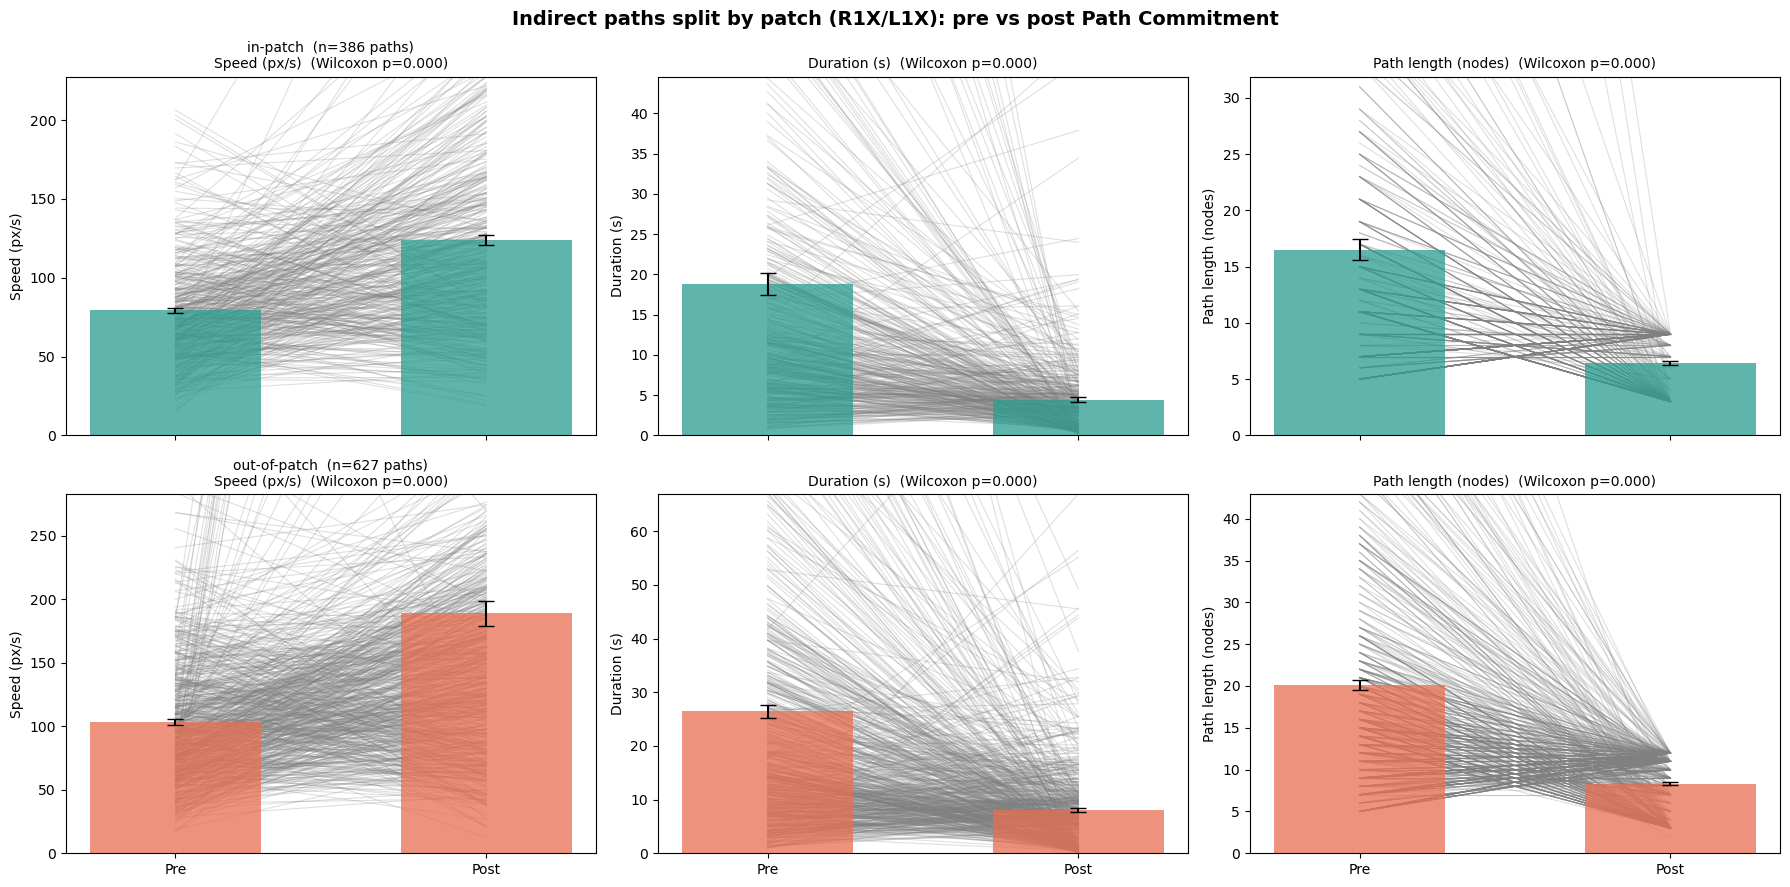


=== in-patch vs out-of-patch (Mann-Whitney, pooled paths) ===
  Speed (px/s)         pre : in=   79.3  out=  103.2  p=0.000
  Speed (px/s)         post: in=  124.0  out=  189.0  p=0.000
  Duration (s)         pre : in=   18.8  out=   26.5  p=0.000
  Duration (s)         post: in=    4.5  out=    8.0  p=0.000
  Path length (nodes)  pre : in=   16.5  out=   20.1  p=0.000
  Path length (nodes)  post: in=    6.4  out=    8.3  p=0.000


In [46]:
# ---------------------------------------------------------------------------
# 1 & 2. In-patch vs out-of-patch indirect paths:
#        speed, duration AND node count, pre vs post Path Commitment.
#
# Splits the long indirect paths by whether the whole trajectory stayed inside
# one patch sub-tree (in-patch) or crossed the corridor / another patch
# (out-of-patch), then compares pre vs post for each metric within each class.
# ---------------------------------------------------------------------------
from scipy.stats import wilcoxon as _wilcoxon, mannwhitneyu as _mwu

_metrics = [
    ('mean_speed', 'mean_speed_pre', 'mean_speed_post', 'Speed (px/s)'),
    ('dur',        'dur_pre_s',      'dur_post_s',      'Duration (s)'),
    ('n_nodes',    'n_nodes_pre',    'n_nodes_post',    'Path length (nodes)'),
]
_classes = ['in-patch', 'out-of-patch']
_class_colors = {'in-patch': '#2a9d8f', 'out-of-patch': '#e76f51'}

# ── Summary table: mean ± STD per class per metric, pre & post ──────────────
_summary = []
for cls in _classes:
    sub = cs_enriched_df[cs_enriched_df['path_class'] == cls]
    row = {'path_class': cls, 'n_paths': len(sub)}
    for _, pre_c, post_c, lbl in _metrics:
        row[f'{lbl} pre']  = f"{sub[pre_c].mean():.1f} ± {sub[pre_c].std(ddof=1):.1f}"
        row[f'{lbl} post'] = f"{sub[post_c].mean():.1f} ± {sub[post_c].std(ddof=1):.1f}"
    _summary.append(row)
print("=== In-patch vs out-of-patch: mean ± STD ===")
display(pd.DataFrame(_summary))

# ── Per-session in/out counts ──────────────────────────────────────────────
print("\n=== Paths per session by class ===")
display(cs_enriched_df.groupby(['session', 'path_class']).size()
        .unstack(fill_value=0)
        .reindex(columns=_classes, fill_value=0))

# ── Figure: 3 metrics (cols) x pre/post grouped bars, in vs out (rows) ──────
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex='col')
fig.suptitle('Indirect paths split by patch (R1X/L1X): pre vs post Path Commitment',
             fontweight='bold', fontsize=14)

for r, cls in enumerate(_classes):
    sub = cs_enriched_df[cs_enriched_df['path_class'] == cls]
    for c, (_, pre_c, post_c, lbl) in enumerate(_metrics):
        ax = axes[r, c]
        pre  = sub[pre_c].dropna()
        post = sub[post_c].dropna()
        ax.bar([0, 1], [pre.mean(), post.mean()],
               color=_class_colors[cls], alpha=0.75, width=0.55, zorder=2)
        ax.errorbar([0, 1], [pre.mean(), post.mean()],
                    yerr=[pre.sem(), post.sem()],
                    fmt='none', color='black', capsize=6, linewidth=1.5, zorder=3)
        # paired lines
        _paired = sub[[pre_c, post_c]].dropna()
        for _, pr in _paired.iterrows():
            ax.plot([0, 1], [pr[pre_c], pr[post_c]], color='gray', alpha=0.25, linewidth=0.8, zorder=1)
        # Wilcoxon
        ptxt = ''
        if len(_paired) > 1:
            try:
                _w, _p = _wilcoxon(_paired[pre_c], _paired[post_c])
                ptxt = f'  (Wilcoxon p={_p:.3f})'
            except ValueError:
                pass
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Pre', 'Post'])
        ax.set_ylabel(lbl)
        ax.set_ylim(bottom=0, top=np.quantile(np.concatenate([pre, post]), 0.95) * 1.1)
        if c == 0:
            ax.set_title(f'{cls}  (n={len(sub)} paths)\n{lbl}{ptxt}', fontsize=10)
        else:
            ax.set_title(f'{lbl}{ptxt}', fontsize=10)

fig.tight_layout()
out_dir = ADDITIONAL_DIR
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / 'patch_split_pre_post.png', dpi=150)
plt.show()

# ── in-patch vs out-of-patch directly (do the two classes differ?) ─────────
print("\n=== in-patch vs out-of-patch (Mann-Whitney, pooled paths) ===")
for _, pre_c, post_c, lbl in _metrics:
    for epoch, col in [('pre', pre_c), ('post', post_c)]:
        a = cs_enriched_df.loc[cs_enriched_df['path_class'] == 'in-patch', col].dropna()
        b = cs_enriched_df.loc[cs_enriched_df['path_class'] == 'out-of-patch', col].dropna()
        if len(a) > 0 and len(b) > 0:
            _u, _p = _mwu(a, b)
            print(f'  {lbl:20s} {epoch:4s}: in={a.mean():7.1f}  out={b.mean():7.1f}  p={_p:.3f}')


## 3. Speed vs distance from reward + Path Commitment distance from reward

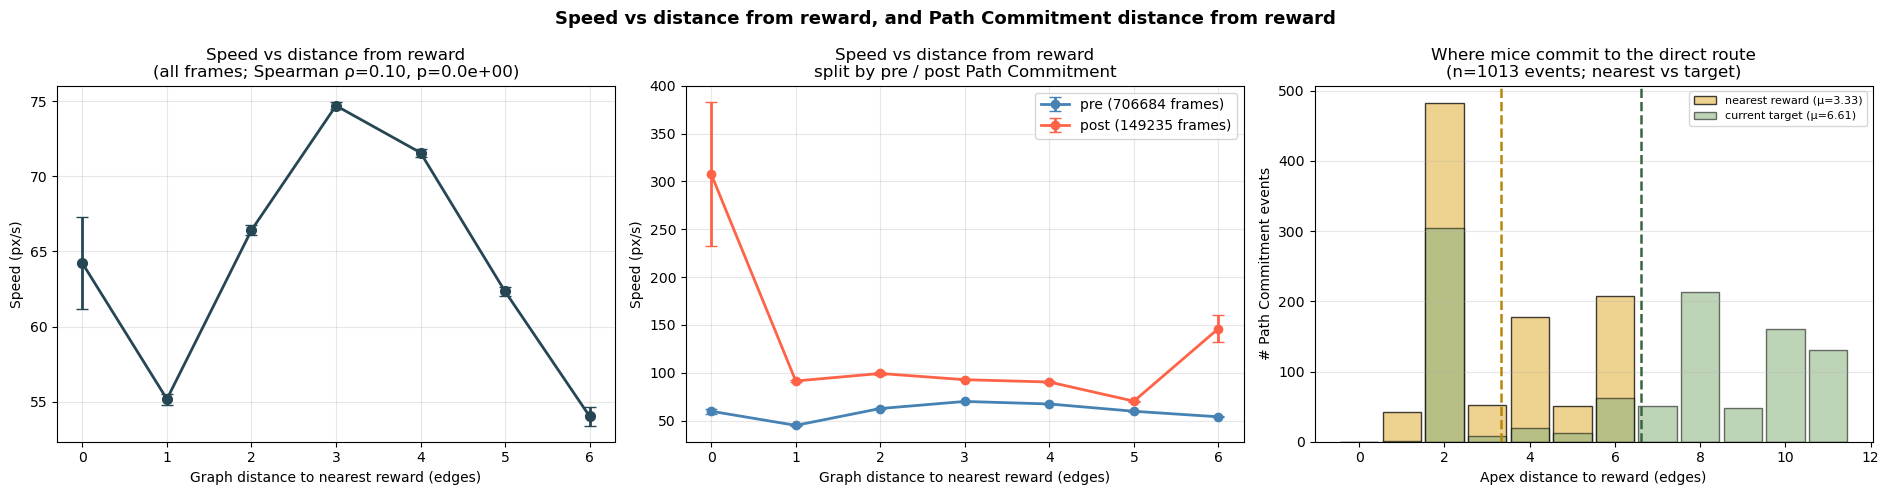

Mean speed by distance-to-reward bin (all frames):


,mean,sem,count
dist_to_reward,,,
0,64.2,3.0,28159
1,55.2,0.4,143524
2,66.4,0.3,144254
3,74.7,0.3,168895
4,71.6,0.3,187879
5,62.3,0.3,126978
6,54.0,0.6,56230



Apex (Path Commitment) distance to NEAREST reward: mean=3.33, median=2, range=[1, 6] edges
Apex distance to CURRENT target port:              mean=6.61, median=8, range=[1, 11] edges


In [47]:
# ---------------------------------------------------------------------------
# 3. Speed vs distance from reward, and where the Path Commitment moments sit
#    relative to reward.
#
# Distance = number of graph edges from the occupied node to the NEAREST reward
# port (0 = at a reward port). Coordinate-free, so it is comparable across
# sessions regardless of camera calibration.
# ---------------------------------------------------------------------------
from scipy.stats import spearmanr as _spearmanr

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle('Speed vs distance from reward, and Path Commitment distance from reward',
             fontweight='bold', fontsize=13)

# ── Panel A: mean speed (±SEM) per distance-to-reward bin, all frames ───────
ax = axes[0]
_g = dist_speed_df.groupby('dist_to_reward')['speed']
_x = _g.mean().index.values
_mean = _g.mean().values
_sem = _g.sem().values
ax.errorbar(_x, _mean, yerr=_sem, fmt='o-', color='#264653',
            capsize=4, linewidth=2, markersize=7)
ax.set_xlabel('Graph distance to nearest reward (edges)')
ax.set_ylabel('Speed (px/s)')
_rho, _p = _spearmanr(dist_speed_df['dist_to_reward'], dist_speed_df['speed'])
ax.set_title(f'Speed vs distance from reward\n(all frames; Spearman ρ={_rho:.2f}, p={_p:.1e})')
ax.grid(alpha=0.3)

# ── Panel B: same, split pre vs post Path Commitment ───────────────────────
ax = axes[1]
for epoch, color in [('pre', 'steelblue'), ('post', 'tomato')]:
    sub = dist_speed_df[dist_speed_df['epoch'] == epoch]
    if sub.empty:
        continue
    g = sub.groupby('dist_to_reward')['speed']
    ax.errorbar(g.mean().index.values, g.mean().values, yerr=g.sem().values,
                fmt='o-', color=color, capsize=4, linewidth=2, markersize=6,
                label=f'{epoch} ({len(sub)} frames)')
ax.set_xlabel('Graph distance to nearest reward (edges)')
ax.set_ylabel('Speed (px/s)')
ax.set_title('Speed vs distance from reward\nsplit by pre / post Path Commitment')
ax.legend()
ax.grid(alpha=0.3)

# ── Panel C: distance of the Path Commitment (apex) node from reward, both
#            metrics — nearest reward vs the current destination target ──────
ax = axes[2]
_apex_near = cs_enriched_df['apex_dist_reward'].dropna().astype(int)
_apex_tgt  = cs_enriched_df['apex_dist_target'].dropna().astype(int)
_bmax = max(_apex_near.max(), _apex_tgt.max())
_bins = np.arange(-0.5, _bmax + 1.5, 1)
ax.hist(_apex_near, bins=_bins, color='#e9c46a', edgecolor='black', rwidth=0.9,
        alpha=0.75, label=f'nearest reward (μ={_apex_near.mean():.2f})')
ax.hist(_apex_tgt,  bins=_bins, color='#8ab17d', edgecolor='black', rwidth=0.9,
        alpha=0.55, label=f'current target (μ={_apex_tgt.mean():.2f})')
ax.axvline(_apex_near.mean(), color='#b8860b', linestyle='--', linewidth=1.8)
ax.axvline(_apex_tgt.mean(),  color='#386641', linestyle='--', linewidth=1.8)
ax.set_xlabel('Apex distance to reward (edges)')
ax.set_ylabel('# Path Commitment events')
ax.set_title(f'Where mice commit to the direct route\n(n={len(_apex_near)} events; nearest vs target)')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
out_dir = ADDITIONAL_DIR
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / 'speed_vs_distance_reward.png', dpi=150)
plt.show()

# ── Numeric summary ────────────────────────────────────────────────────────
print("Mean speed by distance-to-reward bin (all frames):")
display(dist_speed_df.groupby('dist_to_reward')['speed']
        .agg(['mean', 'sem', 'count']).round(1))
print(f"\nApex (Path Commitment) distance to NEAREST reward: "
      f"mean={_apex_near.mean():.2f}, median={_apex_near.median():.0f}, "
      f"range=[{_apex_near.min()}, {_apex_near.max()}] edges")
print(f"Apex distance to CURRENT target port:              "
      f"mean={_apex_tgt.mean():.2f}, median={_apex_tgt.median():.0f}, "
      f"range=[{_apex_tgt.min()}, {_apex_tgt.max()}] edges")


## 4. Speed by tree level (reward-agnostic), pre/post commitment

Groups nodes purely by tree depth (level 0 = the two roots `L0`/`R0` ... level 5 =
the leaf ports), independent of reward location. Since the maze is a balanced tree,
all leaves are level 5, their parents level 4, and so on up to the roots.

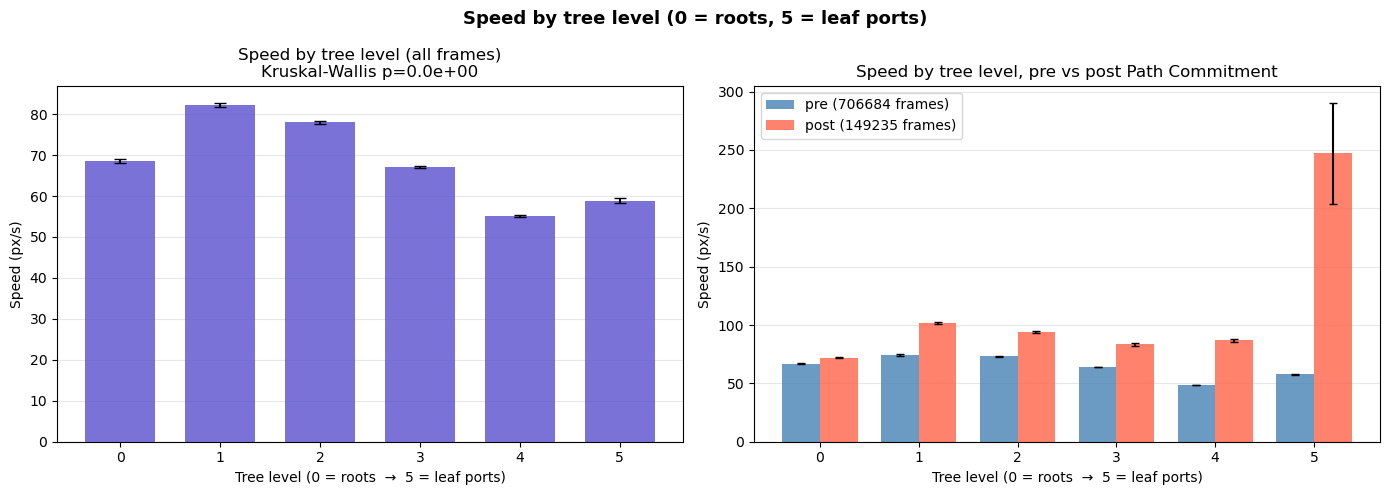

Mean speed by tree level (all frames):


,mean,sem,count
level,,,
0,68.6,0.4,77838
1,82.3,0.5,84625
2,78.0,0.3,140504
3,67.0,0.3,168805
4,55.0,0.2,221055
5,58.8,0.6,163092



Mean speed by tree level x epoch:


epoch,post,pre
level,,
0,71.8,66.8
1,101.8,74.2
2,93.9,73.1
3,83.4,64.2
4,86.8,48.3
5,247.0,57.8


In [44]:
# ---------------------------------------------------------------------------
# 4. Speed by tree level (reward-agnostic), with pre/post commitment split.
#
# Tree level = depth in the maze tree, independent of reward location:
#   level 0 = the two roots (L0/R0), ... level 5 = the leaf ports.
# The maze is a balanced tree, so all leaves share level 5, all their parents
# level 4, and so on. Groups every node purely by its position in the hierarchy
# and asks whether the mouse moves at different speeds at different depths, and
# whether that changes before vs after committing to the direct route.
# ---------------------------------------------------------------------------
from scipy.stats import kruskal as _kruskal

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Speed by tree level (0 = roots, 5 = leaf ports)', fontweight='bold', fontsize=13)

_level_order = sorted(dist_speed_df['level'].unique())

# ── Panel A: mean speed (±SEM) per tree level, all frames pooled ────────────
ax = axes[0]
g = dist_speed_df.groupby('level')['speed']
ax.bar(g.mean().index.values, g.mean().values, yerr=g.sem().values,
       color='#5a4fcf', alpha=0.8, capsize=4, width=0.7, zorder=2)
ax.set_xlabel('Tree level (0 = roots  →  5 = leaf ports)')
ax.set_ylabel('Speed (px/s)')
ax.set_xticks(_level_order)
try:
    _h, _p = _kruskal(*[dist_speed_df.loc[dist_speed_df['level'] == l, 'speed'].values
                        for l in _level_order])
    ax.set_title(f'Speed by tree level (all frames)\nKruskal-Wallis p={_p:.1e}')
except ValueError:
    ax.set_title('Speed by tree level (all frames)')
ax.grid(axis='y', alpha=0.3)

# ── Panel B: same, split pre vs post Path Commitment ───────────────────────
ax = axes[1]
_w = 0.38
for i, (epoch, color) in enumerate([('pre', 'steelblue'), ('post', 'tomato')]):
    sub = dist_speed_df[dist_speed_df['epoch'] == epoch]
    if sub.empty:
        continue
    gg = sub.groupby('level')['speed']
    xs = np.array(_level_order, dtype=float)
    means = [gg.mean().get(l, np.nan) for l in _level_order]
    sems  = [gg.sem().get(l, np.nan)  for l in _level_order]
    ax.bar(xs + (i - 0.5) * _w, means, yerr=sems, width=_w, color=color,
           alpha=0.8, capsize=3, label=f'{epoch} ({len(sub)} frames)', zorder=2)
ax.set_xlabel('Tree level (0 = roots  →  5 = leaf ports)')
ax.set_ylabel('Speed (px/s)')
ax.set_xticks(_level_order)
ax.set_title('Speed by tree level, pre vs post Path Commitment')
ax.legend()
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
out_dir = ADDITIONAL_DIR
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / 'speed_by_tree_level.png', dpi=150)
plt.show()

# ── Numeric summary ────────────────────────────────────────────────────────
print("Mean speed by tree level (all frames):")
display(dist_speed_df.groupby('level')['speed'].agg(['mean', 'sem', 'count']).round(1))
print("\nMean speed by tree level x epoch:")
display(dist_speed_df.groupby(['level', 'epoch'])['speed'].mean().unstack().round(1))
